# **CÁTEDRA FINAL**

## Clasificación de enfermedades foliares del tomate mediante Deep Learning: comparación entre MLP y CNN sobre PlantVillage

| **Ítem** | **Detalle** |
|---|---|
| **Asignatura** | Deep Learning |
| **Ponderación** | 60 % de la nota final |
| **Modalidad** | Grupos del proyecto |
| **Fecha de entrega** | Sábado, 29 de agosto de 2026 |

> **Alumnos** : Guido Ríos Ciaffaroni
>> **Correo** : *guidoriosciaffaroni@gmail.com*


> **Alumnos** : Eduardo Opazo  
>> **Correo** : *edo.opazo.d@gmail.com*

# Fase 0 - Preparación y organización del proyecto

##**Contexto del problema y variable objetivo**

### **1. Contexto del problema**

La identificación oportuna de enfermedades en cultivos agrícolas constituye una tarea relevante para la sanidad vegetal, debido a que distintas patologías pueden afectar el desarrollo de las plantas, reducir el rendimiento de los cultivos y generar pérdidas productivas. En este contexto, el análisis automatizado de imágenes mediante técnicas de **Visión por Computador y Deep Learning** representa una alternativa para apoyar la clasificación de enfermedades a partir de características visuales presentes en las hojas.

Las enfermedades foliares pueden manifestarse mediante diferentes patrones visuales, entre ellos:

* Cambios de coloración.
* Aparición de manchas o lesiones.
* Alteraciones en la textura de la superficie foliar.
* Variaciones en la forma y distribución de las zonas afectadas.
* Presencia de patrones característicos asociados a determinadas enfermedades.

A diferencia de un conjunto de datos tabular, donde las características suelen encontrarse representadas explícitamente mediante variables numéricas o categóricas, una imagen contiene información distribuida espacialmente entre sus píxeles. Por esta razón, características como bordes, texturas, manchas, formas y patrones de lesión deben ser **aprendidas automáticamente por el modelo** a partir de los datos visuales.

En este proyecto se utiliza el conjunto de datos **PlantVillage**, restringiendo el análisis exclusivamente a imágenes correspondientes a hojas de **tomate (*Tomato*)**. Después del proceso de selección, verificación de integridad y eliminación de archivos duplicados exactos, el conjunto de datos utilizado contiene **18.146 imágenes únicas**, distribuidas en **10 clases** que representan diferentes enfermedades foliares y una categoría correspondiente a hojas saludables.

Las imágenes presentan características homogéneas de almacenamiento: se encuentran en formato **JPEG**, utilizan representación de color **RGB** y poseen una resolución original de **256 × 256 píxeles**. Estas características permiten establecer un pipeline uniforme de preprocesamiento antes del entrenamiento de los modelos.

La **variable objetivo** corresponde a la categoría sanitaria asignada a cada imagen, es decir, la enfermedad foliar o el estado saludable de la hoja de tomate. Matemáticamente, para cada imagen (X_i), se desea predecir una etiqueta:

$[
y_i \in {c_1,c_2,\ldots,c_{10}}
]$

donde cada (c_k) representa una de las diez clases presentes en el conjunto de datos.

Por lo tanto, el problema corresponde a una tarea de **clasificación supervisada multiclase**, ya que cada imagen debe ser asignada a una única categoría entre varias clases posibles.

El propósito general del proyecto es desarrollar y comparar dos arquitecturas de Deep Learning estudiadas en la asignatura: una **Red Neuronal Multicapa (MLP)** y una **Red Neuronal Convolucional (CNN)**. Ambas utilizarán las mismas imágenes como fuente de información, pero representarán hipótesis diferentes respecto de cómo aprovechar su estructura.

La MLP utilizará una representación vectorizada de la imagen, mientras que la CNN conservará y explotará explícitamente las relaciones espaciales entre los píxeles mediante operaciones convolucionales. De esta manera, el proyecto buscará determinar si la capacidad de una CNN para aprender patrones locales y jerarquías espaciales permite obtener una mejor capacidad de clasificación y generalización que una MLP aplicada sobre las mismas imágenes.

En consecuencia, la pregunta experimental central puede formularse como:

> **¿En qué medida una red neuronal convolucional (CNN), al conservar y explotar la estructura espacial de las imágenes, mejora la clasificación y la capacidad de generalización de enfermedades foliares del tomate respecto de una red neuronal multicapa (MLP) que utiliza una representación vectorizada de las mismas imágenes?**

---


## Librerias

In [60]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Reproducibilidad

In [61]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

##**Descargar o cargar el conjunto de datos mediante código reproducible.**

## Descarga del dataset PlantVillage desde Kaggle mediante `curl`

En esta etapa se descargará directamente el archivo comprimido del dataset
**PlantVillage** utilizando `curl` y el endpoint de descarga proporcionado
por Kaggle.

El dataset será almacenado en:

`/content/plantvillage.zip`

Esta estrategia permite mantener inicialmente el conjunto de datos comprimido,
verificar su descarga e integridad y posteriormente descomprimirlo solamente
cuando sea necesario para el análisis de imágenes.

In [62]:
%%bash

# ============================================================
# DESCARGA DEL DATASET PLANTVILLAGE DESDE KAGGLE
# ============================================================

curl -L \
  -o /content/plantvillage.zip \
  "https://www.kaggle.com/api/v1/datasets/download/mohitsingh1804/plantvillage"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  817M  100  817M    0     0   205M      0  0:00:03  0:00:03 --:--:--  219M


In [63]:
# ============================================================
# VERIFICACIÓN DE LA DESCARGA
# ============================================================

import os

ruta_zip = "/content/plantvillage.zip"

if os.path.exists(ruta_zip):

    print("✅ Dataset descargado correctamente.")
    print(f"Ruta: {ruta_zip}")

else:

    print("❌ No se encontró el archivo descargado.")

✅ Dataset descargado correctamente.
Ruta: /content/plantvillage.zip


In [64]:
# ============================================================
# TAMAÑO DEL ARCHIVO DESCARGADO
# ============================================================

import os

ruta_zip = "/content/plantvillage.zip"

if os.path.exists(ruta_zip):

    tamaño_bytes = os.path.getsize(ruta_zip)

    tamaño_mb = tamaño_bytes / (1024 ** 2)

    tamaño_gb = tamaño_bytes / (1024 ** 3)

    print("=" * 60)
    print("INFORMACIÓN DEL ARCHIVO")
    print("=" * 60)

    print(f"Archivo : {ruta_zip}")
    print(f"Tamaño  : {tamaño_mb:.2f} MB")
    print(f"Tamaño  : {tamaño_gb:.3f} GB")

else:

    print("❌ El archivo no existe.")

INFORMACIÓN DEL ARCHIVO
Archivo : /content/plantvillage.zip
Tamaño  : 817.63 MB
Tamaño  : 0.798 GB


In [65]:
# ============================================================
# VERIFICACIÓN DE INTEGRIDAD DEL ARCHIVO ZIP
# ============================================================

import zipfile

ruta_zip = "/content/plantvillage.zip"

try:

    with zipfile.ZipFile(ruta_zip, "r") as archivo_zip:

        archivo_problematico = archivo_zip.testzip()

    if archivo_problematico is None:

        print("✅ El archivo ZIP es válido y no presenta errores detectables.")

    else:

        print("⚠️ Se detectó un archivo problemático dentro del ZIP:")
        print(archivo_problematico)

except zipfile.BadZipFile:

    print("❌ El archivo descargado no corresponde a un ZIP válido.")

✅ El archivo ZIP es válido y no presenta errores detectables.


In [66]:
# ============================================================
# INSPECCIÓN DEL CONTENIDO DEL ZIP
# SIN DESCOMPRIMIR
# ============================================================

import zipfile

ruta_zip = "/content/plantvillage.zip"

with zipfile.ZipFile(ruta_zip, "r") as archivo_zip:

    archivos = archivo_zip.namelist()


print("=" * 70)
print("CONTENIDO DEL DATASET")
print("=" * 70)

print(f"Número total de elementos: {len(archivos):,}")

print("\nPrimeros 30 elementos:\n")

for archivo in archivos[:30]:

    print(archivo)

CONTENIDO DEL DATASET
Número total de elementos: 54,305

Primeros 30 elementos:

PlantVillage/train/Apple___Apple_scab/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG
PlantVillage/train/Apple___Apple_scab/01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Scab 3112.JPG
PlantVillage/train/Apple___Apple_scab/0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Scab 3037.JPG
PlantVillage/train/Apple___Apple_scab/023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Scab 3487.JPG
PlantVillage/train/Apple___Apple_scab/0261a6e4-21f8-481a-8827-b674e6955644___FREC_Scab 3055.JPG
PlantVillage/train/Apple___Apple_scab/029424b0-0ef5-491b-9ef5-069190d24d8f___FREC_Scab 3504.JPG
PlantVillage/train/Apple___Apple_scab/0340dc35-5215-48ab-8db7-06af99fcb358___FREC_Scab 2966.JPG
PlantVillage/train/Apple___Apple_scab/03eccb1a-0368-4ac7-9f48-7546037b775a___FREC_Scab 3334.JPG
PlantVillage/train/Apple___Apple_scab/0537ad56-3d24-4e97-a947-65b9b37f8988___FREC_Scab 3079.JPG
PlantVillage/train/Apple___Apple_scab/058d5e64-2c57-45b

In [67]:
# ============================================================
# CREACIÓN DEL DIRECTORIO DE EXTRACCIÓN
# ============================================================

import os

DIRECTORIO_DATOS = "/content/plantvillage"

os.makedirs(
    DIRECTORIO_DATOS,
    exist_ok=True
)

print("✅ Directorio creado:")
print(DIRECTORIO_DATOS)

✅ Directorio creado:
/content/plantvillage


In [68]:
# ============================================================
# REINICIO CONTROLADO DEL DIRECTORIO DE TRABAJO
# ============================================================

from pathlib import Path
import shutil

WORK_DIR = Path("/content/plantvillage")

# Eliminar resultados de ejecuciones anteriores
if WORK_DIR.exists():

    shutil.rmtree(WORK_DIR)

    print(
        "🧹 Directorio anterior eliminado:"
    )
    print(WORK_DIR)

# Crear nuevamente un directorio limpio
WORK_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "\n✅ Entorno limpio preparado."
)

🧹 Directorio anterior eliminado:
/content/plantvillage

✅ Entorno limpio preparado.


In [69]:
%%bash

unzip -q /content/plantvillage.zip \
       -d /content/plantvillage

## Filtrado de clases del dataset PlantVillage

En esta etapa se realizará un **filtrado de las clases originales del dataset PlantVillage** con el objetivo de conservar únicamente las categorías correspondientes a hojas de **tomate (`Tomato`)**, que constituyen el objeto de estudio del proyecto.

La eliminación se aplicará tanto sobre el conjunto original `train` como sobre el conjunto `val`, de manera que ambos subconjuntos mantengan el mismo criterio de selección.

Se eliminarán todas las carpetas cuyo nombre comience con alguno de los siguientes prefijos:

- Apple
- Blueberry
- Cherry
- Corn
- Grape
- Orange
- Peach
- Pepper
- Potato
- Raspberry
- Soybean
- Squash
- Strawberry

De esta forma, después del filtrado se conservarán exclusivamente las clases asociadas a **tomate**, incluyendo distintas enfermedades foliares y la categoría correspondiente a hojas saludables.

Antes de realizar la eliminación definitiva, el código verificará y mostrará qué directorios cumplen los criterios establecidos. Esta comprobación previa permite validar la selección y reducir el riesgo de eliminar accidentalmente alguna clase que deba formar parte del experimento.

El resultado esperado de esta etapa es obtener un conjunto de datos compuesto únicamente por las **10 clases de tomate** que serán utilizadas posteriormente en las etapas de auditoría, preprocesamiento, entrenamiento y comparación de los modelos **MLP y CNN**.







In [70]:
# ============================================================
# BLOQUE 2
# CONFIGURACIÓN DE RUTAS Y CLASES A ELIMINAR
# ============================================================

import os
import shutil


# ------------------------------------------------------------
# Directorio principal del dataset
# ------------------------------------------------------------

BASE_DIR = "/content/plantvillage/PlantVillage"


# Directorios de entrenamiento y validación
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")


# ------------------------------------------------------------
# Prefijos de las clases que se desean eliminar
# ------------------------------------------------------------

PREFIJOS_ELIMINAR = (
    "Apple",
    "Blueberry",
    "Cherry",
    "Corn",
    "Grape",
    "Orange",
    "Peach",
    "Potato",
    "Pepper",
    "Raspberry",
    "Soybean",
    "Squash",
    "Strawberry"
)


print("=" * 70)
print("CONFIGURACIÓN")
print("=" * 70)

print(f"Train : {TRAIN_DIR}")
print(f"Val   : {VAL_DIR}")

print("\nPrefijos que serán eliminados:")

for prefijo in PREFIJOS_ELIMINAR:
    print(f" - {prefijo}")

CONFIGURACIÓN
Train : /content/plantvillage/PlantVillage/train
Val   : /content/plantvillage/PlantVillage/val

Prefijos que serán eliminados:
 - Apple
 - Blueberry
 - Cherry
 - Corn
 - Grape
 - Orange
 - Peach
 - Potato
 - Pepper
 - Raspberry
 - Soybean
 - Squash
 - Strawberry


In [71]:
# ============================================================
# BLOQUE 3
# MOSTRAR TODAS LAS CLASES DISPONIBLES
# ============================================================

def mostrar_clases(directorio, nombre_conjunto):
    """
    Muestra las carpetas correspondientes a las clases de un conjunto.
    """

    print("\n" + "=" * 70)
    print(f"CLASES DISPONIBLES EN {nombre_conjunto.upper()}")
    print("=" * 70)

    if not os.path.exists(directorio):
        print(f"❌ No existe el directorio: {directorio}")
        return []

    clases = sorted(
        carpeta
        for carpeta in os.listdir(directorio)
        if os.path.isdir(os.path.join(directorio, carpeta))
    )

    for i, clase in enumerate(clases, start=1):
        print(f"{i:02d}. {clase}")

    print(f"\nNúmero total de clases: {len(clases)}")

    return clases


clases_train = mostrar_clases(
    TRAIN_DIR,
    "train"
)

clases_val = mostrar_clases(
    VAL_DIR,
    "val"
)


CLASES DISPONIBLES EN TRAIN
01. Apple___Apple_scab
02. Apple___Black_rot
03. Apple___Cedar_apple_rust
04. Apple___healthy
05. Blueberry___healthy
06. Cherry_(including_sour)___Powdery_mildew
07. Cherry_(including_sour)___healthy
08. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
09. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
11. Corn_(maize)___healthy
12. Grape___Black_rot
13. Grape___Esca_(Black_Measles)
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15. Grape___healthy
16. Orange___Haunglongbing_(Citrus_greening)
17. Peach___Bacterial_spot
18. Peach___healthy
19. Pepper,_bell___Bacterial_spot
20. Pepper,_bell___healthy
21. Potato___Early_blight
22. Potato___Late_blight
23. Potato___healthy
24. Raspberry___healthy
25. Soybean___healthy
26. Squash___Powdery_mildew
27. Strawberry___Leaf_scorch
28. Strawberry___healthy
29. Tomato___Bacterial_spot
30. Tomato___Early_blight
31. Tomato___Late_blight
32. Tomato___Leaf_Mold
33. Tomato___Septoria_leaf_spot
34. Tom

In [72]:
# ============================================================
# BLOQUE 4
# IDENTIFICAR CARPETAS QUE SERÁN ELIMINADAS
# ============================================================

def identificar_carpetas_eliminar(directorio):
    """
    Identifica las carpetas cuyo nombre comienza
    con alguno de los prefijos definidos.
    """

    carpetas_eliminar = []

    if not os.path.exists(directorio):
        return carpetas_eliminar

    for carpeta in os.listdir(directorio):

        ruta_carpeta = os.path.join(
            directorio,
            carpeta
        )

        # Comprobar que sea realmente una carpeta
        if os.path.isdir(ruta_carpeta):

            # Verificar si el nombre comienza con alguno
            # de los prefijos indicados
            if carpeta.startswith(PREFIJOS_ELIMINAR):

                carpetas_eliminar.append(carpeta)

    return sorted(carpetas_eliminar)


eliminar_train = identificar_carpetas_eliminar(
    TRAIN_DIR
)

eliminar_val = identificar_carpetas_eliminar(
    VAL_DIR
)


print("=" * 70)
print("CARPETAS QUE SERÍAN ELIMINADAS DE TRAIN")
print("=" * 70)

for carpeta in eliminar_train:
    print(f"❌ {carpeta}")


print(f"\nTotal: {len(eliminar_train)} carpetas")


print("\n" + "=" * 70)
print("CARPETAS QUE SERÍAN ELIMINADAS DE VAL")
print("=" * 70)

for carpeta in eliminar_val:
    print(f"❌ {carpeta}")


print(f"\nTotal: {len(eliminar_val)} carpetas")

CARPETAS QUE SERÍAN ELIMINADAS DE TRAIN
❌ Apple___Apple_scab
❌ Apple___Black_rot
❌ Apple___Cedar_apple_rust
❌ Apple___healthy
❌ Blueberry___healthy
❌ Cherry_(including_sour)___Powdery_mildew
❌ Cherry_(including_sour)___healthy
❌ Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
❌ Corn_(maize)___Common_rust_
❌ Corn_(maize)___Northern_Leaf_Blight
❌ Corn_(maize)___healthy
❌ Grape___Black_rot
❌ Grape___Esca_(Black_Measles)
❌ Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
❌ Grape___healthy
❌ Orange___Haunglongbing_(Citrus_greening)
❌ Peach___Bacterial_spot
❌ Peach___healthy
❌ Pepper,_bell___Bacterial_spot
❌ Pepper,_bell___healthy
❌ Potato___Early_blight
❌ Potato___Late_blight
❌ Potato___healthy
❌ Raspberry___healthy
❌ Soybean___healthy
❌ Squash___Powdery_mildew
❌ Strawberry___Leaf_scorch
❌ Strawberry___healthy

Total: 28 carpetas

CARPETAS QUE SERÍAN ELIMINADAS DE VAL
❌ Apple___Apple_scab
❌ Apple___Black_rot
❌ Apple___Cedar_apple_rust
❌ Apple___healthy
❌ Blueberry___healthy
❌ Cherry_(including

In [73]:
# ============================================================
# BLOQUE 5
# CONTAR IMÁGENES QUE SERÁN ELIMINADAS
# ============================================================

def contar_archivos_carpeta(ruta):
    """
    Cuenta todos los archivos contenidos en una carpeta
    y sus subdirectorios.
    """

    contador = 0

    for _, _, archivos in os.walk(ruta):
        contador += len(archivos)

    return contador


def resumen_eliminacion(directorio, carpetas):

    total_imagenes = 0

    for carpeta in carpetas:

        ruta = os.path.join(
            directorio,
            carpeta
        )

        cantidad = contar_archivos_carpeta(ruta)

        total_imagenes += cantidad

        print(
            f"{carpeta:<65} "
            f"{cantidad:>6} imágenes"
        )

    return total_imagenes


print("=" * 85)
print("IMÁGENES A ELIMINAR DE TRAIN")
print("=" * 85)

imagenes_train_eliminar = resumen_eliminacion(
    TRAIN_DIR,
    eliminar_train
)

print(
    f"\nTotal imágenes a eliminar de train: "
    f"{imagenes_train_eliminar:,}"
)


print("\n" + "=" * 85)
print("IMÁGENES A ELIMINAR DE VAL")
print("=" * 85)

imagenes_val_eliminar = resumen_eliminacion(
    VAL_DIR,
    eliminar_val
)

print(
    f"\nTotal imágenes a eliminar de val: "
    f"{imagenes_val_eliminar:,}"
)

IMÁGENES A ELIMINAR DE TRAIN
Apple___Apple_scab                                                   504 imágenes
Apple___Black_rot                                                    496 imágenes
Apple___Cedar_apple_rust                                             220 imágenes
Apple___healthy                                                     1316 imágenes
Blueberry___healthy                                                 1202 imágenes
Cherry_(including_sour)___Powdery_mildew                             842 imágenes
Cherry_(including_sour)___healthy                                    684 imágenes
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot                   410 imágenes
Corn_(maize)___Common_rust_                                          953 imágenes
Corn_(maize)___Northern_Leaf_Blight                                  788 imágenes
Corn_(maize)___healthy                                               929 imágenes
Grape___Black_rot                                                    

In [74]:
# ============================================================
# BLOQUE 6
# ELIMINACIÓN DEFINITIVA DE LAS CARPETAS
# ============================================================

def eliminar_carpetas(directorio, prefijos):
    """
    Elimina todas las carpetas cuyo nombre comienza con
    cualquiera de los prefijos especificados.

    Parámetros
    ----------
    directorio : str
        Ruta del directorio que contiene las clases.

    prefijos : tuple
        Prefijos correspondientes a las clases
        que deben eliminarse.
    """

    eliminadas = []

    if not os.path.exists(directorio):

        print(f"❌ No existe el directorio: {directorio}")

        return eliminadas


    for carpeta in os.listdir(directorio):

        ruta_carpeta = os.path.join(
            directorio,
            carpeta
        )


        if (
            os.path.isdir(ruta_carpeta)
            and carpeta.startswith(prefijos)
        ):

            # Eliminar carpeta y todo su contenido
            shutil.rmtree(ruta_carpeta)

            eliminadas.append(carpeta)

            print(f"🗑️ Eliminada: {carpeta}")


    return sorted(eliminadas)

In [75]:
# ============================================================
# EJECUTAR ELIMINACIÓN
# ============================================================

print("=" * 70)
print("ELIMINANDO CLASES DE TRAIN")
print("=" * 70)

eliminadas_train = eliminar_carpetas(
    TRAIN_DIR,
    PREFIJOS_ELIMINAR
)


print("\n" + "=" * 70)
print("ELIMINANDO CLASES DE VAL")
print("=" * 70)

eliminadas_val = eliminar_carpetas(
    VAL_DIR,
    PREFIJOS_ELIMINAR
)


print("\n" + "=" * 70)
print("PROCESO FINALIZADO")
print("=" * 70)

print(
    f"Carpetas eliminadas de train: "
    f"{len(eliminadas_train)}"
)

print(
    f"Carpetas eliminadas de val  : "
    f"{len(eliminadas_val)}"
)

ELIMINANDO CLASES DE TRAIN
🗑️ Eliminada: Peach___healthy
🗑️ Eliminada: Pepper,_bell___healthy
🗑️ Eliminada: Potato___Early_blight
🗑️ Eliminada: Apple___Cedar_apple_rust
🗑️ Eliminada: Apple___Black_rot
🗑️ Eliminada: Apple___healthy
🗑️ Eliminada: Raspberry___healthy
🗑️ Eliminada: Cherry_(including_sour)___Powdery_mildew
🗑️ Eliminada: Soybean___healthy
🗑️ Eliminada: Potato___Late_blight
🗑️ Eliminada: Corn_(maize)___healthy
🗑️ Eliminada: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
🗑️ Eliminada: Corn_(maize)___Common_rust_
🗑️ Eliminada: Grape___healthy
🗑️ Eliminada: Squash___Powdery_mildew
🗑️ Eliminada: Corn_(maize)___Northern_Leaf_Blight
🗑️ Eliminada: Peach___Bacterial_spot
🗑️ Eliminada: Pepper,_bell___Bacterial_spot
🗑️ Eliminada: Cherry_(including_sour)___healthy
🗑️ Eliminada: Orange___Haunglongbing_(Citrus_greening)
🗑️ Eliminada: Strawberry___healthy
🗑️ Eliminada: Apple___Apple_scab
🗑️ Eliminada: Strawberry___Leaf_scorch
🗑️ Eliminada: Grape___Esca_(Black_Measles)
🗑️ Eliminada: Blueberry__

In [76]:
# ============================================================
# BLOQUE 7
# VERIFICACIÓN POSTERIOR A LA ELIMINACIÓN
# ============================================================

def obtener_clases(directorio):

    return sorted(
        carpeta
        for carpeta in os.listdir(directorio)
        if os.path.isdir(
            os.path.join(
                directorio,
                carpeta
            )
        )
    )


clases_train_final = obtener_clases(
    TRAIN_DIR
)

clases_val_final = obtener_clases(
    VAL_DIR
)


print("=" * 70)
print("CLASES RESTANTES EN TRAIN")
print("=" * 70)

for i, clase in enumerate(
    clases_train_final,
    start=1
):

    print(f"{i:02d}. {clase}")


print(
    f"\nNúmero final de clases: "
    f"{len(clases_train_final)}"
)


print("\n" + "=" * 70)
print("CLASES RESTANTES EN VAL")
print("=" * 70)

for i, clase in enumerate(
    clases_val_final,
    start=1
):

    print(f"{i:02d}. {clase}")


print(
    f"\nNúmero final de clases: "
    f"{len(clases_val_final)}"
)

CLASES RESTANTES EN TRAIN
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy

Número final de clases: 10

CLASES RESTANTES EN VAL
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy

Número final de clases: 10


In [77]:
# ============================================================
# BLOQUE 8
# CONSISTENCIA ENTRE TRAIN Y VAL
# ============================================================

set_train = set(clases_train_final)
set_val = set(clases_val_final)


if set_train == set_val:

    print("✅ TRAIN y VAL contienen exactamente las mismas clases.")

else:

    print("⚠️ TRAIN y VAL no contienen las mismas clases.")


    solo_train = set_train - set_val

    solo_val = set_val - set_train


    if solo_train:

        print("\nClases presentes solamente en TRAIN:")

        for clase in sorted(solo_train):
            print(f" - {clase}")


    if solo_val:

        print("\nClases presentes solamente en VAL:")

        for clase in sorted(solo_val):
            print(f" - {clase}")

✅ TRAIN y VAL contienen exactamente las mismas clases.


## Conteo de imágenes por clase

En esta etapa se contabilizará la cantidad de imágenes disponibles en cada
directorio de clase para los conjuntos `train` y `val`.

El objetivo es verificar:

- cuántas clases permanecen en el dataset;
- cuántas imágenes contiene cada clase;
- si existe desbalance entre las categorías;
- el número total de imágenes por conjunto;
- la consistencia entre entrenamiento y validación.

Se considerarán como imágenes los archivos con extensiones:

`.jpg`, `.jpeg`, `.png`, `.bmp`, `.tif`, `.tiff` y `.webp`.

In [78]:
# ============================================================
# CONTEO DE IMÁGENES POR DIRECTORIO / CLASE
# ============================================================

import os
import pandas as pd


# ------------------------------------------------------------
# 1. Definir rutas del dataset
# ------------------------------------------------------------

BASE_DIR = "/content/plantvillage/PlantVillage"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")


# ------------------------------------------------------------
# 2. Extensiones consideradas como imágenes
# ------------------------------------------------------------

EXTENSIONES_IMAGEN = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
)


# ------------------------------------------------------------
# 3. Función para contar imágenes por clase
# ------------------------------------------------------------

def contar_imagenes_por_clase(directorio, conjunto):
    """
    Cuenta la cantidad de imágenes contenidas en cada
    subdirectorio de un conjunto de datos.

    Parámetros
    ----------
    directorio : str
        Ruta del directorio principal, por ejemplo train o val.

    conjunto : str
        Nombre del conjunto: 'train' o 'val'.

    Retorna
    -------
    pandas.DataFrame
        Tabla con:
        - conjunto
        - clase
        - cantidad_imagenes
    """

    resultados = []

    # Verificar que el directorio exista
    if not os.path.exists(directorio):

        print(f"❌ No existe el directorio: {directorio}")
        return pd.DataFrame()


    # Recorrer las carpetas ordenadamente
    for clase in sorted(os.listdir(directorio)):

        ruta_clase = os.path.join(
            directorio,
            clase
        )

        # Procesar únicamente carpetas
        if os.path.isdir(ruta_clase):

            cantidad = 0

            # Recorrer los archivos de la carpeta
            for archivo in os.listdir(ruta_clase):

                if archivo.lower().endswith(
                    EXTENSIONES_IMAGEN
                ):

                    cantidad += 1


            resultados.append({
                "Conjunto": conjunto,
                "Clase": clase,
                "Cantidad_imagenes": cantidad
            })


    return pd.DataFrame(resultados)

In [79]:
# ============================================================
# CONTEO DE IMÁGENES EN TRAIN
# ============================================================

df_train = contar_imagenes_por_clase(
    TRAIN_DIR,
    "train"
)


print("=" * 90)
print("IMÁGENES POR CLASE - TRAIN")
print("=" * 90)


for i, fila in df_train.iterrows():

    print(
        f"{i + 1:02d}. "
        f"{fila['Clase']:<65} "
        f"{fila['Cantidad_imagenes']:>6} imágenes"
    )


print("=" * 90)

print(
    f"Número de clases : "
    f"{len(df_train)}"
)

print(
    f"Total imágenes   : "
    f"{df_train['Cantidad_imagenes'].sum():,}"
)

IMÁGENES POR CLASE - TRAIN
01. Tomato___Bacterial_spot                                             1702 imágenes
02. Tomato___Early_blight                                                800 imágenes
03. Tomato___Late_blight                                                1527 imágenes
04. Tomato___Leaf_Mold                                                   761 imágenes
05. Tomato___Septoria_leaf_spot                                         1417 imágenes
06. Tomato___Spider_mites Two-spotted_spider_mite                       1341 imágenes
07. Tomato___Target_Spot                                                1123 imágenes
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus                              4286 imágenes
09. Tomato___Tomato_mosaic_virus                                         299 imágenes
10. Tomato___healthy                                                    1273 imágenes
Número de clases : 10
Total imágenes   : 14,529


In [80]:
# ============================================================
# CONTEO DE IMÁGENES EN VALIDACIÓN
# ============================================================

df_val = contar_imagenes_por_clase(
    VAL_DIR,
    "val"
)


print("=" * 90)
print("IMÁGENES POR CLASE - VAL")
print("=" * 90)


for i, fila in df_val.iterrows():

    print(
        f"{i + 1:02d}. "
        f"{fila['Clase']:<65} "
        f"{fila['Cantidad_imagenes']:>6} imágenes"
    )


print("=" * 90)

print(
    f"Número de clases : "
    f"{len(df_val)}"
)

print(
    f"Total imágenes   : "
    f"{df_val['Cantidad_imagenes'].sum():,}"
)

IMÁGENES POR CLASE - VAL
01. Tomato___Bacterial_spot                                              425 imágenes
02. Tomato___Early_blight                                                200 imágenes
03. Tomato___Late_blight                                                 382 imágenes
04. Tomato___Leaf_Mold                                                   191 imágenes
05. Tomato___Septoria_leaf_spot                                          354 imágenes
06. Tomato___Spider_mites Two-spotted_spider_mite                        335 imágenes
07. Tomato___Target_Spot                                                 281 imágenes
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus                              1071 imágenes
09. Tomato___Tomato_mosaic_virus                                          74 imágenes
10. Tomato___healthy                                                     318 imágenes
Número de clases : 10
Total imágenes   : 3,631


## Consolidación de imágenes por clase

El dataset PlantVillage se encuentra actualmente dividido en dos conjuntos:

- `train`
- `val`

En esta etapa se eliminará dicha separación y se consolidarán todas las imágenes
pertenecientes a una misma clase en un único directorio.

Por ejemplo:

`train/Potato___Early_blight`

y

`val/Potato___Early_blight`

serán fusionados en:

`PlantVillage/Potato___Early_blight`

El procedimiento contempla:

1. Identificar automáticamente todas las clases.
2. Contar las imágenes antes de la consolidación.
3. Crear un directorio único para cada clase.
4. Mover las imágenes de `train` y `val`.
5. Evitar sobrescrituras en caso de nombres de archivos duplicados.
6. Verificar que el número total de imágenes se conserve.
7. Eliminar las antiguas carpetas `train` y `val`.

In [81]:
# ============================================================
# CONTROL PREVIO A LA CONSOLIDACIÓN
# Detectar directorios consolidados de ejecuciones anteriores
# ============================================================

from pathlib import Path

# Directorio raíz del dataset PlantVillage
BASE_DIR = Path("/content/plantvillage/PlantVillage")

# ------------------------------------------------------------
# Verificar que el directorio exista
# ------------------------------------------------------------

if not BASE_DIR.exists():
    raise FileNotFoundError(
        f"No existe el directorio esperado:\n{BASE_DIR}"
    )

# ------------------------------------------------------------
# Buscar directorios de clases de tomate que estén directamente
# dentro de PlantVillage.
#
# Ejemplo:
# PlantVillage/Tomato___Bacterial_spot
# PlantVillage/Tomato___Early_blight
# etc.
# ------------------------------------------------------------

directorios_preexistentes = sorted([
    ruta
    for ruta in BASE_DIR.iterdir()
    if ruta.is_dir()
    and ruta.name.startswith("Tomato___")
])

# ------------------------------------------------------------
# Mostrar diagnóstico
# ------------------------------------------------------------

print("=" * 70)
print("CONTROL PREVIO A LA CONSOLIDACIÓN")
print("=" * 70)

print(f"\nDirectorio base:")
print(BASE_DIR)

print(
    f"\nDirectorios consolidados encontrados: "
    f"{len(directorios_preexistentes)}"
)

if directorios_preexistentes:

    print(
        "\n⚠️ Se detectaron directorios de tomate "
        "consolidados previamente:\n"
    )

    for ruta in directorios_preexistentes:
        print(f" - {ruta.name}")

    print(
        "\n❌ NO se recomienda continuar con la "
        "consolidación."
    )

    print(
        "\nEstos directorios probablemente pertenecen "
        "a una ejecución anterior del notebook."
    )

else:

    print(
        "\n✅ No existen directorios consolidados previos."
    )

    print(
        "✅ Es seguro continuar con la consolidación."
    )

CONTROL PREVIO A LA CONSOLIDACIÓN

Directorio base:
/content/plantvillage/PlantVillage

Directorios consolidados encontrados: 0

✅ No existen directorios consolidados previos.
✅ Es seguro continuar con la consolidación.


In [82]:
# ============================================================
# CONSOLIDACIÓN DEL DATASET PLANTVILLAGE
# ============================================================

from pathlib import Path
import shutil
from collections import defaultdict


# ------------------------------------------------------------
# Directorio principal
# ------------------------------------------------------------

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# Directorios actualmente existentes
TRAIN_DIR = BASE_DIR / "train"
VAL_DIR   = BASE_DIR / "val"


# Directorios que se van a fusionar
DIRECTORIOS_ORIGEN = {
    "train": TRAIN_DIR,
    "val": VAL_DIR
}


# Extensiones reconocidas como imágenes
EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 70)
print("CONFIGURACIÓN")
print("=" * 70)

print(f"Directorio base : {BASE_DIR}")
print(f"Train           : {TRAIN_DIR}")
print(f"Val             : {VAL_DIR}")

CONFIGURACIÓN
Directorio base : /content/plantvillage/PlantVillage
Train           : /content/plantvillage/PlantVillage/train
Val             : /content/plantvillage/PlantVillage/val


In [83]:
# ============================================================
# IDENTIFICAR LAS CLASES DISPONIBLES
# ============================================================

clases_por_conjunto = {}


for conjunto, directorio in DIRECTORIOS_ORIGEN.items():

    if not directorio.exists():

        print(
            f"⚠️ No existe el directorio: {directorio}"
        )

        clases_por_conjunto[conjunto] = []

        continue


    clases = sorted(
        carpeta.name
        for carpeta in directorio.iterdir()
        if carpeta.is_dir()
    )


    clases_por_conjunto[conjunto] = clases


    print("\n" + "=" * 80)
    print(f"CLASES EN {conjunto.upper()}")
    print("=" * 80)

    for i, clase in enumerate(clases, start=1):

        print(
            f"{i:02d}. {clase}"
        )


    print(
        f"\nTotal de clases: {len(clases)}"
    )


CLASES EN TRAIN
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy

Total de clases: 10

CLASES EN VAL
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy

Total de clases: 10


In [84]:
# ============================================================
# CONTEO PREVIO DE IMÁGENES
# ============================================================

def contar_imagenes(directorio):
    """
    Cuenta todas las imágenes contenidas dentro de un
    directorio y sus subdirectorios.
    """

    return sum(
        1
        for archivo in directorio.rglob("*")
        if (
            archivo.is_file()
            and archivo.suffix.lower()
            in EXTENSIONES_IMAGEN
        )
    )


conteo_antes = defaultdict(int)


print("=" * 90)
print("IMÁGENES ANTES DE LA CONSOLIDACIÓN")
print("=" * 90)


for conjunto, directorio in DIRECTORIOS_ORIGEN.items():

    if not directorio.exists():
        continue


    for carpeta_clase in sorted(directorio.iterdir()):

        if not carpeta_clase.is_dir():
            continue


        cantidad = contar_imagenes(
            carpeta_clase
        )


        conteo_antes[
            carpeta_clase.name
        ] += cantidad


        print(
            f"{conjunto:<7} | "
            f"{carpeta_clase.name:<65} | "
            f"{cantidad:>6} imágenes"
        )


total_antes = sum(
    conteo_antes.values()
)


print("=" * 90)

print(
    f"TOTAL DE IMÁGENES ANTES: "
    f"{total_antes:,}"
)

IMÁGENES ANTES DE LA CONSOLIDACIÓN
train   | Tomato___Bacterial_spot                                           |   1702 imágenes
train   | Tomato___Early_blight                                             |    800 imágenes
train   | Tomato___Late_blight                                              |   1527 imágenes
train   | Tomato___Leaf_Mold                                                |    761 imágenes
train   | Tomato___Septoria_leaf_spot                                       |   1417 imágenes
train   | Tomato___Spider_mites Two-spotted_spider_mite                     |   1341 imágenes
train   | Tomato___Target_Spot                                              |   1123 imágenes
train   | Tomato___Tomato_Yellow_Leaf_Curl_Virus                            |   4286 imágenes
train   | Tomato___Tomato_mosaic_virus                                      |    299 imágenes
train   | Tomato___healthy                                                  |   1273 imágenes
val     | Tomato___Bacter

In [85]:
# ============================================================
# ESTRUCTURA FINAL ESPERADA
# ============================================================

todas_las_clases = sorted(
    set(
        clases_por_conjunto.get("train", [])
    )
    |
    set(
        clases_por_conjunto.get("val", [])
    )
)


print("=" * 80)
print("DIRECTORIOS FINALES")
print("=" * 80)


for clase in todas_las_clases:

    ruta_final = BASE_DIR / clase

    print(ruta_final)


print(
    f"\nNúmero total de clases finales: "
    f"{len(todas_las_clases)}"
)

DIRECTORIOS FINALES
/content/plantvillage/PlantVillage/Tomato___Bacterial_spot
/content/plantvillage/PlantVillage/Tomato___Early_blight
/content/plantvillage/PlantVillage/Tomato___Late_blight
/content/plantvillage/PlantVillage/Tomato___Leaf_Mold
/content/plantvillage/PlantVillage/Tomato___Septoria_leaf_spot
/content/plantvillage/PlantVillage/Tomato___Spider_mites Two-spotted_spider_mite
/content/plantvillage/PlantVillage/Tomato___Target_Spot
/content/plantvillage/PlantVillage/Tomato___Tomato_Yellow_Leaf_Curl_Virus
/content/plantvillage/PlantVillage/Tomato___Tomato_mosaic_virus
/content/plantvillage/PlantVillage/Tomato___healthy

Número total de clases finales: 10


In [86]:
# ============================================================
# FUNCIÓN PARA GENERAR NOMBRES ÚNICOS
# ============================================================

def obtener_destino_unico(
    destino,
    nombre_archivo,
    conjunto
):
    """
    Genera una ruta de destino evitando sobrescribir
    archivos existentes.

    Si el nombre ya existe, se agrega el nombre del conjunto
    de origen y, si es necesario, un contador.
    """

    destino_original = (
        destino / nombre_archivo
    )


    # Si no existe, podemos utilizar el nombre original
    if not destino_original.exists():

        return destino_original


    archivo = Path(nombre_archivo)

    nombre = archivo.stem
    extension = archivo.suffix


    # Primer intento:
    # imagen.jpg -> imagen__val.jpg
    nuevo_destino = destino / (
        f"{nombre}__{conjunto}{extension}"
    )


    if not nuevo_destino.exists():

        return nuevo_destino


    # Si todavía existe, agregar contador
    contador = 1


    while True:

        nuevo_destino = destino / (
            f"{nombre}__{conjunto}_{contador}"
            f"{extension}"
        )


        if not nuevo_destino.exists():

            return nuevo_destino


        contador += 1

In [87]:
# ============================================================
# CONSOLIDACIÓN DEFINITIVA
# ============================================================

imagenes_movidas = 0
archivos_renombrados = 0


for conjunto, directorio_origen in DIRECTORIOS_ORIGEN.items():

    if not directorio_origen.exists():

        print(
            f"⚠️ Se omite {conjunto}: "
            f"directorio inexistente."
        )

        continue


    print("\n" + "=" * 80)
    print(f"PROCESANDO {conjunto.upper()}")
    print("=" * 80)


    # --------------------------------------------------------
    # Recorrer cada clase
    # --------------------------------------------------------

    for carpeta_clase in sorted(
        directorio_origen.iterdir()
    ):

        if not carpeta_clase.is_dir():
            continue


        nombre_clase = carpeta_clase.name


        # ----------------------------------------------------
        # Crear directorio final de la clase
        #
        # Ejemplo:
        #
        # /content/plantvillage/PlantVillage/
        # Potato___Early_blight
        # ----------------------------------------------------

        destino_clase = (
            BASE_DIR / nombre_clase
        )


        destino_clase.mkdir(
            parents=True,
            exist_ok=True
        )


        contador_clase = 0


        # ----------------------------------------------------
        # Buscar imágenes
        # ----------------------------------------------------

        imagenes = [
            archivo
            for archivo in carpeta_clase.rglob("*")
            if (
                archivo.is_file()
                and archivo.suffix.lower()
                in EXTENSIONES_IMAGEN
            )
        ]


        # ----------------------------------------------------
        # Mover cada imagen
        # ----------------------------------------------------

        for imagen in imagenes:

            destino = obtener_destino_unico(
                destino_clase,
                imagen.name,
                conjunto
            )


            # Saber si fue necesario cambiar nombre
            if destino.name != imagen.name:

                archivos_renombrados += 1


            # Mover archivo
            shutil.move(
                str(imagen),
                str(destino)
            )


            contador_clase += 1
            imagenes_movidas += 1


        print(
            f"✅ {nombre_clase:<65} "
            f"{contador_clase:>6} imágenes"
        )


print("\n" + "=" * 80)
print("CONSOLIDACIÓN FINALIZADA")
print("=" * 80)

print(
    f"Imágenes movidas       : "
    f"{imagenes_movidas:,}"
)

print(
    f"Archivos renombrados   : "
    f"{archivos_renombrados:,}"
)


PROCESANDO TRAIN
✅ Tomato___Bacterial_spot                                             1702 imágenes
✅ Tomato___Early_blight                                                800 imágenes
✅ Tomato___Late_blight                                                1527 imágenes
✅ Tomato___Leaf_Mold                                                   761 imágenes
✅ Tomato___Septoria_leaf_spot                                         1417 imágenes
✅ Tomato___Spider_mites Two-spotted_spider_mite                       1341 imágenes
✅ Tomato___Target_Spot                                                1123 imágenes
✅ Tomato___Tomato_Yellow_Leaf_Curl_Virus                              4286 imágenes
✅ Tomato___Tomato_mosaic_virus                                         299 imágenes
✅ Tomato___healthy                                                    1273 imágenes

PROCESANDO VAL
✅ Tomato___Bacterial_spot                                              425 imágenes
✅ Tomato___Early_blight                   

In [88]:
# ============================================================
# VERIFICACIÓN POSTERIOR
# ============================================================

conteo_despues = {}


print("=" * 90)
print("IMÁGENES POR CLASE DESPUÉS DE CONSOLIDAR")
print("=" * 90)


for clase in todas_las_clases:

    directorio_clase = (
        BASE_DIR / clase
    )


    if directorio_clase.exists():

        cantidad = contar_imagenes(
            directorio_clase
        )


        conteo_despues[
            clase
        ] = cantidad


        print(
            f"{clase:<70} "
            f"{cantidad:>7} imágenes"
        )


total_despues = sum(
    conteo_despues.values()
)


print("=" * 90)

print(
    f"TOTAL DE IMÁGENES DESPUÉS: "
    f"{total_despues:,}"
)

IMÁGENES POR CLASE DESPUÉS DE CONSOLIDAR
Tomato___Bacterial_spot                                                   2127 imágenes
Tomato___Early_blight                                                     1000 imágenes
Tomato___Late_blight                                                      1909 imágenes
Tomato___Leaf_Mold                                                         952 imágenes
Tomato___Septoria_leaf_spot                                               1771 imágenes
Tomato___Spider_mites Two-spotted_spider_mite                             1676 imágenes
Tomato___Target_Spot                                                      1404 imágenes
Tomato___Tomato_Yellow_Leaf_Curl_Virus                                    5357 imágenes
Tomato___Tomato_mosaic_virus                                               373 imágenes
Tomato___healthy                                                          1591 imágenes
TOTAL DE IMÁGENES DESPUÉS: 18,160


In [89]:
# ============================================================
# COMPARACIÓN ANTES VS DESPUÉS
# ============================================================

print("=" * 70)
print("CONTROL DE INTEGRIDAD")
print("=" * 70)

print(
    f"Imágenes antes   : "
    f"{total_antes:,}"
)

print(
    f"Imágenes después : "
    f"{total_despues:,}"
)


diferencia = (
    total_despues
    - total_antes
)


print(
    f"Diferencia       : "
    f"{diferencia:,}"
)


print("-" * 70)


if total_antes == total_despues:

    print(
        "✅ CONSOLIDACIÓN CORRECTA."
    )

    print(
        "No se perdió ninguna imagen."
    )

else:

    print(
        "⚠️ ATENCIÓN: el número de imágenes "
        "antes y después no coincide."
    )

CONTROL DE INTEGRIDAD
Imágenes antes   : 18,160
Imágenes después : 18,160
Diferencia       : 0
----------------------------------------------------------------------
✅ CONSOLIDACIÓN CORRECTA.
No se perdió ninguna imagen.


In [90]:
# ============================================================
# VERIFICACIÓN POR CLASE
# ============================================================

print("=" * 100)
print(
    f"{'CLASE':<65}"
    f"{'ANTES':>10}"
    f"{'DESPUÉS':>12}"
    f"{'ESTADO':>12}"
)
print("=" * 100)


todo_correcto = True


for clase in sorted(conteo_antes):

    antes = conteo_antes.get(
        clase,
        0
    )

    despues = conteo_despues.get(
        clase,
        0
    )


    if antes == despues:

        estado = "✅ OK"

    else:

        estado = "❌ ERROR"

        todo_correcto = False


    print(
        f"{clase:<65}"
        f"{antes:>10}"
        f"{despues:>12}"
        f"{estado:>12}"
    )


print("=" * 100)


if todo_correcto:

    print(
        "\n✅ Todas las clases fueron "
        "consolidadas correctamente."
    )

CLASE                                                                 ANTES     DESPUÉS      ESTADO
Tomato___Bacterial_spot                                                2127        2127        ✅ OK
Tomato___Early_blight                                                  1000        1000        ✅ OK
Tomato___Late_blight                                                   1909        1909        ✅ OK
Tomato___Leaf_Mold                                                      952         952        ✅ OK
Tomato___Septoria_leaf_spot                                            1771        1771        ✅ OK
Tomato___Spider_mites Two-spotted_spider_mite                          1676        1676        ✅ OK
Tomato___Target_Spot                                                   1404        1404        ✅ OK
Tomato___Tomato_Yellow_Leaf_Curl_Virus                                 5357        5357        ✅ OK
Tomato___Tomato_mosaic_virus                                            373         373        ✅ OK


In [91]:
# ============================================================
# ELIMINAR DIRECTORIOS TRAIN Y VAL
# ============================================================

if total_antes == total_despues:

    for directorio in [
        TRAIN_DIR,
        VAL_DIR
    ]:

        if directorio.exists():

            shutil.rmtree(
                directorio
            )

            print(
                f"🗑️ Directorio eliminado: "
                f"{directorio}"
            )


    print(
        "\n✅ Carpetas train y val eliminadas."
    )


else:

    print(
        "❌ No se eliminarán train y val "
        "porque la verificación de imágenes "
        "no fue satisfactoria."
    )

🗑️ Directorio eliminado: /content/plantvillage/PlantVillage/train
🗑️ Directorio eliminado: /content/plantvillage/PlantVillage/val

✅ Carpetas train y val eliminadas.


In [92]:
# ============================================================
# ESTRUCTURA FINAL DEL DATASET
# ============================================================

print("=" * 90)
print("ESTRUCTURA FINAL DE PLANTVILLAGE")
print("=" * 90)


directorios_finales = sorted(
    carpeta
    for carpeta in BASE_DIR.iterdir()
    if carpeta.is_dir()
)


for i, carpeta in enumerate(
    directorios_finales,
    start=1
):

    cantidad = contar_imagenes(
        carpeta
    )


    print(
        f"{i:02d}. "
        f"{carpeta.name:<65}"
        f"{cantidad:>7} imágenes"
    )


print("=" * 90)

print(
    f"Número de clases : "
    f"{len(directorios_finales)}"
)

ESTRUCTURA FINAL DE PLANTVILLAGE
01. Tomato___Bacterial_spot                                             2127 imágenes
02. Tomato___Early_blight                                               1000 imágenes
03. Tomato___Late_blight                                                1909 imágenes
04. Tomato___Leaf_Mold                                                   952 imágenes
05. Tomato___Septoria_leaf_spot                                         1771 imágenes
06. Tomato___Spider_mites Two-spotted_spider_mite                       1676 imágenes
07. Tomato___Target_Spot                                                1404 imágenes
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus                              5357 imágenes
09. Tomato___Tomato_mosaic_virus                                         373 imágenes
10. Tomato___healthy                                                    1591 imágenes
Número de clases : 10


## Verificación de integridad de las imágenes

Antes de dividir el dataset en los conjuntos de entrenamiento, validación y prueba,
se realizará una auditoría de integridad de todas las imágenes.

El objetivo es detectar archivos que puedan generar errores durante el
entrenamiento de los modelos de Deep Learning.

Para cada imagen se verificará:

1. Que el archivo exista y tenga un tamaño mayor que cero.
2. Que pueda ser reconocido como una imagen válida.
3. Que la estructura interna del archivo no esté corrupta.
4. Que la imagen pueda ser decodificada completamente.
5. Que posea dimensiones válidas.
6. Que su formato sea compatible con el pipeline de procesamiento.
7. Que se pueda identificar correctamente la clase a la que pertenece.

La verificación se realizará sin eliminar ni modificar archivos. Los archivos
problemáticos serán registrados para su posterior análisis.

In [93]:
# ============================================================
# BLOQUE 1
# LIBRERÍAS PARA VERIFICACIÓN DE INTEGRIDAD
# ============================================================

from pathlib import Path
from PIL import Image, ImageFile
import pandas as pd
import os

from tqdm.auto import tqdm


# ------------------------------------------------------------
# IMPORTANTE
# ------------------------------------------------------------
# No permitiremos que Pillow cargue automáticamente imágenes
# truncadas. Si una imagen está incompleta queremos detectarla.
# ------------------------------------------------------------

ImageFile.LOAD_TRUNCATED_IMAGES = False


print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


In [94]:
# ============================================================
# BLOQUE 2
# CONFIGURACIÓN
# ============================================================

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# Extensiones que consideraremos como imágenes
EXTENSIONES_VALIDAS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 70)
print("CONFIGURACIÓN DE LA AUDITORÍA")
print("=" * 70)

print(f"Directorio del dataset : {BASE_DIR}")

print(
    f"Directorio existente   : "
    f"{BASE_DIR.exists()}"
)

CONFIGURACIÓN DE LA AUDITORÍA
Directorio del dataset : /content/plantvillage/PlantVillage
Directorio existente   : True


In [95]:
# ============================================================
# BLOQUE 3
# IDENTIFICACIÓN DE TODAS LAS IMÁGENES
# ============================================================

imagenes = sorted(
    archivo
    for archivo in BASE_DIR.rglob("*")
    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_VALIDAS
    )
)


print("=" * 70)
print("ARCHIVOS IDENTIFICADOS")
print("=" * 70)

print(
    f"Cantidad total de imágenes encontradas: "
    f"{len(imagenes):,}"
)

ARCHIVOS IDENTIFICADOS
Cantidad total de imágenes encontradas: 18,160


In [96]:
# ============================================================
# BLOQUE 4
# FUNCIÓN DE VERIFICACIÓN DE UNA IMAGEN
# ============================================================

def verificar_imagen(ruta):
    """
    Verifica la integridad de una imagen.

    Controles realizados:
    ---------------------
    1. Existencia del archivo.
    2. Tamaño del archivo > 0 bytes.
    3. Apertura mediante Pillow.
    4. Verificación estructural con Image.verify().
    5. Decodificación completa de la imagen.
    6. Dimensiones válidas.
    7. Obtención de formato, modo y tamaño.

    Parámetros
    ----------
    ruta : pathlib.Path
        Ruta de la imagen.

    Retorna
    -------
    dict
        Información sobre el archivo y su estado.
    """

    resultado = {
        "ruta": str(ruta),
        "archivo": ruta.name,
        "clase": ruta.parent.name,
        "extension": ruta.suffix.lower(),
        "tamaño_bytes": None,
        "formato": None,
        "modo": None,
        "ancho": None,
        "alto": None,
        "integridad": False,
        "estado": None,
        "error": None
    }


    try:

        # ----------------------------------------------------
        # 1. Verificar existencia
        # ----------------------------------------------------

        if not ruta.exists():

            resultado["estado"] = "archivo_inexistente"

            return resultado


        # ----------------------------------------------------
        # 2. Verificar tamaño del archivo
        # ----------------------------------------------------

        tamaño = ruta.stat().st_size

        resultado["tamaño_bytes"] = tamaño


        if tamaño == 0:

            resultado["estado"] = "archivo_vacio"

            return resultado


        # ----------------------------------------------------
        # 3. Primera apertura
        #
        # Image.verify() comprueba la estructura interna
        # del archivo sin cargar completamente los píxeles.
        # ----------------------------------------------------

        with Image.open(ruta) as img:

            resultado["formato"] = img.format

            img.verify()


        # ----------------------------------------------------
        # 4. Segunda apertura
        #
        # Después de verify() debemos volver a abrir la imagen.
        # load() fuerza la decodificación completa de píxeles.
        # ----------------------------------------------------

        with Image.open(ruta) as img:

            resultado["modo"] = img.mode

            resultado["ancho"] = img.width
            resultado["alto"] = img.height

            # Forzar decodificación completa
            img.load()


            # ------------------------------------------------
            # 5. Verificar dimensiones
            # ------------------------------------------------

            if img.width <= 0 or img.height <= 0:

                resultado["estado"] = "dimensiones_invalidas"

                return resultado


        # ----------------------------------------------------
        # Si pasó todas las pruebas:
        # ----------------------------------------------------

        resultado["integridad"] = True
        resultado["estado"] = "OK"


    except Exception as e:

        resultado["integridad"] = False
        resultado["estado"] = "imagen_corrupta_o_ilegible"
        resultado["error"] = str(e)


    return resultado

In [97]:
# ============================================================
# BLOQUE 5
# AUDITORÍA COMPLETA DEL DATASET
# ============================================================

resultados = []


for ruta in tqdm(
    imagenes,
    desc="Verificando imágenes"
):

    resultado = verificar_imagen(ruta)

    resultados.append(resultado)


# Crear DataFrame con todos los resultados
df_integridad = pd.DataFrame(
    resultados
)


print("\n✅ Verificación finalizada.")

Verificando imágenes:   0%|          | 0/18160 [00:00<?, ?it/s]


✅ Verificación finalizada.


In [98]:
# ============================================================
# BLOQUE 6
# RESUMEN DE INTEGRIDAD
# ============================================================

total = len(df_integridad)

validas = (
    df_integridad["integridad"]
    .sum()
)

problematicas = (
    total - validas
)


porcentaje_validas = (
    validas / total * 100
    if total > 0
    else 0
)


print("=" * 70)
print("RESUMEN DE INTEGRIDAD DEL DATASET")
print("=" * 70)

print(
    f"Imágenes analizadas      : "
    f"{total:,}"
)

print(
    f"Imágenes válidas         : "
    f"{validas:,}"
)

print(
    f"Imágenes problemáticas   : "
    f"{problematicas:,}"
)

print(
    f"Porcentaje de integridad : "
    f"{porcentaje_validas:.2f}%"
)

print("=" * 70)


if problematicas == 0:

    print(
        "✅ Todas las imágenes superaron "
        "la verificación de integridad."
    )

else:

    print(
        "⚠️ Existen imágenes que requieren revisión."
    )

RESUMEN DE INTEGRIDAD DEL DATASET
Imágenes analizadas      : 18,160
Imágenes válidas         : 18,160
Imágenes problemáticas   : 0
Porcentaje de integridad : 100.00%
✅ Todas las imágenes superaron la verificación de integridad.


In [99]:
# ============================================================
# BLOQUE 7
# ARCHIVOS PROBLEMÁTICOS
# ============================================================

df_problematicas = (
    df_integridad[
        df_integridad["integridad"] == False
    ]
    .copy()
)


if len(df_problematicas) == 0:

    print(
        "✅ No se encontraron imágenes corruptas "
        "o ilegibles."
    )

else:

    print(
        f"⚠️ Se encontraron "
        f"{len(df_problematicas):,} "
        f"imágenes problemáticas."
    )

    display(
        df_problematicas[
            [
                "clase",
                "archivo",
                "estado",
                "error",
                "ruta"
            ]
        ]
    )

✅ No se encontraron imágenes corruptas o ilegibles.


In [100]:
# ============================================================
# BLOQUE 8
# TIPOS DE PROBLEMAS ENCONTRADOS
# ============================================================

resumen_estados = (
    df_integridad["estado"]
    .value_counts()
    .rename_axis("Estado")
    .reset_index(name="Cantidad")
)


display(resumen_estados)

,Estado,Cantidad
0,OK,18160


In [101]:
# ============================================================
# BLOQUE 9
# MODOS DE COLOR
# ============================================================

df_validas = (
    df_integridad[
        df_integridad["integridad"] == True
    ]
)


modos_color = (
    df_validas["modo"]
    .value_counts()
    .rename_axis("Modo")
    .reset_index(name="Cantidad")
)


print("=" * 60)
print("MODOS DE COLOR")
print("=" * 60)

display(modos_color)

MODOS DE COLOR


,Modo,Cantidad
0,RGB,18160


In [102]:
# ============================================================
# BLOQUE 10
# FORMATOS DE IMAGEN
# ============================================================

formatos = (
    df_validas["formato"]
    .value_counts()
    .rename_axis("Formato")
    .reset_index(name="Cantidad")
)


display(formatos)

,Formato,Cantidad
0,JPEG,18160


In [103]:
# ============================================================
# BLOQUE 11
# DIMENSIONES DE LAS IMÁGENES
# ============================================================

dimensiones = (
    df_validas
    .groupby(
        ["ancho", "alto"]
    )
    .size()
    .reset_index(name="Cantidad")
    .sort_values(
        "Cantidad",
        ascending=False
    )
)


print("=" * 70)
print("DIMENSIONES MÁS FRECUENTES")
print("=" * 70)

display(
    dimensiones.head(20)
)

DIMENSIONES MÁS FRECUENTES


,ancho,alto,Cantidad
0,256,256,18160


In [104]:
# ============================================================
# BLOQUE 12
# ESTADÍSTICAS DE RESOLUCIÓN
# ============================================================

print("=" * 70)
print("ESTADÍSTICAS DE DIMENSIONES")
print("=" * 70)

print(
    f"Ancho mínimo  : "
    f"{df_validas['ancho'].min()}"
)

print(
    f"Ancho máximo  : "
    f"{df_validas['ancho'].max()}"
)

print(
    f"Alto mínimo   : "
    f"{df_validas['alto'].min()}"
)

print(
    f"Alto máximo   : "
    f"{df_validas['alto'].max()}"
)

print(
    f"Resoluciones diferentes: "
    f"{len(dimensiones)}"
)

ESTADÍSTICAS DE DIMENSIONES
Ancho mínimo  : 256
Ancho máximo  : 256
Alto mínimo   : 256
Alto máximo   : 256
Resoluciones diferentes: 1


In [105]:
# ============================================================
# BLOQUE 13
# INTEGRIDAD POR CLASE
# ============================================================

resumen_clases = (
    df_integridad
    .groupby("clase")
    .agg(
        Total=("archivo", "count"),
        Validas=("integridad", "sum")
    )
    .reset_index()
)


resumen_clases["Problematicas"] = (
    resumen_clases["Total"]
    -
    resumen_clases["Validas"]
)


resumen_clases["Integridad_%"] = (
    resumen_clases["Validas"]
    /
    resumen_clases["Total"]
    *
    100
)


resumen_clases = (
    resumen_clases
    .sort_values("clase")
)


display(resumen_clases)

,clase,Total,Validas,Problematicas,Integridad_%
0,Tomato___Bacterial_spot,2127,2127,0,100.0
1,Tomato___Early_blight,1000,1000,0,100.0
2,Tomato___Late_blight,1909,1909,0,100.0
3,Tomato___Leaf_Mold,952,952,0,100.0
4,Tomato___Septoria_leaf_spot,1771,1771,0,100.0
5,Tomato___Spider_mites Two-spotted_spider_mite,1676,1676,0,100.0
6,Tomato___Target_Spot,1404,1404,0,100.0
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357,5357,0,100.0
8,Tomato___Tomato_mosaic_virus,373,373,0,100.0
9,Tomato___healthy,1591,1591,0,100.0


In [106]:
# ============================================================
# BLOQUE 14
# DIAGNÓSTICO FINAL
# ============================================================

errores = len(
    df_integridad[
        df_integridad["integridad"] == False
    ]
)


archivos_vacios = (
    df_integridad["estado"]
    .eq("archivo_vacio")
    .sum()
)


dimensiones_invalidas = (
    df_integridad["estado"]
    .eq("dimensiones_invalidas")
    .sum()
)


print("=" * 70)
print("DIAGNÓSTICO FINAL DEL DATASET")
print("=" * 70)

print(
    f"Archivos examinados       : "
    f"{len(df_integridad):,}"
)

print(
    f"Archivos válidos          : "
    f"{validas:,}"
)

print(
    f"Archivos problemáticos    : "
    f"{errores:,}"
)

print(
    f"Archivos vacíos           : "
    f"{archivos_vacios:,}"
)

print(
    f"Dimensiones inválidas     : "
    f"{dimensiones_invalidas:,}"
)


print("-" * 70)


if errores == 0:

    print("✅ DATASET APROBADO")

    print(
        "Todas las imágenes pueden ser "
        "decodificadas correctamente."
    )

    print(
        "El dataset puede avanzar a la etapa "
        "de partición Train / Validation / Test."
    )

else:

    print("⚠️ DATASET REQUIERE CORRECCIÓN")

    print(
        "Existen archivos que deberían revisarse "
        "antes de construir los conjuntos de datos."
    )

DIAGNÓSTICO FINAL DEL DATASET
Archivos examinados       : 18,160
Archivos válidos          : 18,160
Archivos problemáticos    : 0
Archivos vacíos           : 0
Dimensiones inválidas     : 0
----------------------------------------------------------------------
✅ DATASET APROBADO
Todas las imágenes pueden ser decodificadas correctamente.
El dataset puede avanzar a la etapa de partición Train / Validation / Test.


In [107]:
# ============================================================
# BLOQUE 15
# EXPORTAR INFORME
# ============================================================

RUTA_INFORME = (
    "/content/informe_integridad_plantvillage.csv"
)


df_integridad.to_csv(
    RUTA_INFORME,
    index=False
)


print(
    "✅ Informe guardado correctamente:"
)

print(RUTA_INFORME)

✅ Informe guardado correctamente:
/content/informe_integridad_plantvillage.csv


In [108]:
# ============================================================
# VERIFICACIÓN OPCIONAL
# DUPLICADOS EXACTOS MEDIANTE SHA-256
# ============================================================

import hashlib


def calcular_sha256(ruta):

    hash_obj = hashlib.sha256()

    with open(ruta, "rb") as archivo:

        for bloque in iter(
            lambda: archivo.read(1024 * 1024),
            b""
        ):

            hash_obj.update(bloque)

    return hash_obj.hexdigest()


hashes = []


for ruta in tqdm(
    imagenes,
    desc="Calculando hashes"
):

    hashes.append({
        "ruta": str(ruta),
        "archivo": ruta.name,
        "clase": ruta.parent.name,
        "sha256": calcular_sha256(ruta)
    })


df_hashes = pd.DataFrame(
    hashes
)

Calculando hashes:   0%|          | 0/18160 [00:00<?, ?it/s]

In [109]:
# ============================================================
# IDENTIFICAR DUPLICADOS EXACTOS
# ============================================================

duplicados = (
    df_hashes[
        df_hashes.duplicated(
            subset="sha256",
            keep=False
        )
    ]
    .sort_values("sha256")
)


print("=" * 70)
print("DUPLICADOS EXACTOS")
print("=" * 70)


if len(duplicados) == 0:

    print(
        "✅ No se encontraron imágenes "
        "idénticas a nivel de archivo."
    )

else:

    print(
        f"⚠️ Registros pertenecientes a grupos "
        f"duplicados: {len(duplicados):,}"
    )

    display(duplicados)

DUPLICADOS EXACTOS
⚠️ Registros pertenecientes a grupos duplicados: 28


,ruta,archivo,clase,sha256
17027,/content/plantvillage/PlantVillage/Tomato___he...,488feb1c-4b9f-44e7-8aa6-4103a9601f5f___GH_HL L...,Tomato___healthy,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...
17612,/content/plantvillage/PlantVillage/Tomato___he...,a5de43e7-fc2f-4a14-a8e6-c0f2f94c84f1___GH_HL L...,Tomato___healthy,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...
16603,/content/plantvillage/PlantVillage/Tomato___he...,068e324c-faf6-40d6-8f83-578907f1cac5___GH_HL L...,Tomato___healthy,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...
16905,/content/plantvillage/PlantVillage/Tomato___he...,34c81c57-e1fa-49dd-a49d-34fe8b2385fe___GH_HL L...,Tomato___healthy,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...
4857,/content/plantvillage/PlantVillage/Tomato___La...,e5d707cd-077c-43af-bda9-6138e516ff51___GHLB2 L...,Tomato___Late_blight,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...
3838,/content/plantvillage/PlantVillage/Tomato___La...,5f21282c-e2ef-4c4a-ace1-b5701fe7effc___GHLB2 L...,Tomato___Late_blight,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...
17888,/content/plantvillage/PlantVillage/Tomato___he...,d2ce7896-6fa4-45e6-96c5-d162da0e3e1c___GH_HL L...,Tomato___healthy,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...
17527,/content/plantvillage/PlantVillage/Tomato___he...,9662364c-aaba-45e3-b907-10792d60578c___GH_HL L...,Tomato___healthy,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...
4528,/content/plantvillage/PlantVillage/Tomato___La...,bd4f09bd-ee85-4ab1-bce0-8cde3fdd7f1b___GHLB_PS...,Tomato___Late_blight,375eee7b5da77c7afdd73d089574bee3148d04cbe266ee...
3682,/content/plantvillage/PlantVillage/Tomato___La...,48c55974-9fe9-4f4b-94f7-c8cd127d1e05___GHLB_PS...,Tomato___Late_blight,375eee7b5da77c7afdd73d089574bee3148d04cbe266ee...


## Separación de imágenes duplicadas

Después de verificar la integridad del dataset, se realizará una detección de
duplicados exactos utilizando el algoritmo criptográfico SHA-256.

Dos archivos serán considerados duplicados cuando posean exactamente el mismo
contenido binario y, por tanto, generen el mismo hash SHA-256.

Para cada grupo de imágenes duplicadas:

1. Se conservará una imagen como copia principal dentro del dataset.
2. Las copias adicionales serán trasladadas a un directorio separado.
3. Se mantendrá información sobre la clase original de cada imagen.
4. No se eliminará ningún archivo.
5. Se generará un informe con los archivos conservados y trasladados.

El objetivo es evitar que una misma imagen pueda aparecer posteriormente en
entrenamiento, validación y prueba, lo que produciría fuga de información
(data leakage) y una evaluación artificialmente optimista del modelo.

In [110]:
# ============================================================
# BLOQUE 1
# CONFIGURACIÓN PARA DETECCIÓN Y SEPARACIÓN DE DUPLICADOS
# ============================================================

from pathlib import Path
import hashlib
import shutil
import pandas as pd

from tqdm.auto import tqdm


# ------------------------------------------------------------
# Dataset principal
# ------------------------------------------------------------

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# ------------------------------------------------------------
# Directorio donde se almacenarán los duplicados
#
# Se ubica FUERA de PlantVillage para impedir que posteriormente
# sea interpretado como una nueva clase.
# ------------------------------------------------------------

DUPLICADOS_DIR = Path(
    "/content/plantvillage/duplicados"
)


# Crear directorio
DUPLICADOS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Extensiones consideradas imágenes
# ------------------------------------------------------------

EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 75)
print("CONFIGURACIÓN")
print("=" * 75)

print(f"Dataset principal : {BASE_DIR}")
print(f"Duplicados        : {DUPLICADOS_DIR}")

CONFIGURACIÓN
Dataset principal : /content/plantvillage/PlantVillage
Duplicados        : /content/plantvillage/duplicados


In [111]:
# ============================================================
# BLOQUE 2
# CÁLCULO DE HASH SHA-256
# ============================================================

def calcular_sha256(ruta, tamaño_bloque=1024 * 1024):
    """
    Calcula el hash SHA-256 de un archivo.

    Parámetros
    ----------
    ruta : Path
        Ruta del archivo.

    tamaño_bloque : int
        Cantidad de bytes leídos en cada iteración.

    Retorna
    -------
    str
        Hash SHA-256.
    """

    hash_obj = hashlib.sha256()

    with open(ruta, "rb") as archivo:

        while True:

            bloque = archivo.read(tamaño_bloque)

            if not bloque:
                break

            hash_obj.update(bloque)

    return hash_obj.hexdigest()

In [112]:
# ============================================================
# LOCALIZAR TODAS LAS IMÁGENES
# ============================================================

imagenes = sorted(
    archivo
    for archivo in BASE_DIR.rglob("*")
    if (
        archivo.is_file()
        and archivo.suffix.lower() in EXTENSIONES_IMAGEN
    )
)


print(
    f"Imágenes encontradas: "
    f"{len(imagenes):,}"
)

Imágenes encontradas: 18,160


In [113]:
# ============================================================
# CALCULAR HASH DE TODAS LAS IMÁGENES
# ============================================================

registros_hash = []


for ruta in tqdm(
    imagenes,
    desc="Calculando SHA-256"
):

    registros_hash.append({

        "ruta": str(ruta),

        "archivo": ruta.name,

        "clase": ruta.parent.name,

        "sha256": calcular_sha256(ruta)
    })


df_hashes = pd.DataFrame(
    registros_hash
)


print("\n✅ Hashes calculados correctamente.")

Calculando SHA-256:   0%|          | 0/18160 [00:00<?, ?it/s]


✅ Hashes calculados correctamente.


In [114]:
# ============================================================
# BLOQUE 3
# IDENTIFICACIÓN DE DUPLICADOS EXACTOS
# ============================================================

df_duplicados = (
    df_hashes[
        df_hashes.duplicated(
            subset="sha256",
            keep=False
        )
    ]
    .copy()
    .sort_values(
        ["sha256", "clase", "ruta"]
    )
)


# Número de grupos duplicados
grupos_duplicados = (
    df_duplicados["sha256"].nunique()
)


# Número de archivos involucrados
archivos_involucrados = len(
    df_duplicados
)


# Número real de copias redundantes:
# en cada grupo conservaremos una.
copias_redundantes = (
    df_duplicados
    .groupby("sha256")
    .size()
    .sub(1)
    .sum()
)


print("=" * 75)
print("ANÁLISIS DE DUPLICADOS")
print("=" * 75)

print(
    f"Grupos de imágenes duplicadas : "
    f"{grupos_duplicados:,}"
)

print(
    f"Archivos involucrados         : "
    f"{archivos_involucrados:,}"
)

print(
    f"Copias redundantes             : "
    f"{copias_redundantes:,}"
)

ANÁLISIS DE DUPLICADOS
Grupos de imágenes duplicadas : 14
Archivos involucrados         : 28
Copias redundantes             : 14


In [115]:
# ============================================================
# BLOQUE 4
# DETECTAR DUPLICADOS PRESENTES EN CLASES DIFERENTES
# ============================================================

clases_por_hash = (
    df_duplicados
    .groupby("sha256")["clase"]
    .nunique()
)


hash_conflictivos = (
    clases_por_hash[
        clases_por_hash > 1
    ]
    .index
)


conflictos_clase = (
    df_duplicados[
        df_duplicados["sha256"].isin(
            hash_conflictivos
        )
    ]
)


print("=" * 75)
print("DUPLICADOS ENTRE CLASES DIFERENTES")
print("=" * 75)


if len(conflictos_clase) == 0:

    print(
        "✅ No existen imágenes idénticas "
        "asignadas a clases diferentes."
    )

else:

    print(
        f"⚠️ Se encontraron "
        f"{len(hash_conflictivos)} grupos "
        f"con imágenes idénticas en clases diferentes."
    )

    display(
        conflictos_clase[
            [
                "clase",
                "archivo",
                "ruta",
                "sha256"
            ]
        ]
    )

DUPLICADOS ENTRE CLASES DIFERENTES
✅ No existen imágenes idénticas asignadas a clases diferentes.


In [116]:
# ============================================================
# BLOQUE 5
# PLAN DE SEPARACIÓN DE DUPLICADOS
# ============================================================

plan_movimiento = []


for hash_sha, grupo in df_duplicados.groupby("sha256"):

    # Ordenar para garantizar comportamiento reproducible
    grupo = grupo.sort_values("ruta").reset_index(drop=True)


    # --------------------------------------------------------
    # Primera imagen = copia que se conservará
    # --------------------------------------------------------

    ruta_conservar = grupo.loc[0, "ruta"]


    # --------------------------------------------------------
    # Imágenes restantes = duplicados que serán trasladados
    # --------------------------------------------------------

    for i in range(1, len(grupo)):

        fila = grupo.loc[i]

        plan_movimiento.append({

            "sha256": hash_sha,

            "clase": fila["clase"],

            "archivo": fila["archivo"],

            "ruta_original": fila["ruta"],

            "copia_conservada": ruta_conservar
        })


df_plan = pd.DataFrame(
    plan_movimiento
)


print("=" * 75)
print("PLAN DE MOVIMIENTO")
print("=" * 75)

print(
    f"Archivos que permanecerán como originales : "
    f"{grupos_duplicados:,}"
)

print(
    f"Archivos que serán apartados              : "
    f"{len(df_plan):,}"
)


display(
    df_plan.head(20)
)

PLAN DE MOVIMIENTO
Archivos que permanecerán como originales : 14
Archivos que serán apartados              : 14


,sha256,clase,archivo,ruta_original,copia_conservada
0,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...,Tomato___healthy,a5de43e7-fc2f-4a14-a8e6-c0f2f94c84f1___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
1,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...,Tomato___healthy,34c81c57-e1fa-49dd-a49d-34fe8b2385fe___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
2,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...,Tomato___Late_blight,e5d707cd-077c-43af-bda9-6138e516ff51___GHLB2 L...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...
3,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...,Tomato___healthy,d2ce7896-6fa4-45e6-96c5-d162da0e3e1c___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
4,375eee7b5da77c7afdd73d089574bee3148d04cbe266ee...,Tomato___Late_blight,bd4f09bd-ee85-4ab1-bce0-8cde3fdd7f1b___GHLB_PS...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...
5,3a60a7b6f3a287981d21dca37f27e5480cc46d1144688d...,Tomato___Late_blight,d82b634e-9a19-497b-b698-aaf100d622a1___GHLB_PS...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...
6,4913a3835e692530e507d542caccacc0d0a7b2fd708782...,Tomato___Late_blight,5de6da85-f8c4-48c4-b463-3e6bd78884cc___GHLB_PS...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...
7,61f6fa6195ef5c59c4918a292c641d4cd3d2d31ff051dc...,Tomato___healthy,cfd491d6-4af5-4728-8f0e-0d330a07174a___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
8,68cda8c3ceca7626cc6727e14186d356b10d1e345eb16e...,Tomato___healthy,e786ac89-29fe-47e3-b49e-b9a9ee7edd9d___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
9,6e1610d4e0f6f84108af112322d11779254b2b2d419584...,Tomato___Late_blight,e20107e7-137f-400e-817f-5dc4c58e5d70___GHLB2 L...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...


In [117]:
# ============================================================
# BLOQUE 6
# GENERAR NOMBRES ÚNICOS
# ============================================================

def obtener_destino_unico(
    directorio,
    nombre_archivo
):
    """
    Genera un nombre de archivo que no sobrescriba
    archivos existentes.
    """

    destino = directorio / nombre_archivo


    if not destino.exists():
        return destino


    archivo = Path(nombre_archivo)

    nombre = archivo.stem
    extension = archivo.suffix


    contador = 1


    while True:

        destino = directorio / (
            f"{nombre}__duplicado_{contador}"
            f"{extension}"
        )

        if not destino.exists():
            return destino

        contador += 1

In [118]:
# ============================================================
# BLOQUE 7
# MOVER DUPLICADOS A DIRECTORIO SEPARADO
# ============================================================

reporte_movimientos = []


for _, fila in tqdm(
    df_plan.iterrows(),
    total=len(df_plan),
    desc="Apartando duplicados"
):

    ruta_origen = Path(
        fila["ruta_original"]
    )


    clase = fila["clase"]


    # --------------------------------------------------------
    # Crear una carpeta por clase dentro de duplicados
    #
    # Ejemplo:
    #
    # /content/plantvillage/duplicados/
    # Potato___Early_blight/
    # --------------------------------------------------------

    directorio_clase = (
        DUPLICADOS_DIR / clase
    )


    directorio_clase.mkdir(
        parents=True,
        exist_ok=True
    )


    # --------------------------------------------------------
    # Evitar sobrescrituras
    # --------------------------------------------------------

    ruta_destino = obtener_destino_unico(
        directorio_clase,
        ruta_origen.name
    )


    # --------------------------------------------------------
    # Mover archivo
    # --------------------------------------------------------

    shutil.move(
        str(ruta_origen),
        str(ruta_destino)
    )


    # --------------------------------------------------------
    # Registrar operación
    # --------------------------------------------------------

    reporte_movimientos.append({

        "sha256": fila["sha256"],

        "clase": clase,

        "archivo_original": ruta_origen.name,

        "ruta_original": str(ruta_origen),

        "ruta_duplicado": str(ruta_destino),

        "copia_conservada": fila["copia_conservada"]
    })


df_movimientos = pd.DataFrame(
    reporte_movimientos
)


print("\n" + "=" * 75)
print("PROCESO FINALIZADO")
print("=" * 75)

print(
    f"Duplicados trasladados : "
    f"{len(df_movimientos):,}"
)

print(
    f"Directorio destino     : "
    f"{DUPLICADOS_DIR}"
)

Apartando duplicados:   0%|          | 0/14 [00:00<?, ?it/s]


PROCESO FINALIZADO
Duplicados trasladados : 14
Directorio destino     : /content/plantvillage/duplicados


In [119]:
# ============================================================
# BLOQUE 8
# CONTAR DUPLICADOS APARTADOS
# ============================================================

imagenes_duplicadas_apartadas = [

    archivo

    for archivo in DUPLICADOS_DIR.rglob("*")

    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_IMAGEN
    )
]


print("=" * 75)
print("DIRECTORIO DE DUPLICADOS")
print("=" * 75)

print(
    f"Imágenes apartadas: "
    f"{len(imagenes_duplicadas_apartadas):,}"
)


print(
    f"Ubicación:\n"
    f"{DUPLICADOS_DIR}"
)

DIRECTORIO DE DUPLICADOS
Imágenes apartadas: 14
Ubicación:
/content/plantvillage/duplicados


In [120]:
# ============================================================
# BLOQUE 9
# VERIFICACIÓN POSTERIOR
# ============================================================

imagenes_limpias = sorted(

    archivo

    for archivo in BASE_DIR.rglob("*")

    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_IMAGEN
    )
)


hashes_finales = []


for ruta in tqdm(
    imagenes_limpias,
    desc="Verificando dataset limpio"
):

    hashes_finales.append(
        calcular_sha256(ruta)
    )


serie_hashes = pd.Series(
    hashes_finales
)


duplicados_restantes = (
    serie_hashes.duplicated(
        keep=False
    ).sum()
)


print("=" * 75)
print("VERIFICACIÓN DEL DATASET LIMPIO")
print("=" * 75)

print(
    f"Imágenes restantes        : "
    f"{len(imagenes_limpias):,}"
)

print(
    f"Duplicados exactos restantes: "
    f"{duplicados_restantes:,}"
)


if duplicados_restantes == 0:

    print(
        "\n✅ No existen duplicados exactos "
        "en el dataset principal."
    )

else:

    print(
        "\n⚠️ Todavía existen duplicados "
        "que deben ser revisados."
    )

Verificando dataset limpio:   0%|          | 0/18146 [00:00<?, ?it/s]

VERIFICACIÓN DEL DATASET LIMPIO
Imágenes restantes        : 18,146
Duplicados exactos restantes: 0

✅ No existen duplicados exactos en el dataset principal.


In [121]:
# ============================================================
# BLOQUE 10
# GUARDAR INFORME DE DUPLICADOS
# ============================================================

RUTA_REPORTE = (
    "/content/plantvillage/"
    "reporte_duplicados_apartados.csv"
)


df_movimientos.to_csv(
    RUTA_REPORTE,
    index=False
)


print(
    "✅ Informe guardado:"
)

print(RUTA_REPORTE)

✅ Informe guardado:
/content/plantvillage/reporte_duplicados_apartados.csv


In [122]:
# ============================================================
# BLOQUE 11
# DUPLICADOS APARTADOS POR CLASE
# ============================================================

if len(df_movimientos) > 0:

    resumen_por_clase = (
        df_movimientos
        .groupby("clase")
        .size()
        .reset_index(
            name="Duplicados_apartados"
        )
        .sort_values(
            "Duplicados_apartados",
            ascending=False
        )
    )


    display(
        resumen_por_clase
    )

else:

    print(
        "No existen duplicados apartados."
    )

,clase,Duplicados_apartados
0,Tomato___Late_blight,8
1,Tomato___healthy,6


## Conteo de archivos originales y duplicados por clase

Después de separar las imágenes duplicadas del dataset principal, se realizará
una comparación entre:

- las imágenes que permanecen en el dataset limpio;
- las imágenes duplicadas que fueron apartadas;
- el número total de imágenes que existía antes de la depuración.

El análisis se realizará por clase y permitirá determinar:

1. Número de imágenes originales conservadas.
2. Número de imágenes duplicadas apartadas.
3. Número total de imágenes antes de la depuración.
4. Porcentaje de duplicados por clase.
5. Número total de imágenes del dataset antes y después de la limpieza.

Esta información permite documentar cuantitativamente el proceso de depuración
del conjunto de datos.

In [123]:
# ============================================================
# BLOQUE 1
# CONFIGURACIÓN
# ============================================================

from pathlib import Path
import pandas as pd


# ------------------------------------------------------------
# Directorio que contiene el dataset limpio
# ------------------------------------------------------------

ORIGINALES_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# ------------------------------------------------------------
# Directorio donde se apartaron los duplicados
# ------------------------------------------------------------

DUPLICADOS_DIR = Path(
    "/content/plantvillage/duplicados"
)


# ------------------------------------------------------------
# Extensiones consideradas como imágenes
# ------------------------------------------------------------

EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 75)
print("DIRECTORIOS ANALIZADOS")
print("=" * 75)

print(f"Originales  : {ORIGINALES_DIR}")
print(f"Duplicados  : {DUPLICADOS_DIR}")

DIRECTORIOS ANALIZADOS
Originales  : /content/plantvillage/PlantVillage
Duplicados  : /content/plantvillage/duplicados


In [124]:
# ============================================================
# BLOQUE 2
# FUNCIÓN PARA CONTAR IMÁGENES POR CLASE
# ============================================================

def contar_por_directorio(directorio):
    """
    Cuenta las imágenes existentes en cada subdirectorio
    de primer nivel.

    Cada subdirectorio corresponde a una clase.

    Parámetros
    ----------
    directorio : pathlib.Path
        Directorio principal que contiene las clases.

    Retorna
    -------
    dict
        Diccionario:
        {
            "nombre_clase": cantidad_imagenes
        }
    """

    resultados = {}


    # --------------------------------------------------------
    # Comprobar existencia del directorio
    # --------------------------------------------------------

    if not directorio.exists():

        print(
            f"⚠️ El directorio no existe: {directorio}"
        )

        return resultados


    # --------------------------------------------------------
    # Recorrer las carpetas correspondientes a las clases
    # --------------------------------------------------------

    for carpeta in sorted(directorio.iterdir()):

        if not carpeta.is_dir():
            continue


        # ----------------------------------------------------
        # Contar imágenes de forma recursiva
        # ----------------------------------------------------

        cantidad = sum(

            1

            for archivo in carpeta.rglob("*")

            if (
                archivo.is_file()
                and archivo.suffix.lower()
                in EXTENSIONES_IMAGEN
            )
        )


        resultados[
            carpeta.name
        ] = cantidad


    return resultados

In [125]:
# ============================================================
# BLOQUE 3
# ARCHIVOS DEL DATASET PRINCIPAL
# ============================================================

conteo_originales = contar_por_directorio(
    ORIGINALES_DIR
)


print("=" * 90)
print("IMÁGENES CONSERVADAS EN EL DATASET PRINCIPAL")
print("=" * 90)


for i, (clase, cantidad) in enumerate(
    sorted(conteo_originales.items()),
    start=1
):

    print(
        f"{i:02d}. "
        f"{clase:<65}"
        f"{cantidad:>7} imágenes"
    )


total_originales = sum(
    conteo_originales.values()
)


print("-" * 90)

print(
    f"Número de clases    : "
    f"{len(conteo_originales)}"
)

print(
    f"Total de imágenes   : "
    f"{total_originales:,}"
)

IMÁGENES CONSERVADAS EN EL DATASET PRINCIPAL
01. Tomato___Bacterial_spot                                             2127 imágenes
02. Tomato___Early_blight                                               1000 imágenes
03. Tomato___Late_blight                                                1901 imágenes
04. Tomato___Leaf_Mold                                                   952 imágenes
05. Tomato___Septoria_leaf_spot                                         1771 imágenes
06. Tomato___Spider_mites Two-spotted_spider_mite                       1676 imágenes
07. Tomato___Target_Spot                                                1404 imágenes
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus                              5357 imágenes
09. Tomato___Tomato_mosaic_virus                                         373 imágenes
10. Tomato___healthy                                                    1585 imágenes
------------------------------------------------------------------------------------------
Núme

In [126]:
# ============================================================
# BLOQUE 4
# ARCHIVOS APARTADOS COMO DUPLICADOS
# ============================================================

conteo_duplicados = contar_por_directorio(
    DUPLICADOS_DIR
)


print("=" * 90)
print("IMÁGENES APARTADAS COMO DUPLICADOS")
print("=" * 90)


if len(conteo_duplicados) == 0:

    print(
        "No existen imágenes en el directorio "
        "de duplicados."
    )

else:

    for i, (clase, cantidad) in enumerate(
        sorted(conteo_duplicados.items()),
        start=1
    ):

        print(
            f"{i:02d}. "
            f"{clase:<65}"
            f"{cantidad:>7} imágenes"
        )


total_duplicados = sum(
    conteo_duplicados.values()
)


print("-" * 90)

print(
    f"Clases con duplicados : "
    f"{len(conteo_duplicados)}"
)

print(
    f"Total duplicados      : "
    f"{total_duplicados:,}"
)

IMÁGENES APARTADAS COMO DUPLICADOS
01. Tomato___Late_blight                                                   8 imágenes
02. Tomato___healthy                                                       6 imágenes
------------------------------------------------------------------------------------------
Clases con duplicados : 2
Total duplicados      : 14


In [127]:
# ============================================================
# BLOQUE 5
# TABLA COMPARATIVA
# ============================================================

# ------------------------------------------------------------
# Obtener todas las clases presentes en cualquiera
# de los dos directorios
# ------------------------------------------------------------

todas_las_clases = sorted(

    set(conteo_originales.keys())

    |

    set(conteo_duplicados.keys())
)


# ------------------------------------------------------------
# Construir registros
# ------------------------------------------------------------

registros = []


for clase in todas_las_clases:

    originales = conteo_originales.get(
        clase,
        0
    )

    duplicados = conteo_duplicados.get(
        clase,
        0
    )


    # --------------------------------------------------------
    # Reconstruir número total antes de eliminar duplicados
    # --------------------------------------------------------

    total_antes = (
        originales
        +
        duplicados
    )


    # --------------------------------------------------------
    # Calcular porcentaje de duplicados
    # --------------------------------------------------------

    porcentaje_duplicados = (

        duplicados
        /
        total_antes
        *
        100

        if total_antes > 0

        else 0
    )


    registros.append({

        "Clase": clase,

        "Originales_conservados": originales,

        "Duplicados_apartados": duplicados,

        "Total_antes_depuracion": total_antes,

        "Duplicados_%": porcentaje_duplicados
    })


df_comparacion = pd.DataFrame(
    registros
)


# Ordenar alfabéticamente
df_comparacion = (
    df_comparacion
    .sort_values("Clase")
    .reset_index(drop=True)
)


display(df_comparacion)

,Clase,Originales_conservados,Duplicados_apartados,Total_antes_depuracion,Duplicados_%
0,Tomato___Bacterial_spot,2127,0,2127,0.000000
1,Tomato___Early_blight,1000,0,1000,0.000000
2,Tomato___Late_blight,1901,8,1909,0.419068
3,Tomato___Leaf_Mold,952,0,952,0.000000
4,Tomato___Septoria_leaf_spot,1771,0,1771,0.000000
5,Tomato___Spider_mites Two-spotted_spider_mite,1676,0,1676,0.000000
6,Tomato___Target_Spot,1404,0,1404,0.000000
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357,0,5357,0.000000
8,Tomato___Tomato_mosaic_virus,373,0,373,0.000000
9,Tomato___healthy,1585,6,1591,0.377121


In [128]:
# ============================================================
# BLOQUE 6
# LISTADO COMPARATIVO
# ============================================================

print("=" * 115)

print(
    f"{'CLASE':<60}"
    f"{'ORIGINALES':>13}"
    f"{'DUPLICADOS':>13}"
    f"{'TOTAL PREVIO':>15}"
    f"{'% DUP.':>10}"
)

print("=" * 115)


for _, fila in df_comparacion.iterrows():

    print(

        f"{fila['Clase']:<60}"

        f"{fila['Originales_conservados']:>13,}"

        f"{fila['Duplicados_apartados']:>13,}"

        f"{fila['Total_antes_depuracion']:>15,}"

        f"{fila['Duplicados_%']:>9.2f}%"
    )


print("=" * 115)

CLASE                                                          ORIGINALES   DUPLICADOS   TOTAL PREVIO    % DUP.
Tomato___Bacterial_spot                                             2,127            0          2,127     0.00%
Tomato___Early_blight                                               1,000            0          1,000     0.00%
Tomato___Late_blight                                                1,901            8          1,909     0.42%
Tomato___Leaf_Mold                                                    952            0            952     0.00%
Tomato___Septoria_leaf_spot                                         1,771            0          1,771     0.00%
Tomato___Spider_mites Two-spotted_spider_mite                       1,676            0          1,676     0.00%
Tomato___Target_Spot                                                1,404            0          1,404     0.00%
Tomato___Tomato_Yellow_Leaf_Curl_Virus                              5,357            0          5,357   

In [129]:
# ============================================================
# BLOQUE 7
# RESUMEN GLOBAL
# ============================================================

total_originales = (
    df_comparacion[
        "Originales_conservados"
    ].sum()
)


total_duplicados = (
    df_comparacion[
        "Duplicados_apartados"
    ].sum()
)


total_antes = (
    df_comparacion[
        "Total_antes_depuracion"
    ].sum()
)


porcentaje_duplicados_global = (

    total_duplicados
    /
    total_antes
    *
    100

    if total_antes > 0

    else 0
)


print("=" * 75)
print("RESUMEN GLOBAL DEL PROCESO DE DEPURACIÓN")
print("=" * 75)

print(
    f"Imágenes antes de depurar     : "
    f"{total_antes:,}"
)

print(
    f"Imágenes originales conservadas: "
    f"{total_originales:,}"
)

print(
    f"Duplicados apartados          : "
    f"{total_duplicados:,}"
)

print(
    f"Porcentaje de duplicados      : "
    f"{porcentaje_duplicados_global:.2f}%"
)

print("-" * 75)

print(
    f"Clases totales                : "
    f"{len(df_comparacion)}"
)

print(
    f"Clases con duplicados         : "
    f"{(df_comparacion['Duplicados_apartados'] > 0).sum()}"
)

print("=" * 75)

RESUMEN GLOBAL DEL PROCESO DE DEPURACIÓN
Imágenes antes de depurar     : 18,160
Imágenes originales conservadas: 18,146
Duplicados apartados          : 14
Porcentaje de duplicados      : 0.08%
---------------------------------------------------------------------------
Clases totales                : 10
Clases con duplicados         : 2


In [130]:
# ============================================================
# BLOQUE 8
# CONTROL DE CONSISTENCIA
# ============================================================

reconstruccion = (
    total_originales
    +
    total_duplicados
)


print("=" * 75)
print("CONTROL DE CONSISTENCIA")
print("=" * 75)

print(
    f"Originales + duplicados : "
    f"{reconstruccion:,}"
)

print(
    f"Total reconstruido      : "
    f"{total_antes:,}"
)


if reconstruccion == total_antes:

    print(
        "\n✅ Los conteos son consistentes."
    )

else:

    print(
        "\n❌ Existe una diferencia en los conteos."
    )

CONTROL DE CONSISTENCIA
Originales + duplicados : 18,160
Total reconstruido      : 18,160

✅ Los conteos son consistentes.


In [131]:
# ============================================================
# BLOQUE 9
# CLASES AFECTADAS POR DUPLICADOS
# ============================================================

df_clases_con_duplicados = (

    df_comparacion[
        df_comparacion[
            "Duplicados_apartados"
        ] > 0
    ]

    .copy()

    .sort_values(
        "Duplicados_apartados",
        ascending=False
    )
)


print(
    f"Clases que contenían duplicados: "
    f"{len(df_clases_con_duplicados)}"
)


display(
    df_clases_con_duplicados
)

Clases que contenían duplicados: 2


,Clase,Originales_conservados,Duplicados_apartados,Total_antes_depuracion,Duplicados_%
2,Tomato___Late_blight,1901,8,1909,0.419068
9,Tomato___healthy,1585,6,1591,0.377121


In [132]:
# ============================================================
# BLOQUE 10
# CLASES MÁS AFECTADAS
# ============================================================

if total_duplicados > 0:

    mayor_cantidad = (
        df_comparacion
        .sort_values(
            "Duplicados_apartados",
            ascending=False
        )
        .iloc[0]
    )


    mayor_porcentaje = (
        df_comparacion
        .sort_values(
            "Duplicados_%",
            ascending=False
        )
        .iloc[0]
    )


    print("=" * 75)
    print("CLASES MÁS AFECTADAS")
    print("=" * 75)


    print(
        "\nMayor cantidad absoluta de duplicados:"
    )

    print(
        f"Clase      : {mayor_cantidad['Clase']}"
    )

    print(
        f"Duplicados : "
        f"{mayor_cantidad['Duplicados_apartados']:,}"
    )


    print(
        "\nMayor porcentaje de duplicados:"
    )

    print(
        f"Clase      : {mayor_porcentaje['Clase']}"
    )

    print(
        f"Porcentaje : "
        f"{mayor_porcentaje['Duplicados_%']:.2f}%"
    )

CLASES MÁS AFECTADAS

Mayor cantidad absoluta de duplicados:
Clase      : Tomato___Late_blight
Duplicados : 8

Mayor porcentaje de duplicados:
Clase      : Tomato___Late_blight
Porcentaje : 0.42%


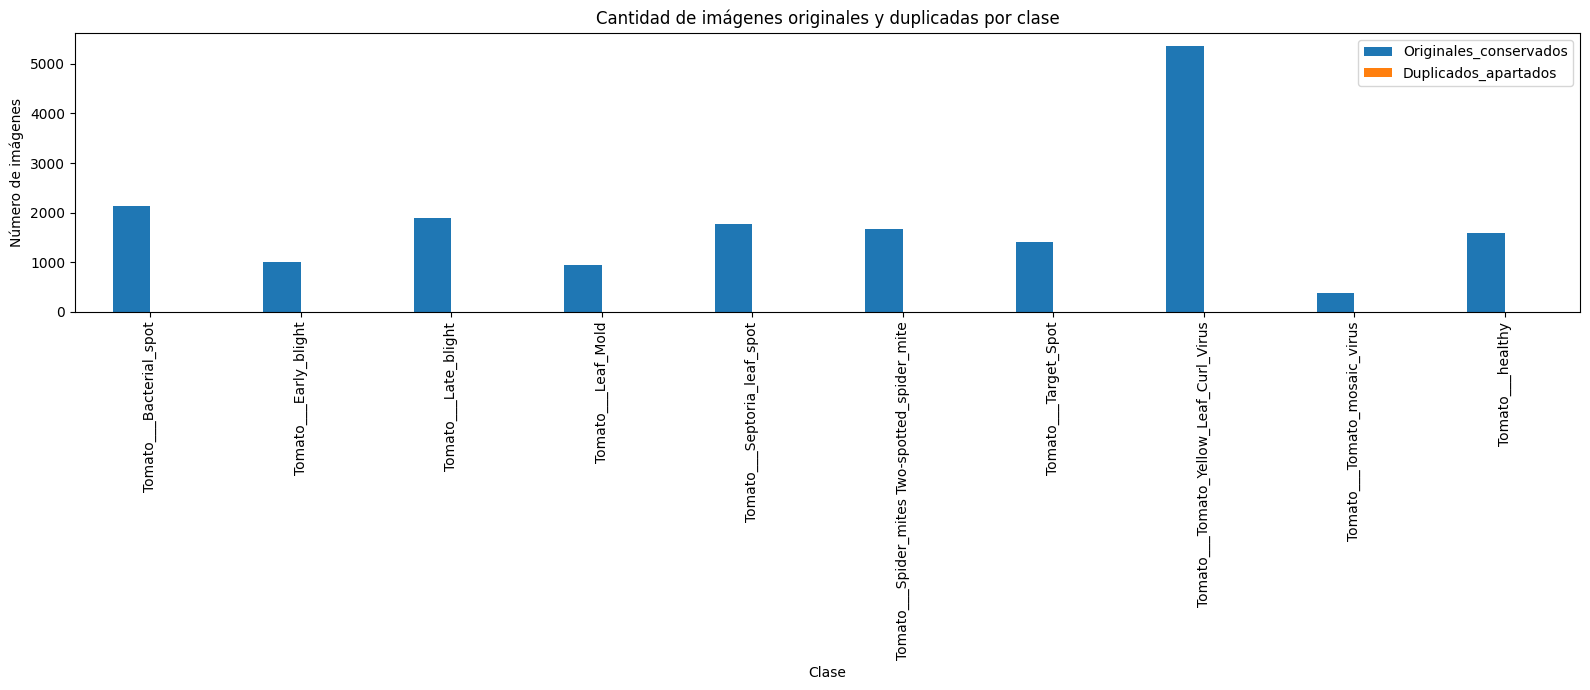

In [133]:
# ============================================================
# BLOQUE 11
# VISUALIZACIÓN ORIGINALES VS DUPLICADOS
# ============================================================

import matplotlib.pyplot as plt


df_grafico = (
    df_comparacion
    .set_index("Clase")
    [
        [
            "Originales_conservados",
            "Duplicados_apartados"
        ]
    ]
)


ax = df_grafico.plot(
    kind="bar",
    figsize=(16, 7)
)


ax.set_title(
    "Cantidad de imágenes originales y duplicadas por clase"
)

ax.set_xlabel(
    "Clase"
)

ax.set_ylabel(
    "Número de imágenes"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.show()

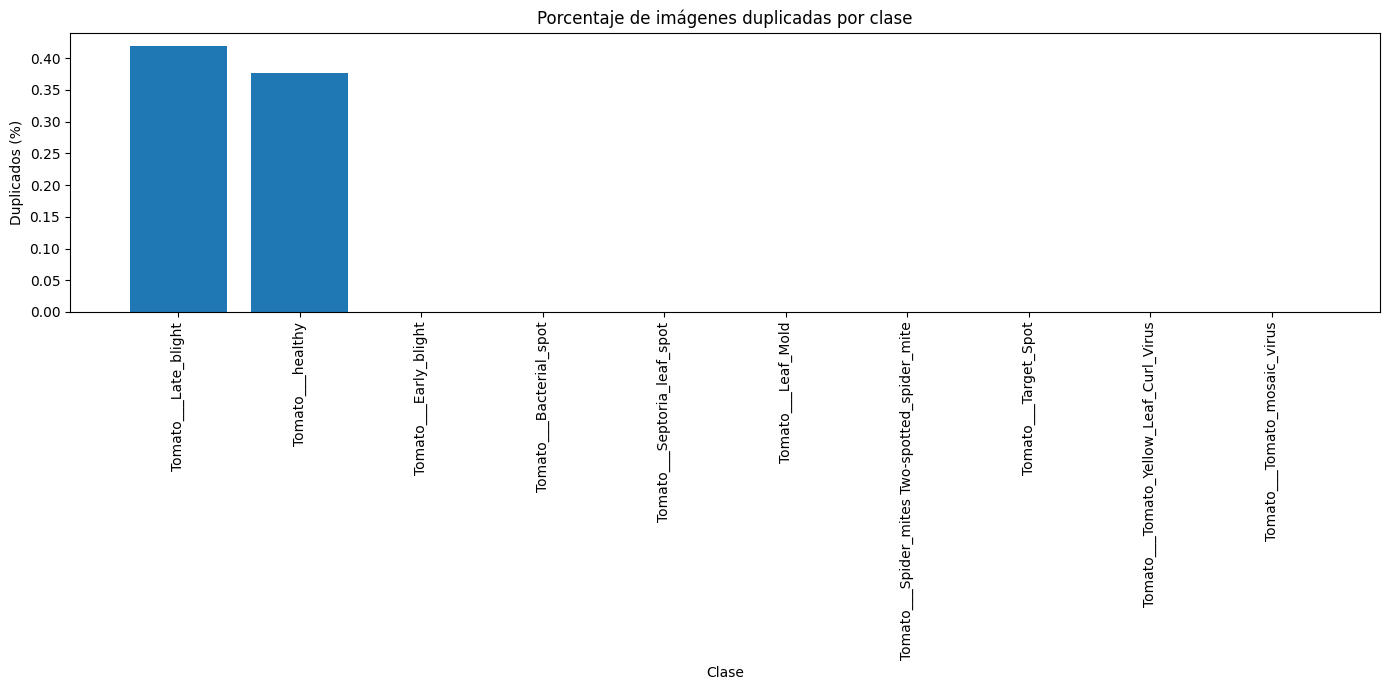

In [134]:
# ============================================================
# BLOQUE 12
# PORCENTAJE DE DUPLICADOS POR CLASE
# ============================================================

df_porcentaje = (
    df_comparacion
    .sort_values(
        "Duplicados_%",
        ascending=False
    )
)


plt.figure(
    figsize=(14, 7)
)


plt.bar(
    df_porcentaje["Clase"],
    df_porcentaje["Duplicados_%"]
)


plt.title(
    "Porcentaje de imágenes duplicadas por clase"
)

plt.xlabel(
    "Clase"
)

plt.ylabel(
    "Duplicados (%)"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.show()

In [135]:
# ============================================================
# BLOQUE 13
# EXPORTAR TABLA COMPARATIVA
# ============================================================

RUTA_REPORTE = (
    "/content/plantvillage/"
    "comparacion_originales_vs_duplicados.csv"
)


df_comparacion.to_csv(
    RUTA_REPORTE,
    index=False
)


print(
    "✅ Reporte guardado correctamente:"
)

print(RUTA_REPORTE)

✅ Reporte guardado correctamente:
/content/plantvillage/comparacion_originales_vs_duplicados.csv


# Fase 1 - Definición formal del problema
Esta fase establece qué problema se resolverá, cuál es la variable objetivo y por qué la solución tiene
utilidad práctica

## 1.1 Contexto
Proyecto Final - Deep Learning | PlantVillage | MLP vs CNN
- Importancia de identificar enfermedades vegetales.
- Utilidad de automatizar la clasificación a partir de imágenes.
- Características visuales que pueden diferenciar estados sanitarios.
- Uso de imágenes de hojas como modalidad principal de datos.

### **1.1 Contexto**

La identificación de enfermedades en plantas constituye un problema relevante dentro del ámbito agrícola, debido a que la aparición de patologías puede afectar el desarrollo de los cultivos, disminuir su rendimiento y generar pérdidas productivas. En particular, muchas enfermedades vegetales producen modificaciones visibles en las hojas, por lo que el análisis de imágenes puede utilizarse como una fuente de información para reconocer diferentes estados sanitarios.

En este proyecto se trabaja con imágenes de hojas de **tomate** provenientes del dataset **PlantVillage**, considerando distintas enfermedades foliares y una categoría correspondiente a hojas saludables. El objetivo es utilizar estas imágenes para construir modelos capaces de distinguir automáticamente entre diferentes clases sanitarias.

La automatización de este proceso mediante técnicas de **Deep Learning y Visión por Computador** permite analizar directamente las imágenes sin necesidad de definir manualmente todas las características visuales relevantes. En lugar de proporcionar al modelo variables previamente diseñadas, las redes neuronales pueden aprender representaciones a partir de los píxeles disponibles en las imágenes.

Las enfermedades foliares pueden manifestarse mediante diferentes características visuales, entre ellas:

* cambios de coloración;
* presencia de manchas o lesiones;
* variaciones en la textura de la hoja;
* alteraciones en los bordes;
* diferencias en la distribución espacial de las zonas afectadas;
* patrones visuales asociados a determinadas enfermedades.

Estas características no se encuentran representadas como variables independientes dentro del dataset, sino que están distribuidas espacialmente en las imágenes. Por esta razón, el problema requiere que el modelo aprenda automáticamente patrones visuales capaces de diferenciar una clase de otra.

De forma conceptual, el proceso de aprendizaje puede representarse como:

$[
\text{Píxeles}
\rightarrow
\text{bordes}
\rightarrow
\text{texturas}
\rightarrow
\text{formas}
\rightarrow
\text{patrones foliares}
\rightarrow
\text{clase sanitaria}
]$

La modalidad principal de datos utilizada en este proyecto corresponde, por tanto, a **imágenes digitales de hojas de tomate**. Después de las etapas de filtrado, verificación de integridad y eliminación de duplicados exactos realizadas en el notebook, el conjunto de datos de trabajo contiene **18.146 imágenes únicas distribuidas en 10 clases**, correspondientes a distintas enfermedades y al estado saludable de la planta.

Este contexto proporciona una base adecuada para comparar dos estrategias de aprendizaje profundo: una **MLP**, que utilizará una representación vectorizada de las imágenes, y una **CNN**, que conservará y explotará explícitamente su estructura espacial. La comparación permitirá estudiar si el aprendizaje de patrones espaciales propios de una red convolucional proporciona una ventaja observable en la clasificación de enfermedades foliares del tomate.


## 1.2 Tipo de problema

Clasificación multiclase

- Cada imagen X_i deberá asociarse con una categoría y_i perteneciente al conjunto de K clases  disponibles.

### **1.2 Tipo de problema**

El problema abordado en este proyecto corresponde a una tarea de **clasificación supervisada multiclase**.

Se considera **aprendizaje supervisado** porque cada imagen del conjunto de datos posee previamente una etiqueta que identifica su correspondiente **estado sanitario o categoría foliar**. Durante el entrenamiento, el modelo utilizará pares de datos de la forma:

$[
(X_i, y_i)
]$

donde:

* $(X_i)$ representa la imagen de una hoja de tomate.
* $(y_i)$ representa la clase asociada a dicha imagen.

Después de las etapas de filtrado, consolidación, verificación de integridad y eliminación de duplicados desarrolladas en el notebook, el conjunto de datos definitivo contiene:

$[
N = 18,146
]$

imágenes únicas distribuidas en:

$[
K = 10
]$

clases.

La hoja de ruta establece precisamente que cada imagen (X_i) debe asociarse con una categoría (y_i) perteneciente al conjunto de (K) clases disponibles.

Por lo tanto, para cada imagen se debe determinar una única etiqueta perteneciente al conjunto:

$[
\mathcal{C}
=
{
c_1,c_2,\ldots,c_{10}
}
]$

En los datos procesados en el notebook, las diez clases corresponden a:

1. `Tomato___Bacterial_spot`
2. `Tomato___Early_blight`
3. `Tomato___Late_blight`
4. `Tomato___Leaf_Mold`
5. `Tomato___Septoria_leaf_spot`
6. `Tomato___Spider_mites Two-spotted_spider_mite`
7. `Tomato___Target_Spot`
8. `Tomato___Tomato_Yellow_Leaf_Curl_Virus`
9. `Tomato___Tomato_mosaic_virus`
10. `Tomato___healthy`

De esta forma, el objetivo puede expresarse matemáticamente mediante una función de clasificación:

$[
f_{\theta}: X_i \longrightarrow y_i
]$

donde $(f_{\theta})$ representa el modelo parametrizado por (\theta), encargado de aprender patrones visuales presentes en las imágenes para asignarlas a una de las diez categorías posibles.

La tarea es **multiclase** porque existen más de dos categorías posibles y cada imagen debe ser asignada a una única clase. Esto la diferencia de una clasificación binaria, donde solamente existen dos posibles resultados, y de un problema de regresión, donde la salida corresponde a un valor numérico continuo.

Conceptualmente, el proceso puede representarse como:

$[
\text{Imagen de hoja de tomate}
\rightarrow
\text{Modelo de clasificación}
\rightarrow
\text{una de 10 clases sanitarias}
]$

En las etapas posteriores del proyecto, tanto la **MLP** como la **CNN** resolverán exactamente la misma tarea de clasificación y utilizarán las mismas categorías de salida. Esto permitirá realizar posteriormente una comparación experimental bajo un criterio común, tal como exige el enunciado para la combinación **MLP + CNN** aplicada a imágenes.

En síntesis, el problema queda formalmente definido como:

$[
\boxed{\text{Clasificación supervisada multiclase de imágenes de hojas de tomate en 10 categorías}}
]$


## 1.3 Variable objetivo
La variable objetivo corresponde a la clase de enfermedad o estado sanitario de la hoja, inferida a partir  del directorio de clase al que pertenece cada imagen.

### **1.3 Variable objetivo**

La **variable objetivo** del proyecto corresponde a la **clase de enfermedad o estado sanitario de cada hoja de tomate**. En el dataset PlantVillage, esta información se encuentra determinada por el **directorio o carpeta de clase** al que pertenece cada imagen, tal como establece la hoja de ruta del proyecto.

Por lo tanto, para cada imagen (X_i) existe una etiqueta asociada (y_i), donde:

$[
X_i = \text{imagen de una hoja de tomate}
]$

y:

$[
y_i = \text{clase sanitaria asociada a la imagen}
]$

Después de las etapas de filtrado, consolidación, verificación de integridad y eliminación de archivos duplicados exactos realizadas en el notebook, el conjunto de datos utilizado contiene:

$[
N = 18,146
]$

imágenes únicas, distribuidas en:

$[
K = 10
]$

clases diferentes.

Las categorías que conforman la variable objetivo son:

1. `Tomato___Bacterial_spot`
2. `Tomato___Early_blight`
3. `Tomato___Late_blight`
4. `Tomato___Leaf_Mold`
5. `Tomato___Septoria_leaf_spot`
6. `Tomato___Spider_mites Two-spotted_spider_mite`
7. `Tomato___Target_Spot`
8. `Tomato___Tomato_Yellow_Leaf_Curl_Virus`
9. `Tomato___Tomato_mosaic_virus`
10. `Tomato___healthy`

De estas diez categorías, **nueve representan diferentes enfermedades o afecciones foliares**, mientras que una corresponde al estado **saludable (`healthy`)** de la hoja.

Matemáticamente, la variable objetivo puede representarse como:

$[
y_i \in \mathcal{C}
]$

donde:

$[
\mathcal{C}
=
{c_1,c_2,\ldots,c_{10}}
]$

representa el conjunto de las diez clases posibles.

El objetivo de los modelos será, por tanto, aprender una función:

$[
f_{\theta}(X_i)=\hat{y}_i
]$

donde:

* $(X_i)$ corresponde a la imagen de entrada.
* $(f_{\theta})$ representa el modelo de Deep Learning parametrizado por $(\theta)$.
* $(\hat{y}_i)$ corresponde a la clase predicha por el modelo.
* $(y_i)$ corresponde a la clase real utilizada como referencia durante el entrenamiento y evaluación.

Conceptualmente:

$[
\text{Imagen de hoja}
\rightarrow
\text{MLP o CNN}
\rightarrow
\text{Probabilidades para 10 clases}
\rightarrow
\text{Clase predicha}
]$

En la etapa de modelamiento, la capa de salida de ambas redes deberá contener **10 neuronas**, una por cada clase:

$[
\mathbf{p}
=
[p_1,p_2,\ldots,p_{10}]
]$

donde cada (p_k) representa la probabilidad estimada de que la imagen pertenezca a la clase (k). La predicción final corresponderá a la categoría con mayor probabilidad:

$[
\hat{y}
=
\arg\max_k p_k
]$

Esta definición permite que tanto la **MLP** como la **CNN** resuelvan exactamente la misma tarea predictiva y utilicen la misma variable objetivo, condición necesaria para realizar posteriormente una comparación experimental justa entre ambas arquitecturas.

En síntesis, la variable objetivo del proyecto queda definida como:

$[
\boxed{
\text{Clase de enfermedad o estado saludable de la hoja de tomate}
}
]$

con **10 categorías posibles** obtenidas directamente de la estructura de clases del dataset PlantVillage procesado en el notebook.


## 1.4 Pregunta central
- ¿La utilización de una CNN permite clasificar las enfermedades de las hojas con mayor capacidad de  generalización que una MLP entrenada sobre una representación vectorizada de las mismas imágenes?

### **1.4 Pregunta central**

La pregunta central del proyecto busca determinar si la **estructura arquitectónica de una Red Neuronal Convolucional (CNN)** proporciona una ventaja real frente a una **Red Neuronal Multicapa (MLP)** cuando ambas son utilizadas para resolver exactamente el mismo problema de clasificación de enfermedades foliares del tomate.

La hoja de ruta establece como pregunta experimental:

> **¿La utilización de una CNN permite clasificar las enfermedades de las hojas con mayor capacidad de generalización que una MLP entrenada sobre una representación vectorizada de las mismas imágenes?**

Esta pregunta es coherente con el propósito del proyecto, ya que la comparación **MLP vs CNN** debe representar dos hipótesis diferentes acerca de cómo utilizar la información contenida en una imagen. La hoja de ruta plantea explícitamente que la MLP trabaja sobre una imagen aplanada, mientras que la CNN conserva y explota su estructura espacial.

Considerando los datos obtenidos y procesados en el notebook, el experimento se desarrollará sobre un conjunto definitivo de:

$[
N = 18,146
]$

imágenes únicas de hojas de tomate, distribuidas en:

$[
K = 10
]$

clases correspondientes a diferentes enfermedades foliares y al estado saludable.

Las imágenes presentan una resolución original de:

$[
256 \times 256
]$

píxeles, utilizan tres canales de color **RGB** y han sido previamente verificadas en términos de integridad y duplicados. De esta forma, ambas arquitecturas podrán ser evaluadas sobre la misma fuente de información visual.

---

#### **Hipótesis representada por la MLP**

La MLP utilizará una representación vectorizada de cada imagen. Conceptualmente:

$[
X_i \in \mathbb{R}^{H\times W\times C}
]$

será transformada mediante una operación de aplanamiento:

$[
\operatorname{Flatten}(X_i)
\in
\mathbb{R}^{HWC}
]$

Por ejemplo, manteniendo la resolución original:

$[
256\times256\times3
=
196,608
]$

valores de entrada por imagen.

El principal efecto de esta transformación es que la estructura bidimensional de la imagen deja de encontrarse representada explícitamente. Para la MLP, los píxeles pasan a formar parte de un único vector y las relaciones de vecindad espacial deben ser aprendidas indirectamente a partir de conexiones densas.

Conceptualmente:

$[
\text{Imagen}
\rightarrow
\text{Flatten}
\rightarrow
\text{MLP}
\rightarrow
\text{Clase}
]$

---

#### **Hipótesis representada por la CNN**

La CNN, en cambio, recibe la imagen preservando sus dimensiones espaciales:

$[
X_i
\in
\mathbb{R}^{H\times W\times C}
]$

y utiliza filtros convolucionales para aprender patrones locales.

Conceptualmente, el aprendizaje puede representarse mediante:

$[
\text{píxeles}
\rightarrow
\text{bordes}
\rightarrow
\text{texturas}
\rightarrow
\text{formas}
\rightarrow
\text{patrones de lesión}
\rightarrow
\text{clase}
]$

La hoja de ruta identifica precisamente como ventajas de la CNN la **detección de patrones locales, la compartición de pesos y el aprendizaje jerárquico de características**, mientras que señala que el aplanamiento realizado por una MLP elimina la representación espacial explícita.

---

#### **Comparación experimental**

La pregunta central no pretende simplemente identificar cuál modelo obtiene una mayor exactitud, sino determinar si la incorporación explícita de estructura espacial produce una **mejora observable y generalizable**.

Por ello, el experimento deberá mantener constantes, en la medida de lo posible, las condiciones comunes de comparación:

$[
\text{mismas imágenes}
]$

$[
\text{mismos subconjuntos de Train, Validation y Test}
]$

$[
\text{misma variable objetivo}
]$

$[
\text{mismas 10 clases}
]$

$[
\text{métricas de evaluación comunes}
]$

El propio enunciado señala que una comparación MLP + CNN sobre imágenes debe contrastar una **imagen aplanada** frente a una arquitectura que **explota la estructura espacial**, y exige que ambas redes sean comparadas de forma significativa y bajo criterios adecuados.

---

#### **Capacidad de generalización**

En este proyecto, la generalización se entenderá como la capacidad del modelo para clasificar correctamente **imágenes que no fueron utilizadas para ajustar sus parámetros**.

Por tanto, el rendimiento sobre entrenamiento no será suficiente para responder la pregunta central. Será necesario analizar posteriormente:

* desempeño sobre validación;
* desempeño final sobre test;
* diferencia entre entrenamiento y validación;
* presencia de sobreajuste;
* comportamiento por clase;
* matriz de confusión;
* errores de clasificación.

Las métricas recomendadas por el enunciado para tareas de clasificación incluyen **Accuracy, Balanced Accuracy, Precision, Recall y F1**, además de matrices de confusión y otras métricas cuando corresponda.

La comparación podrá expresarse posteriormente mediante:

$[
\Delta M =
M_{\mathrm{CNN}} - M_{\mathrm{MLP}}
]$

donde $(M)$ representa una métrica determinada. Por ejemplo:

$[
\Delta F1_{\text{macro}}
=
F1_{\text{CNN}}
F1_{\text{MLP}}
]$

Una diferencia positiva favorecería experimentalmente a la CNN para dicha métrica, pero la conclusión definitiva deberá considerar conjuntamente rendimiento, sobreajuste, errores y costo computacional.

---

#### **Hipótesis experimental**

A partir de las propiedades de ambas arquitecturas se plantea como hipótesis de trabajo:

$[
\boxed{
H_1:
\text{La CNN presentará una mejor capacidad de generalización que la MLP}
}
]$

debido a que puede aprovechar explícitamente las relaciones espaciales existentes entre los píxeles y aprender patrones visuales locales y jerárquicos asociados a las enfermedades foliares.

Como hipótesis alternativa de ausencia de ventaja arquitectónica puede plantearse:

$[
\boxed{
H_0:
\text{La CNN no presentará una mejora relevante de generalización frente a la MLP}
}
]$

Estas hipótesis **no se consideran demostradas en esta fase**. La Fase 1 solamente establece la pregunta experimental. La respuesta deberá obtenerse posteriormente mediante entrenamiento, validación y evaluación final de ambas arquitecturas.

En consecuencia, la pregunta central queda operacionalizada como:

$[
\boxed{
\begin{aligned}
&\text{¿La preservación y explotación de la estructura espacial mediante una CNN}\
&\text{produce una mejora observable y generalizable en la clasificación}\
&\text{de las 10 clases de hojas de tomate respecto de una MLP}\
&\text{entrenada sobre una representación vectorizada de las mismas imágenes?}
\end{aligned}
}
]$

Esta formulación permitirá que las etapas posteriores del proyecto respondan la pregunta mediante **evidencia experimental**, en lugar de asumir anticipadamente que una arquitectura es superior a la otra.


# Fase 2 - Justificación del uso de Deep Learning

El proyecto exige demostrar que Deep Learning es una decisión metodológica fundamentada. La justificación debe construirse antes del entrenamiento y luego respaldarse con evidencia experimental.

## 2.1 ¿Existe suficiente cantidad y complejidad?

La evaluación debe considerar tanto el número total de imágenes como su distribución entre clases. Un  volumen elevado no es suficiente si algunas categorías presentan muy pocos ejemplos.

N_total = suma de N_i  para i = 1, ..., K  

- Cantidad total de imágenes válidas y únicas después de la depuración. Número final de clases.   
- Cantidad mínima, máxima y mediana de imágenes por clase.
- Porcentaje de participación de cada clase.
- Existencia de clases significativamente sobrerrepresentadas o subrepresentadas.



La complejidad también proviene de la alta dimensionalidad y de la estructura espacial de cada imagen:  color, textura, manchas, bordes, lesiones y formas no aparecen como variables explícitas, sino que  deben aprenderse a partir de los píxeles.



Píxeles -> bordes -> texturas -> formas -> patrones de lesión -> clase

### **2.1 ¿Existe suficiente cantidad y complejidad?**

Uno de los requisitos centrales del proyecto consiste en justificar que el uso de **Deep Learning** responde a las características reales del problema y del conjunto de datos, y no solamente a una elección de modelamiento. El enunciado exige determinar si existe una cantidad y complejidad suficiente de datos para aprender patrones no triviales, mientras que la hoja de ruta establece que este análisis debe considerar tanto el volumen total como la distribución de observaciones entre las clases.

#### **Cantidad total de imágenes**

Después del filtrado de PlantVillage se conservaron exclusivamente las categorías correspondientes a hojas de tomate. Antes de la eliminación de duplicados, el conjunto consolidado contenía:

$[
N_{\text{antes}} = 18,160
]$

imágenes.

La verificación de integridad realizada en el notebook determinó que las **18.160 imágenes eran válidas**, sin archivos problemáticos detectados, obteniéndose un porcentaje de integridad del:

$[
100%
]$

Posteriormente, mediante comparación de hashes **SHA-256**, se identificaron y apartaron **14 copias redundantes exactas**, equivalentes aproximadamente al:

$[
\frac{14}{18,160}\times100
\approx 0.08%
]$

del conjunto original.

Por tanto, el dataset definitivo utilizado para continuar el experimento contiene:

$[
\boxed{N_{\text{total}} = 18,146}
]$

imágenes válidas y únicas.

De acuerdo con la formulación propuesta en la hoja de ruta:

$[
N_{\text{total}}
=
\sum_{i=1}^{K}N_i
]$

donde $(N_i)$ corresponde al número de imágenes pertenecientes a la clase $(i)$ y:

$[
K=10
]$
representa el número final de clases.

En este caso se verifica:

$[
\boxed{
18,146=
\sum_{i=1}^{10}N_i
}
]$

---

#### **Distribución de imágenes entre clases**

Después de la depuración, las imágenes se encuentran distribuidas de la siguiente manera:

| Clase                                           |   Imágenes | Participación |
| ----------------------------------------------- | ---------: | ------------: |
| `Tomato___Bacterial_spot`                       |      2.127 |       11,72 % |
| `Tomato___Early_blight`                         |      1.000 |        5,51 % |
| `Tomato___Late_blight`                          |      1.901 |       10,48 % |
| `Tomato___Leaf_Mold`                            |        952 |        5,25 % |
| `Tomato___Septoria_leaf_spot`                   |      1.771 |        9,76 % |
| `Tomato___Spider_mites Two-spotted_spider_mite` |      1.676 |        9,24 % |
| `Tomato___Target_Spot`                          |      1.404 |        7,74 % |
| `Tomato___Tomato_Yellow_Leaf_Curl_Virus`        |      5.357 |   **29,52 %** |
| `Tomato___Tomato_mosaic_virus`                  |        373 |    **2,06 %** |
| `Tomato___healthy`                              |      1.585 |        8,73 % |
| **Total**                                       | **18.146** |     **100 %** |

La cantidad mínima de imágenes por clase corresponde a:

$[
\boxed{N_{\min}=373}
]$

para:

`Tomato___Tomato_mosaic_virus`

mientras que la cantidad máxima corresponde a:

$[
\boxed{N_{\max}=5,357}
]$

para:

`Tomato___Tomato_Yellow_Leaf_Curl_Virus`.

Al ordenar las cantidades de imágenes:

$[
373,;952,;1000,;1404,;1585,;1676,;1771,;1901,;2127,;5357
]$

la mediana corresponde a:

$[
\operatorname{Mediana}(N_i)
=\frac{1585+1676}{2} \boxed{1630.5}
]$

imágenes por clase.

---

#### **Análisis del desbalance**

Aunque el dataset posee un volumen total considerable, su distribución no es uniforme.

La clase `Tomato___Tomato_Yellow_Leaf_Curl_Virus` representa aproximadamente:




$$
\boxed{29.52\%}
$$


del conjunto completo, mientras que `Tomato___Tomato_mosaic_virus` representa solamente:



$$
\boxed{2.06\%}
$$

Una forma de cuantificar esta diferencia es mediante la razón de desbalance:

$[
IR=
\frac{N_{\max}}{N_{\min}}
]$

por lo que:

$[
IR=
\frac{5357}{373}
\approx
\boxed{14.36}
]$

Esto significa que la clase mayoritaria contiene aproximadamente **14,4 veces más imágenes que la clase minoritaria**.

Por lo tanto, se identifica una **sobrerrepresentación importante** de `Tomato___Tomato_Yellow_Leaf_Curl_Virus` y una **subrepresentación relativa** de `Tomato___Tomato_mosaic_virus`.

Este resultado no impide utilizar Deep Learning, pero deberá ser considerado en las fases posteriores, especialmente durante:

* la división estratificada de `train`, `validation` y `test`;
* el entrenamiento de los modelos;
* la interpretación de las métricas;
* el análisis de errores por clase.

En consecuencia, posteriormente no será conveniente evaluar los modelos exclusivamente mediante `accuracy`, ya que una métrica global puede ocultar un rendimiento deficiente sobre las clases minoritarias. La hoja de ruta contempla precisamente métricas como **Balanced Accuracy, Precision, Recall y F1**, además de la matriz de confusión, para analizar el comportamiento de los modelos ante esta situación.

---

### **Complejidad de los datos**

La justificación de Deep Learning no depende únicamente de disponer de 18.146 ejemplos. También es necesario analizar la **complejidad de cada observación**.

Las imágenes procesadas en el notebook presentan características homogéneas:

$[
256\times256
]$

píxeles de resolución y tres canales de color:

$[
RGB
]$

Por tanto, cada imagen puede representarse inicialmente como un tensor:

$[
X_i\in\mathbb{R}^{256\times256\times3}
]$

lo que supone:

$[
256\times256\times3
=
\boxed{196,608}
]$

valores de intensidad por imagen.

Esta alta dimensionalidad diferencia claramente el problema de un conjunto tabular compuesto por unas pocas variables predictoras.

Sin embargo, la complejidad más importante no procede solamente del número de píxeles. La información necesaria para identificar una enfermedad se encuentra **distribuida espacialmente dentro de la imagen**.

Variables como:

* coloración;
* textura;
* manchas;
* lesiones;
* bordes;
* formas;
* tamaño y distribución de las zonas afectadas;

no se encuentran disponibles como columnas explícitas del dataset.

El modelo recibe fundamentalmente los valores de los píxeles y debe aprender qué combinaciones de ellos resultan útiles para distinguir los diferentes estados sanitarios.

Conceptualmente, el aprendizaje esperado puede representarse mediante:

$[
\boxed{
\text{Píxeles}
\rightarrow
\text{bordes}
\rightarrow
\text{texturas}
\rightarrow
\text{formas}
\rightarrow
\text{patrones de lesión}
\rightarrow
\text{clase}
}
]$

Esta característica es precisamente uno de los argumentos centrales establecidos en la hoja de ruta para justificar Deep Learning: color, textura, manchas, bordes, lesiones y formas **no aparecen como variables explícitas**, sino que deben aprenderse a partir de la representación visual.

---

### **Cantidad y complejidad consideradas conjuntamente**

La evaluación del dataset muestra entonces dos características simultáneas.

Por una parte, existe un volumen de:

$[
\boxed{18,146\text{ imágenes únicas}}
]$

distribuidas entre:

$[
\boxed{10\text{ clases}}
]$

lo que proporciona una base de datos suficientemente amplia para plantear un experimento acotado de Deep Learning en Google Colab.

Por otra parte, cada observación posee una estructura:

$[
256\times256\times3
]$

y contiene relaciones espaciales que no pueden reducirse directamente a unas pocas variables previamente definidas.

Por tanto, la complejidad del problema puede resumirse como:

$[
\boxed{
\text{volumen de datos}
+
\text{alta dimensionalidad}
+
\text{estructura espacial}
+
\text{patrones visuales no explícitos}
+
\text{clasificación en 10 categorías}
}
]$

El propio enunciado considera apropiada la combinación **MLP + CNN para imágenes**, específicamente para contrastar una representación aplanada con una arquitectura que explota la estructura espacial.

---

### **Conclusión de la sección 2.1**

A partir de los resultados obtenidos en el notebook, se considera que **sí existe una cantidad y complejidad suficientes para justificar el desarrollo del experimento mediante Deep Learning**.

La afirmación se fundamenta en que:

$[
\boxed{
\begin{aligned}
N_{\text{total}} &= 18,146\
K &= 10\
N_{\min} &= 373\
N_{\max} &= 5,357\
\operatorname{Mediana}(N_i) &= 1,630.5\
IR &\approx 14.36
\end{aligned}
}
]$

Además, cada imagen contiene **196.608 valores de entrada en su resolución original**, organizados espacialmente en tres canales RGB, y las características relevantes para la clasificación deben ser aprendidas a partir de los píxeles.

No obstante, el análisis también identifica una limitación que deberá mantenerse presente durante el proyecto: **la distribución entre clases es desbalanceada**. Esta situación no invalida el dataset, pero exige una partición estratificada y métricas que permitan evaluar adecuadamente el rendimiento sobre las categorías minoritarias.

En consecuencia:

$[
\boxed{
\text{Sí existe suficiente cantidad y complejidad para estudiar Deep Learning,}
}
]$

pero la verdadera ventaja de las arquitecturas profundas —y particularmente de la CNN— deberá ser **demostrada posteriormente mediante evidencia experimental**, comparando su capacidad de generalización con la MLP y no asumiéndola de antemano.


## 2.2 ¿Por qué las imágenes justifican Deep Learning?
Una imagen conserva relaciones espaciales entre píxeles. Las CNN están diseñadas para explotar esa  estructura mediante filtros convolucionales y aprendizaje jerárquico de representaciones.

### **2.2 ¿Por qué las imágenes justifican Deep Learning?**

La utilización de **Deep Learning** se encuentra especialmente justificada cuando los datos de entrada poseen una estructura compleja cuya información relevante no está disponible como un conjunto reducido de variables previamente definidas. Este es precisamente el caso del proyecto, ya que la modalidad principal de los datos corresponde a **imágenes digitales de hojas de tomate**.

El enunciado del proyecto establece que una de las preguntas centrales para justificar Deep Learning es determinar si la modalidad de los datos favorece el **aprendizaje automático de representaciones**. Asimismo, propone explícitamente la combinación **MLP + CNN** para problemas basados en imágenes, comparando una representación aplanada con una arquitectura que explota su estructura espacial.

Después de las etapas de filtrado, verificación de integridad y eliminación de duplicados realizadas en el notebook, el conjunto de datos de trabajo contiene:

$[
\boxed{18,146\text{ imágenes únicas}}
]$

distribuidas en:

$[
\boxed{10\text{ clases}}
]$

correspondientes a diferentes enfermedades foliares del tomate y a la categoría de hojas saludables.

Las imágenes presentan una resolución original de:

$[
256\times256
]$

píxeles y tres canales de color **RGB**, por lo que cada observación puede representarse como un tensor:

$[
X_i\in\mathbb{R}^{256\times256\times3}
]$

Esto significa que una sola imagen contiene:

$[
256\times256\times3
=\boxed{196,608}
]$

valores de intensidad.

Sin embargo, la principal razón para utilizar Deep Learning **no es solamente la elevada cantidad de valores por imagen**, sino la forma en que estos valores se encuentran organizados.

---

#### **La información de una imagen posee estructura espacial**

En una imagen, la posición de cada píxel importa. Un píxel no constituye una observación independiente: su significado visual depende de los píxeles que se encuentran a su alrededor.

Formalmente, una imagen RGB puede representarse como:

$[
X(i,j,c)
]$

donde:

* $(i)$ representa la posición vertical;
* $(j)$ representa la posición horizontal;
* $(c)$ representa el canal de color.

Por lo tanto, valores próximos como:

$[
X(i,j,c)
]$

y:

$[
X(i+1,j,c)
]$

mantienen una relación de proximidad espacial.

Esta relación es fundamental para reconocer estructuras visuales como:

* bordes;
* manchas;
* cambios de coloración;
* texturas;
* lesiones;
* contornos;
* formas;
* distribución espacial de zonas afectadas.

En consecuencia:

$[
\boxed{
\text{la posición relativa de los píxeles contiene información}
}
]$

y esa información debe ser considerada por el modelo.

---

#### **Las características relevantes no están definidas explícitamente**

A diferencia de un problema tabular, el dataset no proporciona columnas como:

```text
intensidad_de_manchas
color_de_lesion
textura_foliar
forma_de_la_lesion
porcentaje_de_superficie_afectada
```

Estas variables **no existen directamente en los datos**.

El modelo recibe esencialmente una matriz de píxeles y debe descubrir qué características resultan útiles para diferenciar las diez clases.

Por ejemplo, una determinada enfermedad puede caracterizarse por una combinación de:

$[
\text{color}
+
\text{textura}
+
\text{forma}
+
\text{localización}
]$

y no por una única característica aislada.

Por tanto, el problema requiere un mecanismo de **aprendizaje de representaciones**, es decir, que el modelo construya internamente características cada vez más informativas a partir de los datos originales.

Este principio coincide directamente con la hoja de ruta, que establece que características como color, textura, manchas, bordes, lesiones y formas no aparecen como variables explícitas, sino que deben ser aprendidas a partir de los píxeles.

---

### **Aprendizaje jerárquico de representaciones**

Una de las principales capacidades del Deep Learning es aprender características de manera jerárquica.

Conceptualmente, el proceso puede representarse como:

$[
\boxed{
\text{Píxeles}
\rightarrow
\text{Bordes}
\rightarrow
\text{Texturas}
\rightarrow
\text{Formas}
\rightarrow
\text{Patrones de lesión}
\rightarrow
\text{Clase}
}
]$

Las primeras capas de una red pueden aprender patrones visuales relativamente simples, mientras que capas posteriores combinan estas representaciones para detectar estructuras progresivamente más complejas.

Por ejemplo:

#### Nivel 1 — Información básica

$[
\text{píxeles}
\rightarrow
\text{cambios de intensidad y color}
]$

#### Nivel 2 — Patrones locales

$[
\text{cambios locales}
\rightarrow
\text{bordes y pequeñas texturas}
]$

#### Nivel 3 — Estructuras visuales

$[
\text{bordes + texturas}
\rightarrow
\text{manchas o lesiones}
]$

#### Nivel 4 — Patrones de mayor nivel

$[
\text{lesiones + formas + distribución}
\rightarrow
\text{patrón foliar}
]$

#### Nivel 5 — Clasificación

$[
\text{patrón foliar}
\rightarrow
\text{enfermedad o estado saludable}
]$

Esta capacidad de aprender automáticamente una jerarquía de características constituye una de las razones principales por las que Deep Learning resulta apropiado para el problema.

La hoja de ruta establece precisamente que las CNN están diseñadas para aprovechar las relaciones espaciales mediante **filtros convolucionales y aprendizaje jerárquico de representaciones**.

---

### **¿Cómo aprovecha una CNN la estructura espacial?**

Una **Convolutional Neural Network (CNN)** utiliza filtros o kernels que recorren regiones locales de la imagen.

De forma simplificada, una operación convolucional puede representarse como:

$[
Y(i,j)
=
\sum_{m}\sum_{n}
X(i+m,j+n),K(m,n)
]$

donde:

* $(X)$ representa la imagen de entrada;
* $(K)$ corresponde al filtro convolucional;
* $(Y)$ es el mapa de características obtenido.

El filtro analiza pequeños vecindarios de píxeles en lugar de tratar todos los valores de la imagen como elementos independientes.

Por ejemplo, un kernel de:

$[
3\times3
]$

analiza grupos locales de nueve posiciones espaciales a la vez.

Conceptualmente:

$[
\begin{bmatrix}
x_{1} & x_{2} & x_{3}\
x_{4} & x_{5} & x_{6}\
x_{7} & x_{8} & x_{9}
\end{bmatrix}
]$

Esto permite detectar estructuras locales que posteriormente pueden combinarse para formar patrones de mayor complejidad.

---

### **Relación con las imágenes del proyecto**

Las enfermedades incluidas en el dataset se manifiestan mediante información visual presente directamente en las hojas.

Por ello, el modelo deberá aprender relaciones como:

$[
\text{coloración local}
+
\text{textura}
+
\text{forma de manchas}
+
\text{distribución espacial}
\rightarrow
\text{clase sanitaria}
]$

El hecho de que todas las imágenes procesadas sean homogéneas en términos de resolución, canales de color y formato facilita la construcción posterior de un pipeline común de procesamiento, pero **no transforma el problema en una tarea sencilla**.

Aunque todas posean dimensiones:

$[
256\times256\times3
]$

el contenido espacial varía entre imágenes y entre clases. La dificultad consiste precisamente en aprender qué configuraciones visuales son discriminativas para cada enfermedad.

---

### **Deep Learning frente a extracción manual de características**

Una estrategia convencional podría intentar construir manualmente variables como:

$[
\text{color promedio},
\quad
\text{contraste},
\quad
\text{histograma RGB},
\quad
\text{textura}
]$

y utilizar posteriormente estas características en un clasificador tradicional.

El problema es que este enfoque requiere decidir previamente:

> **¿Qué características visuales son realmente importantes para distinguir las enfermedades?**

Deep Learning modifica este procedimiento:

$[
\text{Imagen}
\rightarrow
\text{aprendizaje automático de características}
\rightarrow
\text{clasificación}
]$

En lugar de:

$[
\text{Imagen}
\rightarrow
\text{características diseñadas manualmente}
\rightarrow
\text{clasificador}
]$

Esta capacidad resulta especialmente pertinente para PlantVillage, ya que las diferencias entre categorías se encuentran codificadas en patrones visuales que pueden involucrar múltiples niveles de información.

---

### **Justificación específica para el experimento MLP vs CNN**

La modalidad de los datos permite además construir una comparación metodológicamente significativa entre las dos arquitecturas seleccionadas.

Ambas redes recibirán información procedente de las mismas imágenes, pero la representación utilizada será diferente:

$[
\text{Imagen}
\rightarrow
\begin{cases}
\text{MLP: representación vectorizada}\
\text{CNN: representación espacial}
\end{cases}
]$

La CNN está diseñada específicamente para explotar:

$[
\text{localidad espacial}
+
\text{filtros convolucionales}
+
\text{aprendizaje jerárquico}
]$

mientras que el comportamiento de la MLP permitirá establecer una referencia experimental respecto de una representación que no explota explícitamente esa geometría.

Precisamente, el enunciado considera razonable para imágenes la comparación entre una **MLP con la imagen aplanada y una CNN que explota su estructura espacial**.

---

### **Conclusión de la sección 2.2**

La modalidad de los datos proporciona una justificación técnica clara para utilizar Deep Learning.

El dataset no está compuesto por unas pocas variables independientes, sino por **18.146 imágenes**, cada una con una estructura original de:

$[
256\times256\times3
]$

y, por tanto:

$[
196,608
]$

valores organizados espacialmente.

La información necesaria para diferenciar las diez categorías se encuentra distribuida entre los píxeles y se manifiesta mediante combinaciones de color, bordes, texturas, manchas, lesiones y formas que no están disponibles como variables explícitas.

Por ello:

$[
\boxed{
\text{Imagen}
\rightarrow
\text{representaciones visuales aprendidas}
\rightarrow
\text{clasificación}
}
]$

constituye una formulación natural del problema.

En consecuencia:

$[
\boxed{
\begin{aligned}
&\text{las imágenes justifican el uso de Deep Learning porque}\
&\text{contienen relaciones espaciales y patrones visuales complejos}\
&\text{que deben ser aprendidos automáticamente a partir de los píxeles.}
\end{aligned}
}
]$

La CNN constituye una arquitectura especialmente adecuada para estudiar esta hipótesis debido a su capacidad para explotar la **localidad espacial y el aprendizaje jerárquico de representaciones**. No obstante, que esta ventaja teórica produzca efectivamente una mayor capacidad de generalización sobre PlantVillage deberá demostrarse posteriormente mediante la comparación experimental con la MLP.


## 2.3 Limitación de una MLP
La MLP requiere aplanar la imagen. Al convertir una matriz H x W x C en un vector, la organización espacial deja de estar representada explícitamente.

### **2.3 Limitación de una MLP**

Una **Red Neuronal Multicapa (MLP, Multilayer Perceptron)** puede utilizarse para resolver problemas de clasificación de imágenes. Sin embargo, presenta una limitación estructural importante: antes de introducir una imagen en capas densas, normalmente es necesario transformar su representación tridimensional en un **vector unidimensional** mediante una operación de aplanamiento (`Flatten`).

Esta transformación conserva los valores numéricos de los píxeles, pero hace que la estructura espacial original de la imagen deje de estar representada explícitamente en la arquitectura de la red.

---

### **Representación original de las imágenes**

De acuerdo con los resultados obtenidos durante la preparación y auditoría del dataset, las imágenes utilizadas en el proyecto poseen una resolución original de:

$$
256 \times 256
$$

píxeles y tres canales de color:

$$
RGB
$$

Por lo tanto, cada imagen puede representarse matemáticamente como un tensor:

$$
X_i \in \mathbb{R}^{256 \times 256 \times 3}
$$

donde:

* $X_i$ representa la imagen $i$.
* $256 \times 256$ corresponde a sus dimensiones espaciales.
* $3$ corresponde a los canales de color rojo, verde y azul.

La cantidad total de valores presentes en una imagen es:

$$
256 \times 256 \times 3 = 196,608
$$

Por tanto, cada imagen original contiene:

$$
\boxed{196,608 \text{ valores}}
$$

Estos valores no se encuentran organizados arbitrariamente. Cada píxel posee una posición específica dentro de la imagen y mantiene relaciones espaciales con los píxeles cercanos.

---

### **Aplanamiento de la imagen**

Para utilizar directamente una imagen como entrada de una MLP, se aplica normalmente una operación de aplanamiento:

$$
X_i \in \mathbb{R}^{H \times W \times C}
$$

que transforma la imagen en:

$$
\operatorname{Flatten}(X_i)
\in
\mathbb{R}^{HWC}
$$

En el caso particular de las imágenes originales del proyecto:

$$
\mathbb{R}^{256 \times 256 \times 3}
\longrightarrow
\mathbb{R}^{196,608}
$$

Conceptualmente, el proceso puede representarse como:

$$
\text{Imagen}
\rightarrow
\text{Flatten}
\rightarrow
\text{Vector}
\rightarrow
\text{MLP}
\rightarrow
\text{Clase}
$$

La estructura típica de la MLP podría expresarse como:

$$
\text{Imagen}
\rightarrow
\text{Flatten}
\rightarrow
\text{Dense + ReLU}
\rightarrow
\text{Dropout}
\rightarrow
\text{Dense + ReLU}
\rightarrow
\text{Softmax}
$$

---

### **Pérdida de representación espacial explícita**

La principal limitación del aplanamiento no consiste en eliminar los valores de los píxeles. Todos ellos permanecen en el vector resultante.

La dificultad es que las relaciones espaciales entre los píxeles dejan de estar representadas explícitamente.

Antes del aplanamiento, un píxel puede expresarse como:

$$
X(i,j,c)
$$

donde:

* $i$ representa la posición vertical.
* $j$ representa la posición horizontal.
* $c$ representa el canal de color.

Después del aplanamiento, la imagen pasa a representarse como:

$$
\mathbf{x}*i =
[x_1,x_2,x_3,\ldots,x*{196608}]
$$

La MLP recibe entonces un vector de valores y sus capas densas no incorporan de manera explícita información acerca de:

* qué píxeles se encuentran próximos;
* qué píxeles pertenecen a una misma región;
* dónde aparecen las manchas;
* cómo se distribuyen las lesiones;
* cómo se organizan las texturas;
* qué relación espacial existe entre distintas partes de la hoja.

Por ejemplo, en una pequeña región de una imagen:

$$
\begin{bmatrix}
x_{1,1} & x_{1,2} & x_{1,3} \
x_{2,1} & x_{2,2} & x_{2,3} \
x_{3,1} & x_{3,2} & x_{3,3}
\end{bmatrix}
$$

el píxel $x_{2,2}$ posee una relación espacial directa con los píxeles que lo rodean.

Al aplanar esa matriz se obtiene una representación similar a:

$$
[x_{1,1},x_{1,2},x_{1,3},x_{2,1},x_{2,2},\ldots]
$$

En esta nueva representación, la geometría bidimensional original ya no forma parte explícita de la arquitectura del modelo.

---

### **Implicancia para la clasificación de enfermedades foliares**

Esta limitación resulta especialmente importante en este proyecto, porque las enfermedades de las hojas de tomate pueden manifestarse mediante patrones como:

* manchas;
* lesiones;
* cambios de coloración;
* bordes irregulares;
* texturas;
* formas;
* distribución espacial de zonas afectadas.

En consecuencia, no solo interesa conocer el valor de determinados píxeles, sino también:

$$
\boxed{
\text{dónde aparecen y cómo se organizan espacialmente}
}
$$

Una determinada lesión podría caracterizarse mediante una combinación de:

$$
\text{Color}
+
\text{Forma}
+
\text{Textura}
+
\text{Distribución espacial}
$$

Al utilizar una MLP, estas relaciones deben ser aprendidas indirectamente mediante conexiones densas, ya que la arquitectura no incorpora de manera natural el concepto de vecindad espacial.

---

### **Elevado número de parámetros**

Una segunda limitación de la MLP aplicada a imágenes es el rápido crecimiento del número de parámetros.

En una capa densa, cada neurona se conecta con todas las entradas.

Si se mantuviera la resolución original de las imágenes:

$$
256 \times 256 \times 3
$$

la entrada contendría:

$$
196,608
$$

valores.

Si la primera capa densa tuviera $256$ neuronas, el número de pesos sería:

$$
196,608 \times 256
=
50,331,648
$$

Además, cada neurona tendría un término de sesgo, por lo que el número total de parámetros de esa primera capa sería:

$$
50,331,648 + 256
=
50,331,904
$$

Por lo tanto:

$$
\boxed{
50,331,904
\text{ parámetros}
}
$$

serían necesarios únicamente para conectar la entrada con una primera capa de $256$ neuronas.

Este ejemplo muestra que una MLP aplicada directamente sobre imágenes de alta resolución puede generar una arquitectura excesivamente grande.

---

### **Reducción de la resolución**

Para mantener un experimento computacionalmente manejable en Google Colab, posteriormente será conveniente reducir la resolución de entrada.

Por ejemplo, utilizando imágenes de:

$$
64 \times 64 \times 3
$$

la cantidad de valores de entrada sería:

$$
64 \times 64 \times 3
=
12,288
$$

Después del aplanamiento:

$$
\mathbb{R}^{64 \times 64 \times 3}
\longrightarrow
\mathbb{R}^{12,288}
$$

Si nuevamente se utilizara una primera capa de $256$ neuronas:

$$
12,288 \times 256
=
3,145,728
$$

pesos.

Incluyendo los sesgos:

$$
3,145,728 + 256
=
3,145,984
$$

parámetros.

Esto representa una reducción considerable respecto de la resolución original:

$$
50,331,904
\longrightarrow
3,145,984
$$

aunque continúa siendo una arquitectura con una cantidad significativa de conexiones.

---

### **Funcionamiento matemático de una capa densa**

La MLP puede aprender relaciones no lineales complejas mediante transformaciones sucesivas de la forma:

$$
\mathbf{h}
=
\sigma
\left(
W\mathbf{x}+b
\right)
$$

donde:

* $\mathbf{x}$ corresponde al vector de entrada.
* $W$ representa la matriz de pesos.
* $b$ representa el vector de sesgos.
* $\sigma$ representa una función de activación.
* $\mathbf{h}$ representa la salida de la capa.

Si se utiliza la función **ReLU**, esta se define como:

$$
\operatorname{ReLU}(z)
=
\max(0,z)
$$

Por tanto, una MLP sí posee capacidad para aprender relaciones complejas a partir de los píxeles.

La limitación no consiste en que sea incapaz de clasificar imágenes, sino en que su arquitectura **no incorpora un mecanismo específico para explotar la estructura espacial de estas**.

En otras palabras:

$$
\boxed{
\text{MLP limitada para explotar estructura espacial}
\neq
\text{MLP incapaz de clasificar imágenes}
}
$$

---

### **Consecuencias potenciales para el aprendizaje**

En el contexto del dataset utilizado, compuesto por:

$$
N = 18,146
$$

imágenes únicas distribuidas en:

$$
K = 10
$$

clases, el uso de una MLP presenta varias posibles limitaciones.

#### **1. Estructura espacial no explícita**

El proceso:

$$
H \times W \times C
\rightarrow
HWC
$$

elimina la representación matricial explícita de la imagen.

---

#### **2. Gran cantidad de parámetros**

Las capas densas requieren conexiones entre todas las entradas y todas las neuronas:

$$
N_{\text{pesos}}
=
N_{\text{entrada}}
\times
N_{\text{neuronas}}
$$

Esto puede aumentar considerablemente la complejidad del modelo.

---

#### **3. Menor eficiencia para detectar patrones locales**

Una característica visual similar que aparezca en diferentes posiciones de la hoja no es procesada automáticamente mediante el mismo conjunto reducido de pesos.

---

#### **4. Mayor riesgo de sobreajuste**

Cuando aumenta excesivamente el número de parámetros, el modelo puede desarrollar una gran capacidad para ajustarse al conjunto de entrenamiento:

$$
\text{Mayor capacidad}
\rightarrow
\text{posible memorización}
\rightarrow
\text{riesgo de sobreajuste}
$$

Este fenómeno deberá evaluarse posteriormente mediante las curvas de entrenamiento y validación.

---

#### **5. Arquitectura no especializada en imágenes**

La MLP no incorpora explícitamente propiedades como:

$$
\text{Localidad espacial}
$$

$$
\text{Vecindad entre píxeles}
$$

$$
\text{Compartición de pesos}
$$

Estas características sí forman parte del diseño de las redes convolucionales.

---

### **Papel de la MLP dentro del experimento**

La MLP constituye una parte fundamental del experimento porque permite analizar cuánto puede aprenderse utilizando los mismos valores de los píxeles, pero sin explotar explícitamente su estructura espacial.

La hipótesis representada por la MLP puede expresarse como:

$$
\boxed{
\text{Imagen}
\rightarrow
\text{Vectorización}
\rightarrow
\text{Aprendizaje mediante capas densas}
}
$$

La CNN representará una hipótesis diferente:

$$
\boxed{
\text{Imagen}
\rightarrow
\text{Preservación espacial}
\rightarrow
\text{Aprendizaje mediante convoluciones}
}
$$

Por tanto, el núcleo experimental será comparar:

$$
\boxed{
\text{MLP con imagen aplanada}
\quad
\text{vs.}
\quad
\text{CNN con estructura espacial}
}
$$

---

### **Conclusión de la sección 2.3**

La principal limitación de una MLP aplicada a las imágenes de PlantVillage es la necesidad de transformar cada imagen desde:

$$
X_i
\in
\mathbb{R}^{H \times W \times C}
$$

hacia:

$$
\mathbf{x}_i
\in
\mathbb{R}^{HWC}
$$

En las imágenes originales del proyecto:

$$
\boxed{
256 \times 256 \times 3
\rightarrow
196,608
}
$$

Aunque los valores de los píxeles se conservan, la organización espacial deja de estar representada explícitamente en la arquitectura.

El proceso puede resumirse como:

$$
\boxed{
\text{Imagen}
\rightarrow
\text{Flatten}
\rightarrow
\text{Vector}
\rightarrow
\text{Capas densas}
}
$$

Como consecuencia, la MLP debe aprender indirectamente las relaciones necesarias para identificar manchas, texturas, bordes, lesiones y formas.

Además, el uso de capas completamente conectadas puede incrementar rápidamente el número de parámetros, aumentando el costo computacional y potencialmente el riesgo de sobreajuste.

Estas limitaciones proporcionan el fundamento técnico para comparar posteriormente la MLP con una CNN. Sin embargo, la superioridad de la CNN **no debe asumirse previamente**; deberá comprobarse mediante los resultados de entrenamiento, validación y evaluación final sobre el conjunto de prueba.


## 2.4 Ventaja específica de una CNN

- Detección de patrones locales.
- Compartición de pesos.
- Aprendizaje jerárquico de características.
- Mayor eficiencia para explotar estructura espacial que una capa densa equivalente.

### **2.4 Ventaja específica de una CNN**

Una **Red Neuronal Convolucional (CNN, Convolutional Neural Network)** constituye una arquitectura especialmente adecuada para el procesamiento de imágenes porque está diseñada para aprovechar explícitamente la **estructura espacial** presente en los datos.

A diferencia de una MLP, que transforma la imagen en un vector mediante `Flatten`, una CNN mantiene durante sus primeras etapas la organización bidimensional de los píxeles y aprende características mediante operaciones de convolución.

En el conjunto de datos procesado para este proyecto se dispone de:

$$
N = 18,146
$$

imágenes únicas, distribuidas en:

$$
K = 10
$$

clases de hojas de tomate.

Las imágenes originales poseen dimensiones:

$$
256 \times 256 \times 3
$$

donde los tres canales corresponden a la representación de color **RGB**.

Por tanto, cada imagen puede expresarse como:

$$
X_i \in \mathbb{R}^{256 \times 256 \times 3}
$$

La CNN puede procesar esta representación manteniendo explícitamente las relaciones espaciales entre píxeles.

---

### **1. Detección de patrones locales**

Una de las principales ventajas de una CNN es que sus filtros convolucionales analizan **regiones locales de la imagen**.

En lugar de conectar cada neurona con todos los píxeles, como ocurre en una capa densa, una convolución utiliza una pequeña ventana o **kernel**, por ejemplo:

$$
3 \times 3
$$

que se desplaza sobre la imagen.

De manera simplificada, una convolución puede representarse como:

$$
Y(i,j)
=
\sum_{u}
\sum_{v}
X(i+u,j+v),W(u,v)
+
b
$$

donde:

* $X$ corresponde a la imagen o mapa de características de entrada.
* $W$ corresponde al kernel o filtro convolucional.
* $b$ corresponde al término de sesgo.
* $Y(i,j)$ representa la activación obtenida en la posición $(i,j)$.

Para una imagen con varios canales, la operación puede expresarse de manera más general como:

$$
Y_k(i,j)
=
b_k
+
\sum_{c=1}^{C_{\mathrm{in}}}
\sum_{u=1}^{K_h}
\sum_{v=1}^{K_w}
W_k(u,v,c),
X(i+u,j+v,c)
$$

donde:

* $C_{\mathrm{in}}$ corresponde al número de canales de entrada.
* $K_h$ y $K_w$ representan las dimensiones del kernel.
* $k$ identifica el filtro utilizado.
* $Y_k$ corresponde al mapa de características producido por dicho filtro.

Esta operación permite que la CNN aprenda detectores especializados en estructuras locales.

En las imágenes de hojas de tomate, estos patrones pueden estar relacionados con:

* pequeños cambios de color;
* bordes de lesiones;
* manchas;
* texturas;
* variaciones locales de intensidad;
* estructuras foliares características.

Conceptualmente:

$$
\text{Región local de píxeles}
\rightarrow
\text{Filtro convolucional}
\rightarrow
\text{Característica detectada}
$$

Por ejemplo:

$$
\text{Píxeles}
\rightarrow
\text{Borde}
$$

o:

$$
\text{Píxeles}
\rightarrow
\text{Textura}
$$

Esta propiedad resulta particularmente relevante porque las enfermedades foliares no necesariamente afectan de manera uniforme toda la imagen, sino que pueden manifestarse mediante **patrones localizados**.

---

### **2. Compartición de pesos**

Una segunda ventaja fundamental de las CNN es la **compartición de pesos**.

En una capa convolucional, un mismo filtro se utiliza repetidamente sobre diferentes posiciones de la imagen.

Si un kernel aprende a detectar una determinada estructura visual, por ejemplo el borde de una lesión, los mismos parámetros pueden utilizarse para buscar esa característica en diferentes zonas de la hoja.

Conceptualmente:

$$
\text{Mismo filtro}
\rightarrow
\begin{cases}
\text{zona superior}\
\text{zona central}\
\text{zona inferior}
\end{cases}
$$

Esto es diferente de una capa densa, donde las conexiones entre entradas y neuronas poseen parámetros independientes.

La cantidad de parámetros de una capa convolucional puede expresarse como:

$$
P_{\mathrm{CNN}}
=
\left(
K_h K_w C_{\mathrm{in}} + 1
\right)
C_{\mathrm{out}}
$$

donde:

* $K_h$ y $K_w$ representan el tamaño del kernel.
* $C_{\mathrm{in}}$ es el número de canales de entrada.
* $C_{\mathrm{out}}$ es el número de filtros.
* El término $+1$ representa el sesgo asociado a cada filtro.

Por ejemplo, si la primera convolución utilizara hipotéticamente:

$$
K_h = K_w = 3
$$

$$
C_{\mathrm{in}} = 3
$$

y:

$$
C_{\mathrm{out}} = 32
$$

entonces el número de parámetros sería:

$$
P_{\mathrm{CNN}}
=
(3 \times 3 \times 3 + 1)\times32
$$

$$
P_{\mathrm{CNN}}
=
28\times32
$$

$$
\boxed{P_{\mathrm{CNN}}=896}
$$

Es importante señalar que este cálculo constituye **un ejemplo arquitectónico**; la arquitectura definitiva todavía deberá definirse y entrenarse en fases posteriores.

La idea fundamental es que esos **896 parámetros se reutilizan en toda la imagen**, en lugar de crear un conjunto diferente de pesos para cada posición espacial.

---

### **3. Aprendizaje jerárquico de características**

Las CNN permiten construir representaciones progresivamente más complejas mediante la combinación sucesiva de capas convolucionales.

Las primeras capas pueden aprender características simples:

$$
\text{Píxeles}
\rightarrow
\text{Bordes}
$$

Las capas intermedias pueden combinar esos patrones:

$$
\text{Bordes}
\rightarrow
\text{Texturas}
$$

Posteriormente:

$$
\text{Texturas}
\rightarrow
\text{Manchas y formas}
$$

y las capas profundas pueden integrar esas representaciones:

$$
\text{Manchas + texturas + formas}
\rightarrow
\text{Patrones de lesión}
$$

hasta obtener finalmente:

$$
\text{Patrones de lesión}
\rightarrow
\text{Clase sanitaria}
$$

El proceso completo puede resumirse como:

$$
\boxed{
\text{Píxeles}
\rightarrow
\text{Bordes}
\rightarrow
\text{Texturas}
\rightarrow
\text{Formas}
\rightarrow
\text{Patrones de lesión}
\rightarrow
\text{Clase}
}
$$

Esta propiedad se denomina **aprendizaje jerárquico de representaciones**.

El modelo no necesita recibir explícitamente variables como:

```text
cantidad_de_manchas
tipo_de_textura
forma_de_la_lesion
color_de_la_zona_afectada
```

sino que intenta aprender automáticamente representaciones relevantes a partir de los píxeles.

---

### **4. Mayor eficiencia para explotar la estructura espacial**

La diferencia entre una capa densa y una convolucional puede observarse también mediante el número de parámetros.

Para una capa densa, si existen $D$ valores de entrada y $M$ neuronas, el número de parámetros es:

$$
P_{\mathrm{Dense}}
=
D \times M + M
$$

Dado que una imagen original del proyecto contiene:

$$
D
=
256\times256\times3

196,608
$$

si hipotéticamente se conectara directamente a una capa densa de $256$ neuronas:

$$
P_{\mathrm{Dense}}
=
196,608\times256+256
$$

$$
P_{\mathrm{Dense}}
=
50,331,648+256
$$

$$
\boxed{
P_{\mathrm{Dense}}
=
50,331,904
}
$$

En contraste, el ejemplo anterior de una convolución de $32$ filtros de tamaño $3\times3$ utiliza:

$$
\boxed{
P_{\mathrm{CNN}}=896
}
$$

No corresponde comparar ambos valores como si fueran arquitecturas equivalentes, ya que realizan operaciones diferentes. Sin embargo, permiten ilustrar una característica fundamental:

$$
\boxed{
\text{Las convoluciones pueden extraer características espaciales}
\atop
\text{utilizando un número reducido de parámetros compartidos.}
}
$$

---

### **5. Conectividad local frente a conectividad completa**

Una MLP utiliza conectividad completa:

$$
\text{cada neurona}
\longleftrightarrow
\text{todas las entradas}
$$

En cambio, una CNN utiliza inicialmente conectividad local:

$$
\text{neurona convolucional}
\longleftrightarrow
\text{región local}
$$

Esta diferencia se conoce como **campo receptivo local**.

Por ejemplo, con un kernel de:

$$
3\times3
$$

una activación observa inicialmente una región local de la imagen.

Al apilar varias capas convolucionales, el campo receptivo efectivo aumenta progresivamente, permitiendo combinar información de regiones cada vez mayores.

Conceptualmente:

$$
\text{Patrones locales}
\rightarrow
\text{Patrones regionales}
\rightarrow
\text{Representación global}
$$

Esto permite conservar una relación directa entre la arquitectura del modelo y la naturaleza espacial del problema.

---

### **6. Relación con el problema de PlantVillage**

En este proyecto, la CNN deberá distinguir **10 clases** a partir de imágenes de hojas de tomate.

La clasificación puede depender de características como:

$$
\text{Color}
+
\text{Textura}
+
\text{Manchas}
+
\text{Bordes}
+
\text{Forma}
+
\text{Distribución espacial}
$$

Estas propiedades pueden aparecer en distintas posiciones de una imagen.

Por ello, la posibilidad de aplicar los mismos filtros sobre toda la superficie resulta especialmente útil.

Por ejemplo:

$$
\text{Filtro detector de lesión}
\rightarrow
\text{aplicación sobre toda la hoja}
$$

sin necesitar aprender un detector independiente para cada posición.

---

### **7. Comparación conceptual MLP vs CNN**

La diferencia fundamental entre las dos arquitecturas seleccionadas puede resumirse como:

#### **MLP**

$$
\text{Imagen}
\rightarrow
\text{Flatten}
\rightarrow
\text{Vector}
\rightarrow
\text{Capas densas}
\rightarrow
\text{Clase}
$$

La organización espacial original deja de estar representada explícitamente.

#### **CNN**

$$
\text{Imagen}
\rightarrow
\text{Convoluciones}
\rightarrow
\text{Mapas de características}
\rightarrow
\text{Representaciones jerárquicas}
\rightarrow
\text{Clase}
$$

La CNN incorpora directamente en su arquitectura:

$$
\boxed{
\text{Localidad}
+
\text{Compartición de pesos}
+
\text{Jerarquía espacial}
}
$$

Por ello, la comparación experimental puede interpretarse como:

$$
\boxed{
\text{MLP: aprender desde una representación vectorizada}
}
$$

frente a:

$$
\boxed{
\text{CNN: aprender explotando explícitamente la geometría de la imagen}
}
$$

---

### **8. Relación con los datos ya procesados**

Los resultados obtenidos hasta esta etapa indican que el experimento se realizará sobre un conjunto de:

$$
\boxed{18,146\text{ imágenes únicas}}
$$

correspondientes a:

$$
\boxed{10\text{ clases}}
$$

con imágenes originales de:

$$
\boxed{256\times256\times3}
$$

La estructura espacial presente en estas imágenes constituye precisamente la información que una CNN está diseñada para aprovechar.

Por tanto, existe una correspondencia directa entre:

$$
\text{Modalidad de los datos}
\longrightarrow
\text{Arquitectura}
$$

específicamente:

$$
\boxed{
\text{Imágenes}
\longrightarrow
\text{CNN}
}
$$

---

### **Conclusión de la sección 2.4**

La ventaja específica de una CNN para este proyecto se fundamenta en cuatro propiedades principales:

$$
\boxed{
\begin{aligned}
&\text{1. Detección de patrones locales} \
&\text{2. Compartición de pesos} \
&\text{3. Aprendizaje jerárquico de características} \
&\text{4. Eficiencia para explotar estructura espacial}
\end{aligned}
}
$$

Estas propiedades permiten que una CNN procese las imágenes de hojas conservando y utilizando su organización espacial, mientras aprende automáticamente características visuales relevantes para la clasificación.

En términos conceptuales:

$$
\boxed{
\text{Imagen}
\rightarrow
\text{Patrones locales}
\rightarrow
\text{Características jerárquicas}
\rightarrow
\text{Representación discriminativa}
\rightarrow
\text{Clase sanitaria}
}
$$

Por tanto, la CNN constituye una arquitectura técnicamente adecuada para analizar las imágenes de PlantVillage y ofrece una **ventaja arquitectónica teórica** frente a una MLP basada en imágenes aplanadas.

No obstante, esta sección establece únicamente la **justificación teórica previa al modelamiento**. La afirmación de que la CNN presenta efectivamente mejor rendimiento o mayor capacidad de generalización **no debe darse por demostrada todavía**.

Esa hipótesis deberá comprobarse experimentalmente mediante:

$$
\text{MLP}
\quad\text{vs.}\quad
\text{CNN}
$$

utilizando los mismos subconjuntos de datos, las mismas clases y métricas comunes de evaluación.

La conclusión final deberá determinar si:

$$
\boxed{
\text{la ventaja arquitectónica teórica de la CNN}
\rightarrow
\text{una ventaja observable y generalizable en los resultados}
}
$$


## Fase 3 - Auditoría y descripción del dataset

Construir un DataFrame maestro con una fila por imagen. El objetivo es documentar fuente, tamaño, clases, calidad y estructura del dataset utilizado.

### **3.1 Construcción del DataFrame maestro**

Una vez completadas las etapas de selección de clases, consolidación de los
directorios originales, verificación de integridad y separación de archivos
duplicados, se construirá un **DataFrame maestro** con una fila por cada imagen
que permanece en el dataset limpio.

El objetivo de esta estructura es disponer de una representación tabular y
reproducible del conjunto de datos utilizado durante el proyecto.

Cada fila representará una imagen:

$$
X_i,\qquad i=1,2,\ldots,N
$$

y contendrá información relacionada con:

- fuente del dataset;
- ruta de la imagen;
- nombre del archivo;
- clase;
- extensión;
- tamaño del archivo;
- formato;
- modo de color;
- ancho y alto;
- número de canales;
- estado de integridad;
- hash SHA-256.

De esta manera, el dataset de imágenes queda representado mediante una estructura
tabular:

$$
D =
\{X_1,X_2,\ldots,X_N\}
$$

donde cada observación mantiene asociada su correspondiente clase:

$$
(X_i,y_i)
$$

siendo $y_i$ la categoría sanitaria de la hoja de tomate.

---

### **3.2 Tamaño efectivo del dataset**

Antes de la eliminación de duplicados, el conjunto consolidado contenía:

$$
N_{\text{antes}} = 18\,160
$$

imágenes.

Durante la auditoría mediante hash SHA-256 se identificaron:

$$
N_{\text{duplicados}} = 14
$$

copias redundantes exactas.

Estas imágenes fueron apartadas del directorio principal, por lo que el tamaño
efectivo del dataset limpio es:

$$
N_{\text{limpio}}
=
N_{\text{antes}}
-
N_{\text{duplicados}}
$$

$$
N_{\text{limpio}}
=
18\,160 - 14
$$

$$
\boxed{N_{\text{limpio}} = 18\,146}
$$

El porcentaje global de copias redundantes detectadas fue:

$$
P_{\text{duplicados}}
=
\frac{N_{\text{duplicados}}}
     {N_{\text{antes}}}
\times 100
$$

$$
P_{\text{duplicados}}
=
\frac{14}{18\,160}\times100
\approx
\boxed{0.08\%}
$$

---

### **3.3 Número de clases**

Después del filtrado se conservaron exclusivamente las categorías correspondientes
a hojas de tomate.

El número definitivo de clases es:

$$
\boxed{K=10}
$$

El dataset limpio cumple:

$$
N_{\text{limpio}}
=
\sum_{i=1}^{K}N_i
$$

donde $N_i$ representa la cantidad de imágenes pertenecientes a la clase $i$.

Para los datos procesados:

$$
\boxed{
18\,146
=
\sum_{i=1}^{10}N_i
}
$$

---

### **3.4 Distribución de imágenes por clase**

La cantidad final de imágenes por categoría es:

| Clase | Imágenes | Participación |
|---|---:|---:|
| `Tomato___Bacterial_spot` | 2.127 | 11,72 % |
| `Tomato___Early_blight` | 1.000 | 5,51 % |
| `Tomato___Late_blight` | 1.901 | 10,48 % |
| `Tomato___Leaf_Mold` | 952 | 5,25 % |
| `Tomato___Septoria_leaf_spot` | 1.771 | 9,76 % |
| `Tomato___Spider_mites Two-spotted_spider_mite` | 1.676 | 9,24 % |
| `Tomato___Target_Spot` | 1.404 | 7,74 % |
| `Tomato___Tomato_Yellow_Leaf_Curl_Virus` | 5.357 | 29,52 % |
| `Tomato___Tomato_mosaic_virus` | 373 | 2,06 % |
| `Tomato___healthy` | 1.585 | 8,73 % |
| **Total** | **18.146** | **100 %** |

La participación de cada clase se calcula mediante:

$$
P_i
=
\frac{N_i}{N_{\text{limpio}}}
\times100
$$

donde:

- $N_i$ corresponde al número de imágenes de la clase $i$;
- $N_{\text{limpio}}$ corresponde al número total de imágenes únicas.

---

### **3.5 Clase mayoritaria**

La clase mayoritaria puede definirse como:

$$
c_{\max}
=
\underset{i}{\operatorname{argmax}}\;N_i
$$

En el dataset procesado corresponde a:

$$
\boxed{
c_{\max}
=
\text{Tomato\_\_\_Tomato\_Yellow\_Leaf\_Curl\_Virus}
}
$$

con:

$$
\boxed{N_{\max}=5\,357}
$$

imágenes, equivalentes aproximadamente al:

$$
\boxed{29.52\%}
$$

del dataset limpio.

---

### **3.6 Clase minoritaria**

La clase minoritaria se define como:

$$
c_{\min}
=
\underset{i}{\operatorname{argmin}}\;N_i
$$

Para el dataset procesado:

$$
\boxed{
c_{\min}
=
\text{Tomato\_\_\_Tomato\_mosaic\_virus}
}
$$

con:

$$
\boxed{N_{\min}=373}
$$

imágenes, equivalentes aproximadamente al:

$$
\boxed{2.06\%}
$$

del conjunto de datos.

La relación entre la clase mayoritaria y minoritaria puede expresarse mediante:

$$
IR
=
\frac{N_{\max}}{N_{\min}}
$$

$$
IR
=
\frac{5\,357}{373}
\approx
\boxed{14.36}
$$

Por tanto, la clase mayoritaria contiene aproximadamente **14,4 veces más
imágenes que la clase minoritaria**, lo que confirma la existencia de desbalance
entre categorías.

---

### **3.7 Duplicados apartados**

El análisis mediante hash SHA-256 identificó **14 copias redundantes exactas**.

Los duplicados se concentraron en dos clases:

| Clase | Duplicados apartados |
|---|---:|
| `Tomato___Late_blight` | 8 |
| `Tomato___healthy` | 6 |
| **Total** | **14** |

No se detectaron imágenes idénticas asociadas a clases diferentes.

Después de apartar las copias redundantes se verificó que:

$$
\boxed{
N_{\text{duplicados restantes}}=0
}
$$

en el dataset principal.

---

### **3.8 Control de consistencia**

La relación entre el dataset original consolidado, las imágenes conservadas y
los duplicados debe satisfacer:

$$
N_{\text{antes}}
=
N_{\text{limpio}}
+
N_{\text{duplicados}}
$$

En este caso:

$$
18\,160
=
18\,146
+
14
$$

Por lo tanto:

$$
\boxed{
18\,160 = 18\,160
}
$$

lo que confirma la consistencia cuantitativa del proceso de depuración.

---

### **3.9 Conclusión de la auditoría**

La Fase 3 permite establecer que el dataset efectivo utilizado en las siguientes
etapas del proyecto está compuesto por:

$$
\boxed{
\begin{aligned}
N_{\text{antes}} &= 18\,160 \\
N_{\text{duplicados}} &= 14 \\
N_{\text{limpio}} &= 18\,146 \\
K &= 10 \\
N_{\max} &= 5\,357 \\
N_{\min} &= 373 \\
IR &\approx 14.36
\end{aligned}
}
$$

El DataFrame maestro proporcionará una fuente única y estructurada para las
siguientes etapas del proyecto, especialmente el análisis exploratorio, la
división estratificada en `train`, `validation` y `test`, el control de fuga de
información y el posterior entrenamiento de las arquitecturas MLP y CNN.

In [136]:
# ============================================================
# FASE 3
# AUDITORÍA Y DESCRIPCIÓN DEL DATASET
# CONSTRUCCIÓN DEL DATAFRAME MAESTRO
# ============================================================

# ------------------------------------------------------------
# 1. LIBRERÍAS
# ------------------------------------------------------------

from pathlib import Path
from PIL import Image, ImageFile
from tqdm.auto import tqdm
from IPython.display import display

import hashlib
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Pillow no cargará silenciosamente imágenes truncadas.
# Si existe una imagen dañada queremos detectarla.
# ------------------------------------------------------------

ImageFile.LOAD_TRUNCATED_IMAGES = False


# ============================================================
# 2. CONFIGURACIÓN DE RUTAS
# ============================================================

# Dataset principal después de apartar duplicados
BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)

# Directorio donde quedaron almacenadas las copias redundantes
DUPLICADOS_DIR = Path(
    "/content/plantvillage/duplicados"
)

# Directorio donde se almacenarán los reportes de Fase 3
REPORTES_DIR = Path(
    "/content/plantvillage/reportes_fase3"
)

REPORTES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Extensiones consideradas imágenes
EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 75)
print("FASE 3 - CONFIGURACIÓN")
print("=" * 75)

print(f"Dataset limpio : {BASE_DIR}")
print(f"Duplicados     : {DUPLICADOS_DIR}")
print(f"Reportes       : {REPORTES_DIR}")

print("-" * 75)

print(
    f"Dataset disponible : "
    f"{BASE_DIR.exists()}"
)


# ============================================================
# 3. FUNCIÓN PARA CALCULAR SHA-256
# ============================================================

def calcular_sha256(ruta, tamaño_bloque=1024 * 1024):
    """
    Calcula el hash SHA-256 de un archivo.

    El hash permite identificar imágenes exactamente iguales
    aunque tengan nombres de archivo diferentes.

    Parámetros
    ----------
    ruta : pathlib.Path
        Ruta del archivo.

    tamaño_bloque : int
        Cantidad de bytes leídos por iteración.

    Retorna
    -------
    str
        Hash SHA-256 hexadecimal.
    """

    sha256 = hashlib.sha256()

    with open(ruta, "rb") as archivo:

        while True:

            bloque = archivo.read(
                tamaño_bloque
            )

            if not bloque:
                break

            sha256.update(
                bloque
            )

    return sha256.hexdigest()


# ============================================================
# 4. FUNCIÓN DE AUDITORÍA DE UNA IMAGEN
# ============================================================

def auditar_imagen(ruta):
    """
    Genera un registro estructurado para una imagen.

    Para cada archivo obtiene:
    - fuente;
    - ruta;
    - archivo;
    - clase;
    - extensión;
    - tamaño;
    - formato;
    - modo de color;
    - dimensiones;
    - canales;
    - integridad;
    - estado;
    - hash SHA-256.

    La función NO modifica la imagen.
    """

    registro = {

        "fuente": "PlantVillage",

        "ruta": str(ruta),

        "ruta_relativa": str(
            ruta.relative_to(BASE_DIR)
        ),

        "archivo": ruta.name,

        "clase": ruta.parent.name,

        "extension": ruta.suffix.lower(),

        "tamaño_bytes": None,

        "formato": None,

        "modo": None,

        "ancho": None,

        "alto": None,

        "canales": None,

        "integridad": False,

        "estado": None,

        "sha256": None,

        "error": None
    }


    try:

        # ----------------------------------------------------
        # Verificar existencia
        # ----------------------------------------------------

        if not ruta.exists():

            registro["estado"] = (
                "archivo_inexistente"
            )

            return registro


        # ----------------------------------------------------
        # Obtener tamaño del archivo
        # ----------------------------------------------------

        registro["tamaño_bytes"] = (
            ruta.stat().st_size
        )


        if registro["tamaño_bytes"] == 0:

            registro["estado"] = (
                "archivo_vacio"
            )

            return registro


        # ----------------------------------------------------
        # Primera apertura:
        # verificar estructura interna del archivo
        # ----------------------------------------------------

        with Image.open(ruta) as img:

            registro["formato"] = (
                img.format
            )

            img.verify()


        # ----------------------------------------------------
        # Segunda apertura:
        # decodificar completamente los píxeles
        # ----------------------------------------------------

        with Image.open(ruta) as img:

            img.load()

            registro["modo"] = (
                img.mode
            )

            registro["ancho"] = (
                img.width
            )

            registro["alto"] = (
                img.height
            )

            registro["canales"] = len(
                img.getbands()
            )


            # Comprobar dimensiones válidas
            if (
                img.width <= 0
                or img.height <= 0
            ):

                registro["estado"] = (
                    "dimensiones_invalidas"
                )

                return registro


        # ----------------------------------------------------
        # Calcular hash SHA-256
        # ----------------------------------------------------

        registro["sha256"] = (
            calcular_sha256(ruta)
        )


        # ----------------------------------------------------
        # Imagen válida
        # ----------------------------------------------------

        registro["integridad"] = True

        registro["estado"] = "OK"


    except Exception as e:

        registro["integridad"] = False

        registro["estado"] = (
            "imagen_corrupta_o_ilegible"
        )

        registro["error"] = str(e)


    return registro


# ============================================================
# 5. IDENTIFICAR LAS CLASES DEL DATASET LIMPIO
# ============================================================

directorios_clases = sorted(

    carpeta

    for carpeta in BASE_DIR.iterdir()

    if carpeta.is_dir()
)


print("\n" + "=" * 75)
print("CLASES IDENTIFICADAS")
print("=" * 75)


for i, carpeta in enumerate(
    directorios_clases,
    start=1
):

    print(
        f"{i:02d}. {carpeta.name}"
    )


print(
    f"\nNúmero de directorios de clase: "
    f"{len(directorios_clases)}"
)


# ============================================================
# 6. IDENTIFICAR TODAS LAS IMÁGENES LIMPIAS
# ============================================================

imagenes_limpias = sorted(

    archivo

    for carpeta_clase in directorios_clases

    for archivo in carpeta_clase.rglob("*")

    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_IMAGEN
    )
)


print("\n" + "=" * 75)
print("IMÁGENES IDENTIFICADAS")
print("=" * 75)

print(
    f"Total de imágenes limpias encontradas: "
    f"{len(imagenes_limpias):,}"
)


# ============================================================
# 7. CONSTRUIR EL DATAFRAME MAESTRO
# ============================================================

registros = []


for ruta in tqdm(
    imagenes_limpias,
    desc="Construyendo DataFrame maestro"
):

    registros.append(
        auditar_imagen(ruta)
    )


df_maestro = pd.DataFrame(
    registros
)


# Agregar un identificador único para cada observación
df_maestro.insert(
    0,
    "id_imagen",
    range(
        1,
        len(df_maestro) + 1
    )
)


print(
    "\n✅ DataFrame maestro construido."
)


# ============================================================
# 8. AGREGAR INFORMACIÓN DE DISTRIBUCIÓN POR CLASE
# ============================================================

conteo_por_clase = (

    df_maestro
    .groupby("clase")
    .size()
)


total_imagenes = len(
    df_maestro
)


# Cantidad de observaciones pertenecientes a la clase
df_maestro[
    "cantidad_clase"
] = (

    df_maestro["clase"]
    .map(conteo_por_clase)
)


# Participación porcentual de la clase
df_maestro[
    "participacion_clase_%"
] = (

    df_maestro[
        "cantidad_clase"
    ]
    /
    total_imagenes
    *
    100
)


# ============================================================
# 9. MOSTRAR ESTRUCTURA DEL DATAFRAME
# ============================================================

print("\n" + "=" * 75)
print("DATAFRAME MAESTRO")
print("=" * 75)

print(
    f"Filas    : {df_maestro.shape[0]:,}"
)

print(
    f"Columnas : {df_maestro.shape[1]}"
)


display(
    df_maestro.head()
)


# ============================================================
# 10. RESUMEN POR CLASE
# ============================================================

df_resumen_clases = (

    df_maestro

    .groupby(
        "clase"
    )

    .agg(
        Cantidad=(
            "archivo",
            "count"
        )
    )

    .reset_index()
)


df_resumen_clases[
    "Participacion_%"
] = (

    df_resumen_clases[
        "Cantidad"
    ]
    /
    total_imagenes
    *
    100
)


# Ordenar de mayor a menor cantidad
df_resumen_clases = (

    df_resumen_clases

    .sort_values(
        "Cantidad",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 75)
print("DISTRIBUCIÓN POR CLASE")
print("=" * 75)


display(
    df_resumen_clases.style.format(
        {
            "Cantidad": "{:,.0f}",
            "Participacion_%": "{:.2f}%"
        }
    )
)


# ============================================================
# 11. CLASE MAYORITARIA Y MINORITARIA
# ============================================================

fila_mayoritaria = (

    df_resumen_clases
    .iloc[0]
)


fila_minoritaria = (

    df_resumen_clases
    .iloc[-1]
)


clase_mayoritaria = (
    fila_mayoritaria["clase"]
)

cantidad_mayoritaria = int(
    fila_mayoritaria["Cantidad"]
)

porcentaje_mayoritaria = float(
    fila_mayoritaria["Participacion_%"]
)


clase_minoritaria = (
    fila_minoritaria["clase"]
)

cantidad_minoritaria = int(
    fila_minoritaria["Cantidad"]
)

porcentaje_minoritaria = float(
    fila_minoritaria["Participacion_%"]
)


# Razón de desbalance
imbalance_ratio = (

    cantidad_mayoritaria
    /
    cantidad_minoritaria
)


# ============================================================
# 12. CONTAR DUPLICADOS APARTADOS
# ============================================================

imagenes_duplicadas = []


if DUPLICADOS_DIR.exists():

    imagenes_duplicadas = sorted(

        archivo

        for archivo in DUPLICADOS_DIR.rglob("*")

        if (
            archivo.is_file()
            and archivo.suffix.lower()
            in EXTENSIONES_IMAGEN
        )
    )


total_duplicados = len(
    imagenes_duplicadas
)


total_antes_depuracion = (

    total_imagenes
    +
    total_duplicados
)


porcentaje_duplicados = (

    total_duplicados
    /
    total_antes_depuracion
    *
    100

    if total_antes_depuracion > 0

    else 0
)


# ============================================================
# 13. DUPLICADOS POR CLASE
# ============================================================

registros_duplicados = []


for ruta in imagenes_duplicadas:

    registros_duplicados.append(
        {
            "clase": ruta.parent.name,
            "archivo": ruta.name,
            "ruta": str(ruta)
        }
    )


df_duplicados_apartados = pd.DataFrame(
    registros_duplicados
)


if len(
    df_duplicados_apartados
) > 0:

    df_duplicados_por_clase = (

        df_duplicados_apartados

        .groupby("clase")

        .size()

        .reset_index(
            name="Duplicados_apartados"
        )

        .sort_values(
            "Duplicados_apartados",
            ascending=False
        )

        .reset_index(
            drop=True
        )
    )

else:

    df_duplicados_por_clase = pd.DataFrame(
        columns=[
            "clase",
            "Duplicados_apartados"
        ]
    )


# ============================================================
# 14. CONTROL DE INTEGRIDAD
# ============================================================

imagenes_validas = int(
    df_maestro[
        "integridad"
    ].sum()
)


imagenes_problematicas = (

    total_imagenes
    -
    imagenes_validas
)


porcentaje_integridad = (

    imagenes_validas
    /
    total_imagenes
    *
    100

    if total_imagenes > 0

    else 0
)


# ============================================================
# 15. VERIFICAR DUPLICADOS EXACTOS EN EL DATASET LIMPIO
# ============================================================

hashes_validos = (

    df_maestro[
        "sha256"
    ]
    .dropna()
)


duplicados_restantes = int(

    hashes_validos
    .duplicated(
        keep=False
    )
    .sum()
)


# ============================================================
# 16. RESUMEN GLOBAL
# ============================================================

print("\n" + "=" * 85)
print("RESUMEN GLOBAL - FASE 3")
print("=" * 85)


print(
    f"Imágenes antes de depurar      : "
    f"{total_antes_depuracion:,}"
)

print(
    f"Duplicados apartados           : "
    f"{total_duplicados:,}"
)

print(
    f"Dataset limpio                 : "
    f"{total_imagenes:,}"
)

print(
    f"Número final de clases         : "
    f"{df_maestro['clase'].nunique()}"
)

print(
    f"Imágenes válidas               : "
    f"{imagenes_validas:,}"
)

print(
    f"Imágenes problemáticas         : "
    f"{imagenes_problematicas:,}"
)

print(
    f"Integridad                     : "
    f"{porcentaje_integridad:.2f}%"
)

print(
    f"Duplicados exactos restantes   : "
    f"{duplicados_restantes:,}"
)


print("-" * 85)


print(
    f"Clase mayoritaria              : "
    f"{clase_mayoritaria}"
)

print(
    f"Cantidad clase mayoritaria     : "
    f"{cantidad_mayoritaria:,}"
)

print(
    f"Participación mayoritaria      : "
    f"{porcentaje_mayoritaria:.2f}%"
)


print("-" * 85)


print(
    f"Clase minoritaria              : "
    f"{clase_minoritaria}"
)

print(
    f"Cantidad clase minoritaria     : "
    f"{cantidad_minoritaria:,}"
)

print(
    f"Participación minoritaria      : "
    f"{porcentaje_minoritaria:.2f}%"
)

print(
    f"Imbalance Ratio                : "
    f"{imbalance_ratio:.2f}"
)


print("-" * 85)


print(
    f"Porcentaje global duplicados   : "
    f"{porcentaje_duplicados:.2f}%"
)

print("=" * 85)


# ============================================================
# 17. MOSTRAR DUPLICADOS APARTADOS POR CLASE
# ============================================================

print("\n" + "=" * 75)
print("DUPLICADOS APARTADOS POR CLASE")
print("=" * 75)


if len(
    df_duplicados_por_clase
) > 0:

    display(
        df_duplicados_por_clase
    )

else:

    print(
        "No existen archivos apartados "
        "como duplicados."
    )


# ============================================================
# 18. RESUMEN DE ESTRUCTURA DE LAS IMÁGENES
# ============================================================

print("\n" + "=" * 75)
print("ESTRUCTURA DE LAS IMÁGENES")
print("=" * 75)


print("\nFormatos:")
display(
    df_maestro[
        "formato"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "Formato"
    )
    .reset_index(
        name="Cantidad"
    )
)


print("\nModos de color:")
display(
    df_maestro[
        "modo"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "Modo"
    )
    .reset_index(
        name="Cantidad"
    )
)


print("\nResoluciones:")

df_resoluciones = (

    df_maestro

    .groupby(
        [
            "ancho",
            "alto"
        ],
        dropna=False
    )

    .size()

    .reset_index(
        name="Cantidad"
    )

    .sort_values(
        "Cantidad",
        ascending=False
    )
)


display(
    df_resoluciones
)


# ============================================================
# 19. CONTROL DE CONSISTENCIA CON LOS RESULTADOS ESPERADOS
# ============================================================

ESPERADO_TOTAL_LIMPIO = 18_146
ESPERADO_CLASES = 10
ESPERADO_DUPLICADOS = 14


print("\n" + "=" * 75)
print("CONTROL DE CONSISTENCIA")
print("=" * 75)


controles = {
    "Total limpio": (
        total_imagenes,
        ESPERADO_TOTAL_LIMPIO
    ),

    "Número de clases": (
        df_maestro["clase"].nunique(),
        ESPERADO_CLASES
    ),

    "Duplicados apartados": (
        total_duplicados,
        ESPERADO_DUPLICADOS
    )
}


for nombre, (
    valor_obtenido,
    valor_esperado
) in controles.items():

    estado = (
        "✅"
        if valor_obtenido == valor_esperado
        else "⚠️"
    )

    print(
        f"{estado} {nombre:<25} "
        f"Obtenido: {valor_obtenido:,} | "
        f"Esperado: {valor_esperado:,}"
    )


# ============================================================
# 20. EXPORTAR RESULTADOS
# ============================================================

RUTA_DF_MAESTRO = (
    REPORTES_DIR
    /
    "dataframe_maestro_plantvillage.csv"
)


RUTA_RESUMEN_CLASES = (
    REPORTES_DIR
    /
    "resumen_clases_fase3.csv"
)


RUTA_DUPLICADOS = (
    REPORTES_DIR
    /
    "duplicados_apartados_fase3.csv"
)


df_maestro.to_csv(
    RUTA_DF_MAESTRO,
    index=False
)


df_resumen_clases.to_csv(
    RUTA_RESUMEN_CLASES,
    index=False
)


df_duplicados_por_clase.to_csv(
    RUTA_DUPLICADOS,
    index=False
)


print("\n" + "=" * 75)
print("REPORTES EXPORTADOS")
print("=" * 75)

print(
    f"DataFrame maestro : "
    f"{RUTA_DF_MAESTRO}"
)

print(
    f"Resumen por clase : "
    f"{RUTA_RESUMEN_CLASES}"
)

print(
    f"Duplicados        : "
    f"{RUTA_DUPLICADOS}"
)

print("\n✅ Fase 3 ejecutada correctamente.")

FASE 3 - CONFIGURACIÓN
Dataset limpio : /content/plantvillage/PlantVillage
Duplicados     : /content/plantvillage/duplicados
Reportes       : /content/plantvillage/reportes_fase3
---------------------------------------------------------------------------
Dataset disponible : True

CLASES IDENTIFICADAS
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy

Número de directorios de clase: 10

IMÁGENES IDENTIFICADAS
Total de imágenes limpias encontradas: 18,146


Construyendo DataFrame maestro:   0%|          | 0/18146 [00:00<?, ?it/s]


✅ DataFrame maestro construido.

DATAFRAME MAESTRO
Filas    : 18,146
Columnas : 19


,id_imagen,fuente,ruta,ruta_relativa,archivo,clase,extension,tamaño_bytes,formato,modo,ancho,alto,canales,integridad,estado,sha256,error,cantidad_clase,participacion_clase_%
0,1,PlantVillage,/content/plantvillage/PlantVillage/Tomato___Ba...,Tomato___Bacterial_spot/00416648-be6e-4bd4-bc8...,00416648-be6e-4bd4-bc8d-82f43f8a7240___GCREC_B...,Tomato___Bacterial_spot,.jpg,11797,JPEG,RGB,256,256,3,True,OK,3320c46706d434c028aa93fde868140c48604a328844f2...,None,2127,11.721592
1,2,PlantVillage,/content/plantvillage/PlantVillage/Tomato___Ba...,Tomato___Bacterial_spot/0045ba29-ed1b-43b4-afd...,0045ba29-ed1b-43b4-afde-719cc7adefdb___GCREC_B...,Tomato___Bacterial_spot,.jpg,14427,JPEG,RGB,256,256,3,True,OK,88555cac183d27f4efd1972bc672e1178661f2db68753e...,None,2127,11.721592
2,3,PlantVillage,/content/plantvillage/PlantVillage/Tomato___Ba...,Tomato___Bacterial_spot/00639d29-2d1a-4fcf-9bd...,00639d29-2d1a-4fcf-9bd3-a2b3109c74c4___UF.GRC_...,Tomato___Bacterial_spot,.jpg,12564,JPEG,RGB,256,256,3,True,OK,1c1dde85185153d24bc79fb343681aed009737513c1c5c...,None,2127,11.721592
3,4,PlantVillage,/content/plantvillage/PlantVillage/Tomato___Ba...,Tomato___Bacterial_spot/00728f4d-83a0-49f1-87f...,00728f4d-83a0-49f1-87f8-374646fcda05___GCREC_B...,Tomato___Bacterial_spot,.jpg,15202,JPEG,RGB,256,256,3,True,OK,2d8ad318e540cf910e365877efa083c6b6d99c5e6f96a7...,None,2127,11.721592
4,5,PlantVillage,/content/plantvillage/PlantVillage/Tomato___Ba...,Tomato___Bacterial_spot/00a7c269-3476-4d25-b74...,00a7c269-3476-4d25-b744-44d6353cd921___GCREC_B...,Tomato___Bacterial_spot,.jpg,13873,JPEG,RGB,256,256,3,True,OK,8be78a42b29e35f0521cb85ca1c5729b58a51795f1fbf1...,None,2127,11.721592



DISTRIBUCIÓN POR CLASE


...


Modos de color:


,Modo,Cantidad
0,RGB,18146



Resoluciones:


,ancho,alto,Cantidad
0,256,256,18146



CONTROL DE CONSISTENCIA
✅ Total limpio              Obtenido: 18,146 | Esperado: 18,146
✅ Número de clases          Obtenido: 10 | Esperado: 10
✅ Duplicados apartados      Obtenido: 14 | Esperado: 14

REPORTES EXPORTADOS
DataFrame maestro : /content/plantvillage/reportes_fase3/dataframe_maestro_plantvillage.csv
Resumen por clase : /content/plantvillage/reportes_fase3/resumen_clases_fase3.csv
Duplicados        : /content/plantvillage/reportes_fase3/duplicados_apartados_fase3.csv

✅ Fase 3 ejecutada correctamente.


# Fase 4 - EDA visual
Explorar el dataset antes del entrenamiento para entender la distribución y la diversidad visual.

## Gráfico 1 - Distribución por clase
Barplot con clase en el eje X y número de imágenes en el eje Y. Permitirá detectar desbalance.

### 4.1 Gráfico 1 — Distribución de imágenes por clase

El primer análisis visual tiene como objetivo estudiar la **distribución de las imágenes entre las clases** del conjunto de datos depurado. Esta etapa permite identificar si todas las categorías poseen una cantidad similar de observaciones o si existen clases significativamente sobrerrepresentadas o subrepresentadas.

Después de las etapas anteriores de consolidación, verificación de integridad y eliminación de duplicados exactos, el dataset contiene:

$$
N = 18\,146
$$

imágenes únicas, distribuidas en:

$$
K = 10
$$

clases correspondientes a diferentes enfermedades foliares del tomate y al estado saludable.

Sea:

$$
n_k
$$

la cantidad de imágenes pertenecientes a la clase $k$. Entonces, el tamaño total del conjunto de datos puede expresarse como:

$$
N = \sum_{k=1}^{K} n_k
$$

La participación porcentual de cada clase se calcula mediante:

$$
p_k =
\frac{n_k}{N}
\times 100
$$

donde:

- $n_k$ representa el número de imágenes de la clase $k$;
- $N$ representa el número total de imágenes;
- $p_k$ representa la participación porcentual de esa clase en el dataset.

Si las imágenes estuvieran distribuidas perfectamente de forma uniforme entre las diez categorías, la cantidad teórica de observaciones por clase sería:

$$
n_{\mathrm{eq}}
=
\frac{N}{K}
$$

Para el conjunto de datos actual:

$$
n_{\mathrm{eq}}
=
\frac{18\,146}{10}
=
1\,814.6
$$

Este valor no representa una cantidad real obligatoria de imágenes por clase, sino una **referencia teórica de equilibrio** que permite visualizar qué categorías se encuentran por encima o por debajo de una distribución uniforme.

También puede cuantificarse el grado de desbalance mediante la **razón de desbalance**:

$$
IR =
\frac{n_{\max}}{n_{\min}}
$$

donde:

- $n_{\max}$ corresponde al número de imágenes de la clase mayoritaria;
- $n_{\min}$ corresponde al número de imágenes de la clase minoritaria.

En los datos actualmente procesados:

$$
n_{\max} = 5\,357
$$

para la clase:

`Tomato___Tomato_Yellow_Leaf_Curl_Virus`

mientras que:

$$
n_{\min} = 373
$$

para:

`Tomato___Tomato_mosaic_virus`

Por tanto:

$$
IR =
\frac{5\,357}{373}
\approx
14.36
$$

Esto significa que la clase con mayor número de observaciones contiene aproximadamente **14.36 veces más imágenes** que la clase con menor representación.

El gráfico de barras permitirá observar visualmente esta distribución y determinar si el desbalance debe ser considerado posteriormente durante la partición de los datos, el entrenamiento y la selección de métricas de evaluación.

FASE 4 — DISTRIBUCIÓN DE IMÁGENES POR CLASE


,clase,Cantidad,Participacion_%
0,Tomato___Tomato_Yellow_Leaf_Curl_Virus,"5,357",29.52%
1,Tomato___Bacterial_spot,"2,127",11.72%
2,Tomato___Late_blight,"1,901",10.48%
3,Tomato___Septoria_leaf_spot,"1,771",9.76%
4,Tomato___Spider_mites Two-spotted_spider_mite,"1,676",9.24%
5,Tomato___healthy,"1,585",8.73%
6,Tomato___Target_Spot,"1,404",7.74%
7,Tomato___Early_blight,"1,000",5.51%
8,Tomato___Leaf_Mold,952,5.25%
9,Tomato___Tomato_mosaic_virus,373,2.06%


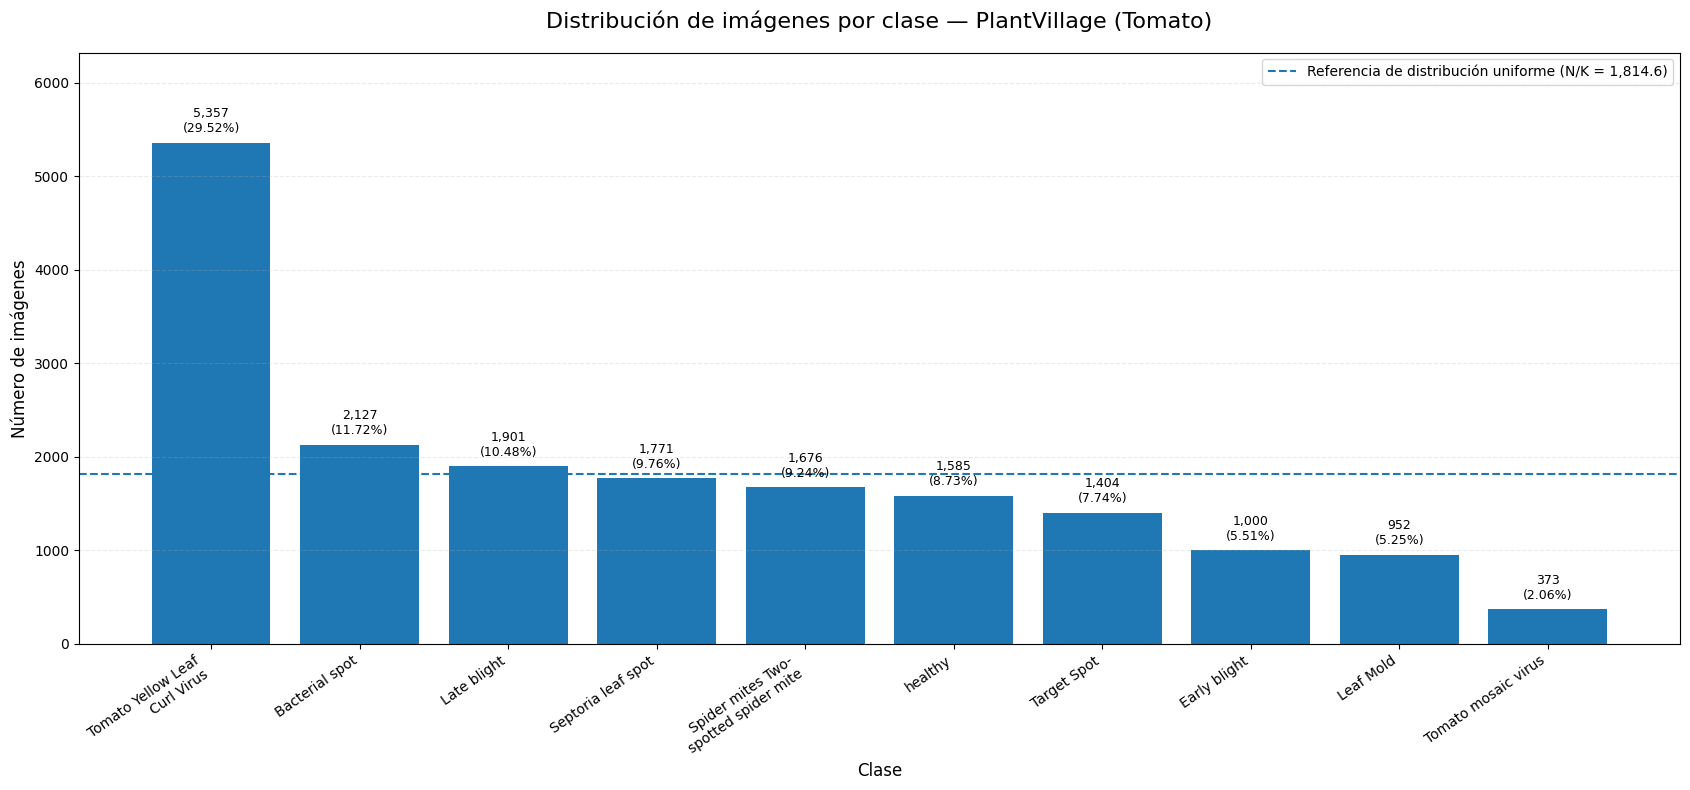


RESUMEN CUANTITATIVO
Total de imágenes       : 18,146
Número de clases        : 10
Referencia equilibrada  : 1,814.6 imágenes por clase
--------------------------------------------------------------------------------
Clase mayoritaria       : Tomato___Tomato_Yellow_Leaf_Curl_Virus
Cantidad                : 5,357
Participación           : 29.52%
--------------------------------------------------------------------------------
Clase minoritaria       : Tomato___Tomato_mosaic_virus
Cantidad                : 373
Participación           : 2.06%
--------------------------------------------------------------------------------
Imbalance Ratio (IR)    : 14.36


In [137]:
# ============================================================
# FASE 4 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# GRÁFICO 1 — DISTRIBUCIÓN DE IMÁGENES POR CLASE
# ============================================================

# ------------------------------------------------------------
# 1. LIBRERÍAS
# ------------------------------------------------------------

import matplotlib.pyplot as plt

from textwrap import fill
from IPython.display import display


# ============================================================
# 2. RECUPERAR LOS DATOS GENERADOS EN LA FASE 3
# ============================================================

# La Fase 3 del notebook ya construyó:
#
#   df_maestro
#   df_resumen_clases
#
# Por reproducibilidad y eficiencia evitamos volver a recorrer
# las carpetas de imágenes.
#
# Si df_resumen_clases está disponible, se reutiliza.
# Como respaldo, puede reconstruirse desde df_maestro.

if "df_resumen_clases" in globals():

    df_distribucion = (
        df_resumen_clases[
            [
                "clase",
                "Cantidad",
                "Participacion_%"
            ]
        ]
        .copy()
    )

elif "df_maestro" in globals():

    # Reconstrucción solamente si el resumen anterior
    # no estuviera disponible en memoria.
    df_distribucion = (
        df_maestro
        .groupby("clase")
        .size()
        .reset_index(
            name="Cantidad"
        )
    )

    total_temporal = (
        df_distribucion["Cantidad"]
        .sum()
    )

    df_distribucion[
        "Participacion_%"
    ] = (
        df_distribucion["Cantidad"]
        / total_temporal
        * 100
    )

else:

    raise NameError(
        "No se encontraron 'df_resumen_clases' ni "
        "'df_maestro'. Ejecute previamente la Fase 3."
    )


# ============================================================
# 3. ORDENAR LAS CLASES
# ============================================================

# Para facilitar la interpretación del desbalance,
# las clases se ordenan desde la de mayor frecuencia
# hasta la de menor frecuencia.

df_distribucion = (
    df_distribucion
    .sort_values(
        by="Cantidad",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 4. CALCULAR INDICADORES DE DISTRIBUCIÓN
# ============================================================

# Número total de imágenes
N = int(
    df_distribucion[
        "Cantidad"
    ].sum()
)


# Número de clases
K = int(
    df_distribucion.shape[0]
)


# Cantidad teórica por clase si existiera
# una distribución completamente uniforme
cantidad_equilibrada = (
    N / K
)


# ------------------------------------------------------------
# Clase mayoritaria
# ------------------------------------------------------------

fila_mayoritaria = (
    df_distribucion.iloc[0]
)

clase_mayoritaria = (
    fila_mayoritaria["clase"]
)

cantidad_mayoritaria = int(
    fila_mayoritaria["Cantidad"]
)

porcentaje_mayoritaria = float(
    fila_mayoritaria["Participacion_%"]
)


# ------------------------------------------------------------
# Clase minoritaria
# ------------------------------------------------------------

fila_minoritaria = (
    df_distribucion.iloc[-1]
)

clase_minoritaria = (
    fila_minoritaria["clase"]
)

cantidad_minoritaria = int(
    fila_minoritaria["Cantidad"]
)

porcentaje_minoritaria = float(
    fila_minoritaria["Participacion_%"]
)


# ------------------------------------------------------------
# Razón de desbalance
#
#             n_max
#     IR = -----------
#             n_min
# ------------------------------------------------------------

imbalance_ratio = (
    cantidad_mayoritaria
    / cantidad_minoritaria
)


# ============================================================
# 5. CONTROL DE CONSISTENCIA
# ============================================================

# Si df_maestro continúa disponible en memoria,
# se comprueba que ambas estructuras representen
# exactamente las mismas observaciones.

if "df_maestro" in globals():

    assert N == len(df_maestro), (
        "El total del resumen por clase no coincide "
        "con el número de filas de df_maestro."
    )


assert K == df_distribucion["clase"].nunique(), (
    "Existe una inconsistencia en el número de clases."
)


# ============================================================
# 6. CREAR ETIQUETAS MÁS LEGIBLES PARA EL GRÁFICO
# ============================================================

def formatear_clase(nombre_clase):
    """
    Convierte los nombres originales de PlantVillage
    en etiquetas más legibles para visualización.

    Ejemplo
    -------
    Tomato___Early_blight
        ->
    Early blight

    Los nombres originales permanecen intactos
    dentro del DataFrame.
    """

    etiqueta = (
        nombre_clase
        .replace(
            "Tomato___",
            ""
        )
        .replace(
            "_",
            " "
        )
    )

    # Divide nombres demasiado largos en varias líneas
    # para evitar solapamiento en el eje X.
    return fill(
        etiqueta,
        width=19
    )


df_distribucion[
    "Etiqueta_grafico"
] = (
    df_distribucion[
        "clase"
    ]
    .apply(
        formatear_clase
    )
)


# ============================================================
# 7. MOSTRAR TABLA UTILIZADA PARA EL GRÁFICO
# ============================================================

print("=" * 80)
print("FASE 4 — DISTRIBUCIÓN DE IMÁGENES POR CLASE")
print("=" * 80)

display(
    df_distribucion[
        [
            "clase",
            "Cantidad",
            "Participacion_%"
        ]
    ]
    .style
    .format(
        {
            "Cantidad": "{:,.0f}",
            "Participacion_%": "{:.2f}%"
        }
    )
)


# ============================================================
# 8. CONSTRUIR EL GRÁFICO DE BARRAS
# ============================================================

fig, ax = plt.subplots(
    figsize=(17, 8)
)


# ------------------------------------------------------------
# Barras
# ------------------------------------------------------------

barras = ax.bar(
    df_distribucion[
        "Etiqueta_grafico"
    ],
    df_distribucion[
        "Cantidad"
    ]
)


# ============================================================
# 9. AGREGAR CANTIDAD Y PORCENTAJE SOBRE CADA BARRA
# ============================================================

max_cantidad = (
    df_distribucion[
        "Cantidad"
    ].max()
)


for barra, cantidad, porcentaje in zip(

    barras,

    df_distribucion[
        "Cantidad"
    ],

    df_distribucion[
        "Participacion_%"
    ]
):

    ax.text(

        # Centro horizontal de cada barra
        barra.get_x()
        + barra.get_width() / 2,

        # Posición ligeramente superior a la barra
        barra.get_height()
        + max_cantidad * 0.015,

        # Información mostrada
        f"{cantidad:,.0f}\n({porcentaje:.2f}%)",

        ha="center",
        va="bottom",
        fontsize=9
    )


# ============================================================
# 10. LÍNEA DE REFERENCIA DE DISTRIBUCIÓN EQUILIBRADA
# ============================================================

ax.axhline(
    y=cantidad_equilibrada,
    linestyle="--",
    linewidth=1.5,
    label=(
        "Referencia de distribución uniforme "
        f"(N/K = {cantidad_equilibrada:,.1f})"
    )
)


# ============================================================
# 11. CONFIGURACIÓN DEL GRÁFICO
# ============================================================

ax.set_title(
    "Distribución de imágenes por clase — PlantVillage (Tomato)",
    fontsize=16,
    pad=18
)

ax.set_xlabel(
    "Clase",
    fontsize=12
)

ax.set_ylabel(
    "Número de imágenes",
    fontsize=12
)


# Rotación de las etiquetas para facilitar lectura
plt.setp(
    ax.get_xticklabels(),
    rotation=35,
    ha="right"
)


# Cuadrícula solamente en el eje vertical
# para facilitar la comparación de magnitudes.
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)


# Dar espacio superior para las anotaciones
ax.set_ylim(
    0,
    max_cantidad * 1.18
)


ax.legend(
    loc="upper right"
)


# Optimizar automáticamente márgenes
plt.tight_layout()


# Mostrar gráfico
plt.show()


# ============================================================
# 12. RESUMEN CUANTITATIVO DEL DESBALANCE
# ============================================================

print("\n" + "=" * 80)
print("RESUMEN CUANTITATIVO")
print("=" * 80)

print(
    f"Total de imágenes       : {N:,}"
)

print(
    f"Número de clases        : {K}"
)

print(
    f"Referencia equilibrada  : {cantidad_equilibrada:,.1f} "
    "imágenes por clase"
)

print("-" * 80)

print(
    f"Clase mayoritaria       : {clase_mayoritaria}"
)

print(
    f"Cantidad                : {cantidad_mayoritaria:,}"
)

print(
    f"Participación           : {porcentaje_mayoritaria:.2f}%"
)

print("-" * 80)

print(
    f"Clase minoritaria       : {clase_minoritaria}"
)

print(
    f"Cantidad                : {cantidad_minoritaria:,}"
)

print(
    f"Participación           : {porcentaje_minoritaria:.2f}%"
)

print("-" * 80)

print(
    f"Imbalance Ratio (IR)    : {imbalance_ratio:.2f}"
)

print("=" * 80)

### Interpretación del Gráfico 1 — Distribución por clase

El gráfico evidencia que las **18.146 imágenes** del conjunto de datos depurado no se encuentran distribuidas uniformemente entre las diez categorías.

La clase con mayor representación corresponde a:

`Tomato___Tomato_Yellow_Leaf_Curl_Virus`

con:

$$
n_{\max}=5\,357
$$

imágenes, equivalentes aproximadamente al:

$$
29.52\%
$$

del conjunto de datos.

En contraste, la clase con menor número de observaciones es:

`Tomato___Tomato_mosaic_virus`

con:

$$
n_{\min}=373
$$

imágenes, correspondientes aproximadamente al:

$$
2.06\%
$$

del dataset.

La razón entre la clase mayoritaria y la minoritaria es:

$$
IR
=
\frac{5\,357}{373}
\approx
14.36
$$

Por tanto, la categoría con mayor representación posee aproximadamente **14.36 veces más imágenes** que la categoría con menor representación.

Si las observaciones estuvieran distribuidas uniformemente entre las diez clases, cada categoría tendría teóricamente:

$$
n_{\mathrm{eq}}
=
\frac{18\,146}{10}
=
1\,814.6
$$

imágenes.

El gráfico muestra que varias categorías se encuentran considerablemente por encima o por debajo de esta referencia. En particular, `Tomato___Tomato_Yellow_Leaf_Curl_Virus` presenta una representación claramente superior al resto, mientras que `Tomato___Tomato_mosaic_virus` posee una cantidad mucho menor de observaciones.

En consecuencia, se concluye que el dataset presenta **desbalance entre clases**. Esta característica deberá considerarse en las siguientes fases del proyecto, especialmente al realizar la división estratificada de **Train / Validation / Test** y al seleccionar las métricas de evaluación.

Debido a este desbalance, la **accuracy global no debería utilizarse como única medida de rendimiento**, ya que un modelo podría obtener un resultado aparentemente favorable al predecir mejor las clases con mayor representación. Posteriormente será conveniente complementar la evaluación con métricas como:

- Balanced Accuracy.
- Precision Macro.
- Recall Macro.
- F1-score Macro.
- Matriz de confusión.

Este análisis no implica todavía modificar la distribución de los datos. Su objetivo en esta fase es **diagnosticar y documentar el desbalance antes de tomar decisiones de preprocesamiento o entrenamiento**.

## Gráfico 2 - Ejemplos aleatorios
Mostrar una muestra representativa de imágenes con su clase correspondiente.

### 4.2 Gráfico 2 — Ejemplos aleatorios de imágenes

Después de analizar la distribución cuantitativa de las clases, se realiza una inspección visual del conjunto de datos mediante una **muestra aleatoria de imágenes**.

El objetivo de esta etapa es observar directamente las características visuales presentes en PlantVillage y comprobar si el conjunto depurado presenta condiciones adecuadas para el posterior entrenamiento de los modelos MLP y CNN.

Sea el conjunto de datos limpio:

$$
\mathcal{D}
=
\left\{
(X_i,y_i)
\right\}_{i=1}^{N}
$$

donde:

- $X_i$ corresponde a la imagen $i$;
- $y_i$ corresponde a la clase asociada a esa imagen;
- $N$ corresponde al número total de imágenes válidas y únicas.

En el dataset actualmente procesado:

$$
N = 18\,146
$$

y existen:

$$
K = 10
$$

clases.

Para realizar la inspección visual se selecciona una muestra aleatoria sin reemplazo:

$$
\mathcal{S}
\subset
\mathcal{D}
$$

tal que:

$$
|\mathcal{S}| = m
$$

donde $m$ representa el número de imágenes que serán mostradas.

La selección se realiza **sin reemplazo**, por lo que una misma imagen no puede aparecer dos veces dentro de la muestra:

$$
X_i \neq X_j
\qquad
\forall i \neq j
$$

Se utiliza una semilla fija:

$$
SEED = 42
$$

para que la selección sea reproducible. Esto significa que, mientras el dataset no cambie, volver a ejecutar la celda producirá la misma muestra de imágenes.

### Objetivos de la inspección visual

La muestra permitirá observar preliminarmente:

- diferencias de color entre hojas;
- presencia de manchas, lesiones y cambios de textura;
- distribución espacial de los síntomas;
- variaciones de iluminación;
- orientación y tamaño aparente de las hojas;
- homogeneidad de los fondos;
- similitud visual entre algunas enfermedades;
- posibles anomalías que no hayan sido detectadas durante la auditoría automática.

Esta visualización constituye un análisis exploratorio cualitativo. Por tanto, **no se utilizará todavía para modificar, normalizar o aumentar artificialmente las imágenes**.

In [138]:
# ============================================================
# FASE 4 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# GRÁFICO 2 — EJEMPLOS ALEATORIOS DE IMÁGENES
# ============================================================

# ------------------------------------------------------------
# 1. LIBRERÍAS NECESARIAS
# ------------------------------------------------------------

from pathlib import Path
import math

import matplotlib.pyplot as plt
import pandas as pd

from PIL import Image
from textwrap import fill


# ============================================================
# 2. CONFIGURACIÓN GENERAL
# ============================================================

# Utilizamos la misma semilla definida previamente en el proyecto.
# Si la variable SEED todavía no estuviera disponible en memoria,
# se establece 42 como valor de respaldo.

SEED_EDA = SEED if "SEED" in globals() else 42


# Número de imágenes que se mostrarán.
#
# 12 imágenes permiten utilizar una cuadrícula 3 x 4,
# suficientemente grande para observar diversidad visual
# sin sobrecargar la salida del notebook.

N_MUESTRA = 12


# Número de columnas del gráfico.
N_COLUMNAS = 4


# ============================================================
# 3. VERIFICAR QUE EL DATAFRAME MAESTRO EXISTA
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró 'df_maestro'. "
        "Ejecute previamente la Fase 3 del proyecto."
    )


# ============================================================
# 4. VERIFICAR LAS COLUMNAS NECESARIAS
# ============================================================

columnas_requeridas = {
    "ruta",
    "clase"
}

columnas_faltantes = (
    columnas_requeridas
    - set(df_maestro.columns)
)

if columnas_faltantes:

    raise KeyError(
        "Faltan las siguientes columnas necesarias "
        f"en df_maestro: {sorted(columnas_faltantes)}"
    )


# ============================================================
# 5. PREPARAR EL DATAFRAME PARA EL MUESTREO
# ============================================================

# Trabajamos solamente con las columnas necesarias para esta
# visualización.
#
# No modificamos df_maestro: generamos una copia independiente.

df_eda_imagenes = (
    df_maestro[
        [
            "ruta",
            "clase"
        ]
    ]
    .copy()
)


# ============================================================
# 6. VERIFICAR QUE LAS RUTAS EXISTAN
# ============================================================

# Aunque las imágenes ya fueron verificadas anteriormente,
# este control protege la celda frente a posibles cambios
# accidentales de rutas entre ejecuciones.

df_eda_imagenes[
    "ruta_existe"
] = (
    df_eda_imagenes[
        "ruta"
    ]
    .apply(
        lambda ruta: Path(ruta).is_file()
    )
)


# Contar imágenes cuyas rutas siguen disponibles.
n_rutas_validas = int(
    df_eda_imagenes[
        "ruta_existe"
    ].sum()
)

n_rutas_no_disponibles = int(
    (~df_eda_imagenes["ruta_existe"]).sum()
)


print("=" * 80)
print("FASE 4 — GRÁFICO 2: EJEMPLOS ALEATORIOS")
print("=" * 80)

print(
    f"Imágenes registradas en df_maestro : "
    f"{len(df_eda_imagenes):,}"
)

print(
    f"Rutas disponibles                  : "
    f"{n_rutas_validas:,}"
)

print(
    f"Rutas no disponibles               : "
    f"{n_rutas_no_disponibles:,}"
)


# Mantener únicamente imágenes disponibles.
df_eda_validas = (
    df_eda_imagenes[
        df_eda_imagenes[
            "ruta_existe"
        ]
    ]
    .drop(
        columns="ruta_existe"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 7. VERIFICAR QUE LA MUESTRA SEA POSIBLE
# ============================================================

if len(df_eda_validas) < N_MUESTRA:

    raise ValueError(
        f"Se solicitaron {N_MUESTRA} imágenes, "
        f"pero solamente existen {len(df_eda_validas)} "
        "rutas válidas."
    )


# ============================================================
# 8. EXTRAER UNA MUESTRA ALEATORIA REPRODUCIBLE
# ============================================================

# sample() realiza selección aleatoria sin reemplazo.
#
# random_state garantiza que el resultado pueda reproducirse
# al volver a ejecutar el notebook.

df_muestra_aleatoria = (
    df_eda_validas
    .sample(
        n=N_MUESTRA,
        replace=False,
        random_state=SEED_EDA
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 9. FUNCIÓN PARA HACER MÁS LEGIBLES LAS ETIQUETAS
# ============================================================

def formatear_nombre_clase(nombre_clase):
    """
    Convierte el nombre original de PlantVillage en una
    etiqueta más legible para el gráfico.

    Ejemplo:
    Tomato___Early_blight
        ->
    Early blight

    El valor original no se modifica en df_maestro.
    """

    nombre = (
        str(nombre_clase)
        .replace(
            "Tomato___",
            ""
        )
        .replace(
            "_",
            " "
        )
    )

    # Separar nombres largos en varias líneas.
    return fill(
        nombre,
        width=23
    )


# ============================================================
# 10. CALCULAR LA CUADRÍCULA DEL GRÁFICO
# ============================================================

N_FILAS = math.ceil(
    N_MUESTRA
    / N_COLUMNAS
)


# ============================================================
# 11. CREAR LA FIGURA
# ============================================================

fig, axes = plt.subplots(
    nrows=N_FILAS,
    ncols=N_COLUMNAS,
    figsize=(
        16,
        4.2 * N_FILAS
    )
)


# Convertimos axes a vector para facilitar el recorrido,
# independientemente del número de filas y columnas.

axes = axes.flatten()


# ============================================================
# 12. CARGAR Y MOSTRAR CADA IMAGEN
# ============================================================

for indice, fila in df_muestra_aleatoria.iterrows():

    ax = axes[indice]

    ruta_imagen = Path(
        fila["ruta"]
    )

    clase_original = (
        fila["clase"]
    )

    # --------------------------------------------------------
    # Abrir la imagen
    # --------------------------------------------------------
    #
    # Se utiliza un gestor de contexto "with" para asegurar
    # que el archivo sea cerrado correctamente después de leerlo.
    #
    # convert("RGB") homogeneiza la representación únicamente
    # para mostrarla con Matplotlib.
    #
    # No se realiza resize, normalización ni augmentation.

    with Image.open(
        ruta_imagen
    ) as imagen:

        imagen_rgb = (
            imagen
            .convert("RGB")
            .copy()
        )


    # --------------------------------------------------------
    # Mostrar imagen
    # --------------------------------------------------------

    ax.imshow(
        imagen_rgb
    )


    # --------------------------------------------------------
    # Etiqueta de clase
    # --------------------------------------------------------

    etiqueta = (
        formatear_nombre_clase(
            clase_original
        )
    )

    ax.set_title(
        etiqueta,
        fontsize=10,
        pad=8
    )


    # Los ejes numéricos no aportan información en una
    # inspección visual de imágenes.
    ax.axis("off")


# ============================================================
# 13. OCULTAR POSICIONES VACÍAS DE LA CUADRÍCULA
# ============================================================

# Este bloque permite cambiar N_MUESTRA libremente sin dejar
# ejes vacíos visibles si el número no es múltiplo de columnas.

for indice in range(
    N_MUESTRA,
    len(axes)
):

    axes[indice].axis(
        "off"
    )


# ============================================================
# 14. TÍTULO GENERAL
# ============================================================

fig.suptitle(
    (
        "Ejemplos aleatorios del dataset PlantVillage "
        "— Clases de tomate"
    ),
    fontsize=17,
    y=1.02
)


# Ajustar espacios entre imágenes.
plt.tight_layout()


# Mostrar gráfico.
plt.show()


# ============================================================
# 15. RESUMEN DE LA MUESTRA VISUALIZADA
# ============================================================

print("\n" + "=" * 80)
print("RESUMEN DE LA MUESTRA")
print("=" * 80)

print(
    f"Semilla utilizada        : {SEED_EDA}"
)

print(
    f"Imágenes seleccionadas   : {N_MUESTRA}"
)

print(
    f"Clases representadas     : "
    f"{df_muestra_aleatoria['clase'].nunique()}"
)

print("\nDistribución de clases dentro de la muestra:")

display(
    df_muestra_aleatoria[
        "clase"
    ]
    .value_counts()
    .rename_axis(
        "Clase"
    )
    .reset_index(
        name="Cantidad"
    )
)

print("=" * 80)

Output hidden; open in https://colab.research.google.com to view.

### Interpretación del Gráfico 2 — Ejemplos aleatorios

La inspección de una muestra aleatoria permite complementar el análisis cuantitativo realizado previamente con una evaluación cualitativa de las imágenes.

La selección fue realizada sin reemplazo y utilizando:

$$
SEED = 42
$$

por lo que la muestra puede reproducirse mientras se mantenga sin modificaciones el conjunto de datos.

Cada observación del problema puede representarse mediante:

$$
(X_i,y_i)
$$

donde $X_i$ corresponde a la información visual contenida en la imagen y $y_i$ representa la enfermedad o estado sanitario asociado.

Esta inspección permite estudiar características que no están explícitamente representadas como variables tabulares, entre ellas:

- coloración de las hojas;
- manchas y lesiones;
- patrones de textura;
- bordes y formas;
- distribución espacial de los síntomas;
- orientación de la hoja;
- iluminación;
- características del fondo.

Estas propiedades resultan relevantes para la hipótesis central del proyecto porque la clasificación depende de información espacial distribuida sobre la superficie de la imagen.

Una MLP utilizará posteriormente una representación vectorizada de estos píxeles:

$$
X
\in
\mathbb{R}^{H\times W\times C}
\longrightarrow
x
\in
\mathbb{R}^{HWC}
$$

mientras que una CNN conservará inicialmente la estructura:

$$
X
\in
\mathbb{R}^{H\times W\times C}
$$

permitiendo aprender patrones locales relacionados con bordes, texturas, manchas y otras características visuales.

Por tanto, la inspección visual de ejemplos aleatorios aporta evidencia preliminar de que la información relevante para la clasificación no está contenida solamente en valores individuales de píxeles, sino también en **sus relaciones espaciales**.

En esta etapa el análisis tiene carácter exploratorio. Las conclusiones sobre similitud entre clases y variabilidad dentro de cada categoría serán estudiadas con mayor detalle en el siguiente gráfico, donde se mostrarán múltiples ejemplos organizados explícitamente por clase.

## Gráfico 3 - Ejemplos por clase
Mostrar varias imágenes por categoría para observar variabilidad intra-clase y similitud inter-clase.

## 4.3 Gráfico 3 — Ejemplos por clase

Después de analizar la distribución cuantitativa de las categorías y observar una muestra aleatoria global, se realiza una inspección visual **controlada por clase**.

El objetivo de esta visualización es mostrar varias imágenes pertenecientes a cada categoría para estudiar dos propiedades importantes del conjunto de datos:

- **Variabilidad intra-clase:** grado de diversidad visual existente entre imágenes que poseen la misma etiqueta.
- **Similitud inter-clase:** grado de parecido visual que puede existir entre imágenes pertenecientes a categorías diferentes.

El conjunto de datos limpio puede representarse como:

$$
\mathcal{D}
=
\left\{
(X_i,y_i)
\right\}_{i=1}^{N}
$$

donde:

$$
N = 18\,146
$$

representa el número total de imágenes válidas y únicas, y:

$$
K = 10
$$

corresponde al número de clases.

Para cada clase:

$$
c_k \in \mathcal{C},
\qquad
k=1,\ldots,K
$$

se define el subconjunto:

$$
\mathcal{D}_k
=
\left\{
(X_i,y_i)\in\mathcal{D}
:
y_i=c_k
\right\}
$$

que contiene todas las imágenes asociadas a la categoría $c_k$.

A diferencia del muestreo aleatorio global utilizado anteriormente, en esta visualización se selecciona el **mismo número de imágenes para cada clase**.

Sea:

$$
m = 3
$$

el número de imágenes seleccionadas por categoría. Para cada clase se obtiene entonces una muestra:

$$
\mathcal{S}_k
\subset
\mathcal{D}_k
$$

tal que:

$$
|\mathcal{S}_k|=m
$$

La muestra visual completa estará formada por:

$$
\mathcal{S}
=
\bigcup_{k=1}^{K}\mathcal{S}_k
$$

y el número total de imágenes visualizadas será:

$$
|\mathcal{S}|
=
K\cdot m
$$

Por tanto:

$$
|\mathcal{S}|
=
10\cdot3
=
30
$$

imágenes.

La selección dentro de cada categoría se realiza **sin reemplazo**, por lo que una misma imagen no puede aparecer repetida dentro de una clase:

$$
X_i \neq X_j,
\qquad
\forall i\neq j
$$

Además, se utiliza una semilla fija:

$$
SEED=42
$$

para garantizar la reproducibilidad de la selección.

### Variabilidad intra-clase

Para una determinada categoría $c_k$, interesa estudiar visualmente la diversidad existente entre:

$$
X_i,\;X_j\in\mathcal{D}_k
$$

aunque ambas observaciones compartan:

$$
y_i=y_j=c_k
$$

Las diferencias pueden encontrarse en características como color, textura, extensión de las lesiones, orientación de la hoja, iluminación o distribución espacial de los síntomas.

### Similitud inter-clase

También interesa comparar imágenes correspondientes a clases diferentes:

$$
X_i\in\mathcal{D}_a,
\qquad
X_j\in\mathcal{D}_b,
\qquad
a\neq b
$$

para determinar si existen patrones visuales similares capaces de dificultar posteriormente la clasificación.

Esta inspección resulta especialmente relevante para la comparación experimental entre MLP y CNN, debido a que las CNN pueden aprender relaciones espaciales locales mediante operaciones de convolución, mientras que la MLP trabajará posteriormente con una representación vectorizada de la imagen.

En esta etapa las imágenes se muestran **sin normalización, redimensionamiento para entrenamiento ni data augmentation**, ya que el objetivo es inspeccionar el contenido visual original del dataset depurado.

FASE 4 — GRÁFICO 3: EJEMPLOS POR CLASE
Imágenes registradas en df_maestro : 18,146
Rutas disponibles                  : 18,146
Rutas no disponibles               : 0
Número de clases                    : 10
Imágenes por clase                  : 3
Total de imágenes visualizadas      : 30


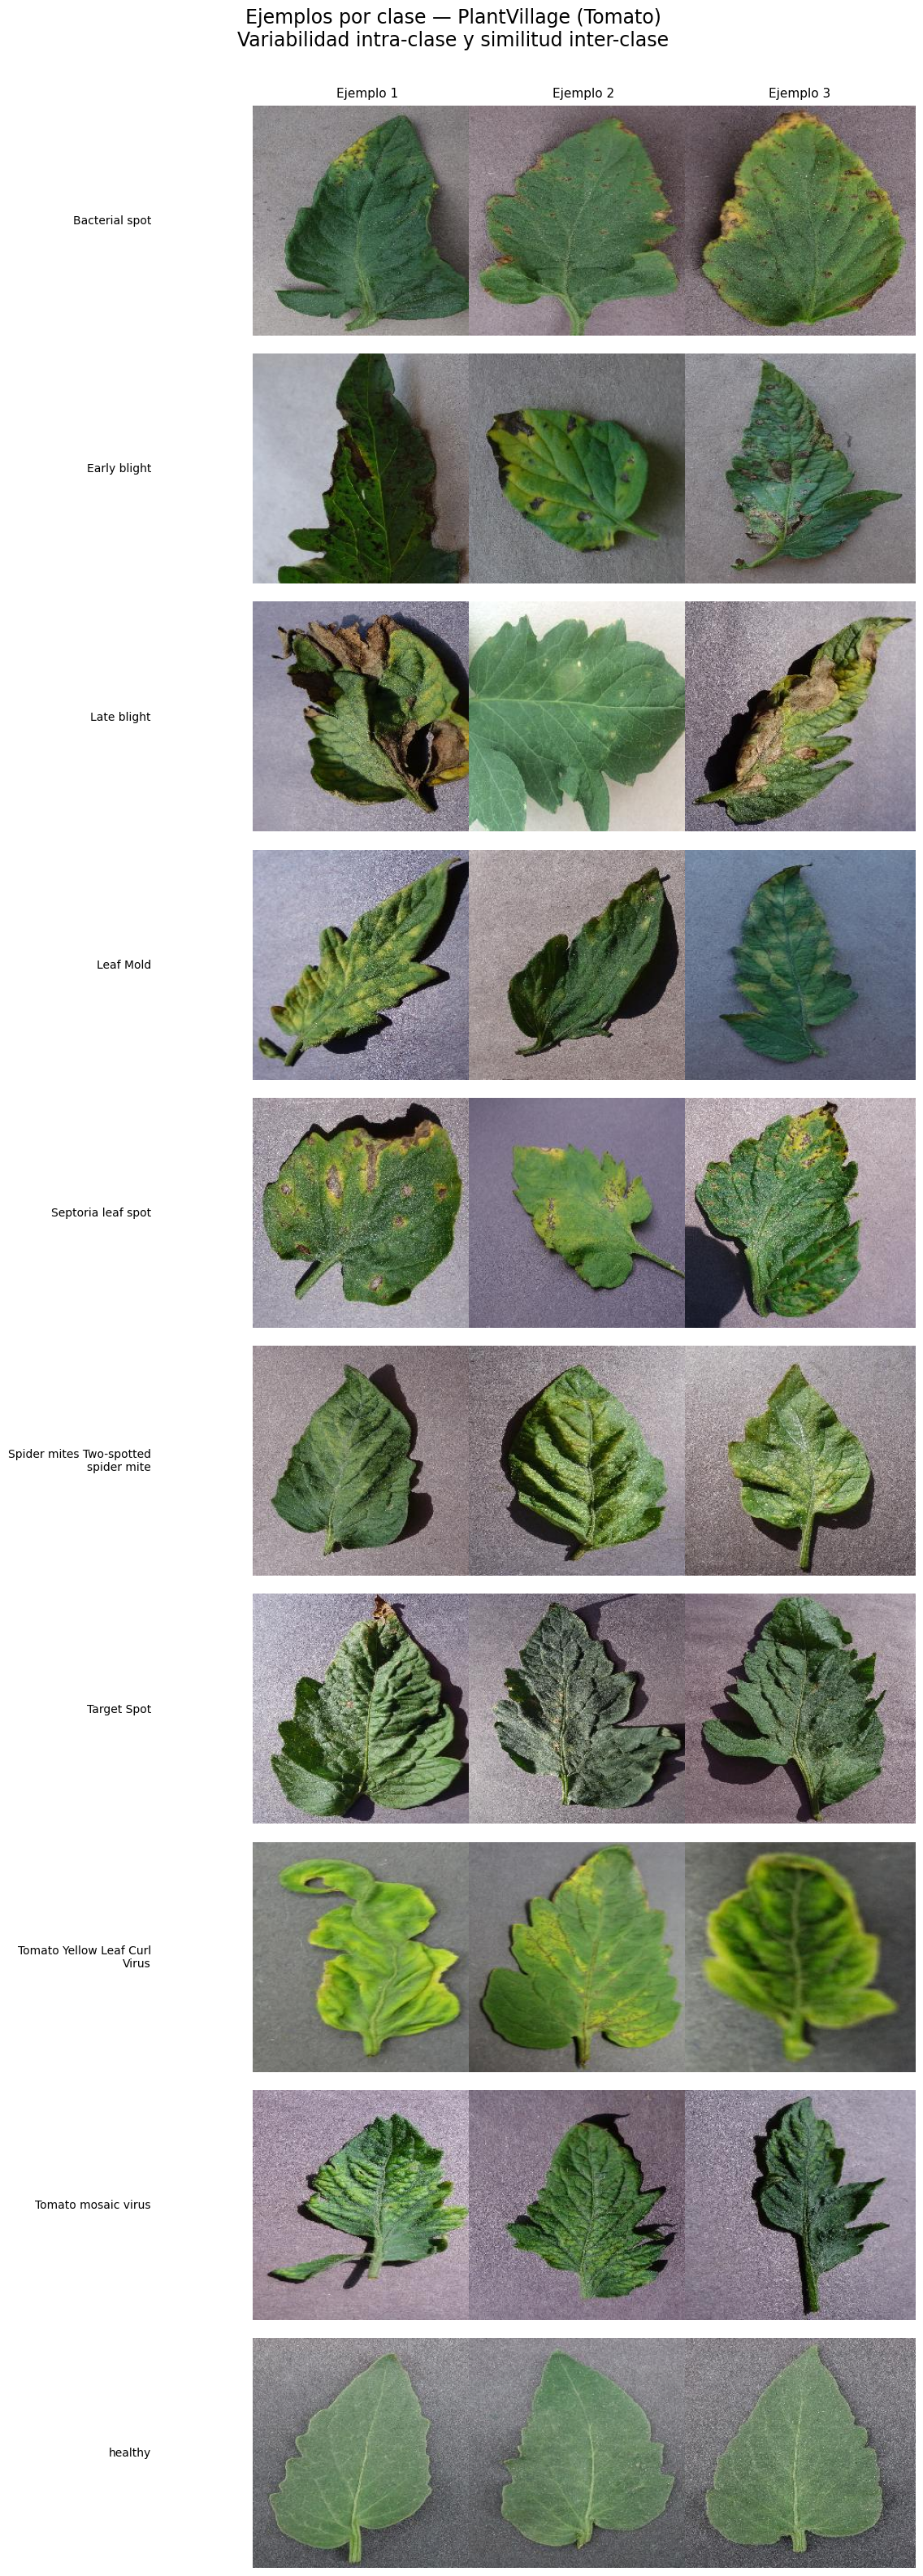


RESUMEN DEL GRÁFICO 3
Semilla utilizada       : 42
Número de clases        : 10
Imágenes por clase      : 3
Total visualizado       : 30
Rutas duplicadas        : 0


In [139]:
# ============================================================
# FASE 4 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# GRÁFICO 3 — EJEMPLOS POR CLASE
# ============================================================

# ------------------------------------------------------------
# OBJETIVO
# ------------------------------------------------------------
#
# Mostrar varias imágenes de CADA categoría del dataset
# para estudiar:
#
#   1. Variabilidad intra-clase:
#      diferencias visuales entre imágenes de la misma clase.
#
#   2. Similitud inter-clase:
#      semejanzas visuales entre categorías diferentes.
#
# La visualización reutiliza directamente df_maestro,
# construido previamente en la Fase 3.
# ------------------------------------------------------------


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
from textwrap import fill


# ============================================================
# 2. CONFIGURACIÓN REPRODUCIBLE
# ============================================================

# Utilizar la semilla general del proyecto si ya existe.
# Si no existe, utilizar 42 como respaldo.

SEED_EDA = (
    SEED
    if "SEED" in globals()
    else 42
)


# ------------------------------------------------------------
# Número de imágenes que se mostrarán por clase
# ------------------------------------------------------------

IMAGENES_POR_CLASE = 3


# ============================================================
# 3. VERIFICAR LA EXISTENCIA DEL DATAFRAME MAESTRO
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró el DataFrame 'df_maestro'. "
        "Ejecute previamente la Fase 3 del proyecto."
    )


# ============================================================
# 4. VERIFICAR COLUMNAS NECESARIAS
# ============================================================

columnas_requeridas = {
    "ruta",
    "clase"
}


columnas_faltantes = (
    columnas_requeridas
    -
    set(df_maestro.columns)
)


if columnas_faltantes:

    raise KeyError(
        "Faltan columnas necesarias en df_maestro: "
        f"{sorted(columnas_faltantes)}"
    )


# ============================================================
# 5. PREPARAR LOS DATOS PARA EL EDA
# ============================================================

# Crear una copia independiente.
#
# De esta forma no se modifica df_maestro,
# que continuará siendo la referencia principal
# del dataset limpio.

df_eda_clases = (

    df_maestro[
        [
            "ruta",
            "clase"
        ]
    ]

    .copy()
)


# ============================================================
# 6. VERIFICAR EXISTENCIA DE LOS ARCHIVOS
# ============================================================

# La integridad del dataset ya fue auditada previamente.
#
# Sin embargo, comprobamos nuevamente que las rutas sigan
# disponibles para evitar errores si la sesión de Colab
# hubiese sido modificada después de la Fase 3.

df_eda_clases[
    "ruta_existe"
] = (

    df_eda_clases[
        "ruta"
    ]

    .apply(
        lambda ruta:
        Path(ruta).is_file()
    )
)


# ------------------------------------------------------------
# Número de rutas disponibles
# ------------------------------------------------------------

n_rutas_validas = int(
    df_eda_clases[
        "ruta_existe"
    ].sum()
)


n_rutas_no_disponibles = int(
    (
        ~df_eda_clases[
            "ruta_existe"
        ]
    ).sum()
)


print("=" * 80)
print("FASE 4 — GRÁFICO 3: EJEMPLOS POR CLASE")
print("=" * 80)

print(
    f"Imágenes registradas en df_maestro : "
    f"{len(df_eda_clases):,}"
)

print(
    f"Rutas disponibles                  : "
    f"{n_rutas_validas:,}"
)

print(
    f"Rutas no disponibles               : "
    f"{n_rutas_no_disponibles:,}"
)


# ------------------------------------------------------------
# Mantener solamente rutas existentes
# ------------------------------------------------------------

df_eda_clases = (

    df_eda_clases[
        df_eda_clases[
            "ruta_existe"
        ]
    ]

    .drop(
        columns="ruta_existe"
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 7. IDENTIFICAR LAS CLASES
# ============================================================

# Se ordenan alfabéticamente para que el resultado sea
# estable y fácil de revisar entre distintas ejecuciones.

clases = sorted(
    df_eda_clases[
        "clase"
    ].unique()
)


N_CLASES = len(
    clases
)


print(
    f"Número de clases                    : "
    f"{N_CLASES}"
)


# ============================================================
# 8. VERIFICAR QUE CADA CLASE TENGA SUFICIENTES IMÁGENES
# ============================================================

conteo_clases = (

    df_eda_clases[
        "clase"
    ]

    .value_counts()
)


clases_insuficientes = (

    conteo_clases[
        conteo_clases
        <
        IMAGENES_POR_CLASE
    ]
)


if not clases_insuficientes.empty:

    raise ValueError(
        "Algunas clases no poseen suficientes imágenes "
        "para realizar el muestreo solicitado:\n"
        f"{clases_insuficientes}"
    )


# ============================================================
# 9. MUESTREO CONTROLADO POR CLASE
# ============================================================

# En lugar de realizar una muestra aleatoria global,
# seleccionamos exactamente el mismo número de imágenes
# de cada categoría.
#
# Esto evita que el desbalance del dataset determine qué
# clases aparecen en esta visualización.
#
# IMPORTANTE:
# El muestreo es solamente para el EDA.
# No constituye oversampling ni altera el dataset.

muestras_por_clase = []


for indice_clase, clase in enumerate(
    clases
):

    # --------------------------------------------------------
    # Obtener únicamente las imágenes de la clase actual
    # --------------------------------------------------------

    df_clase = (

        df_eda_clases[
            df_eda_clases[
                "clase"
            ]
            ==
            clase
        ]
    )


    # --------------------------------------------------------
    # Seleccionar imágenes sin reemplazo
    # --------------------------------------------------------
    #
    # Se utiliza una semilla reproducible diferente para
    # cada categoría:
    #
    # SEED + índice de clase
    #
    # Esto mantiene el experimento reproducible.

    muestra_clase = (

        df_clase

        .sample(
            n=IMAGENES_POR_CLASE,
            replace=False,
            random_state=(
                SEED_EDA
                +
                indice_clase
            )
        )

        .copy()
    )


    # Añadir un número interno para identificar
    # la posición visual dentro de la clase.

    muestra_clase[
        "ejemplo"
    ] = range(
        1,
        IMAGENES_POR_CLASE + 1
    )


    muestras_por_clase.append(
        muestra_clase
    )


# ------------------------------------------------------------
# Unificar todas las muestras
# ------------------------------------------------------------

df_muestra_por_clase = (

    pd.concat(
        muestras_por_clase,
        ignore_index=True
    )
)


# ============================================================
# 10. CONTROLES DE CONSISTENCIA
# ============================================================

N_ESPERADO = (
    N_CLASES
    *
    IMAGENES_POR_CLASE
)


assert (
    len(df_muestra_por_clase)
    ==
    N_ESPERADO
), (
    "La cantidad total de imágenes seleccionadas "
    "no coincide con la cantidad esperada."
)


# Comprobar que todas las categorías tengan exactamente
# el mismo número de imágenes.

conteo_muestra = (

    df_muestra_por_clase

    .groupby(
        "clase"
    )

    .size()
)


assert (
    conteo_muestra
    ==
    IMAGENES_POR_CLASE
).all(), (
    "No todas las clases poseen el mismo número "
    "de imágenes en la muestra."
)


# Verificar que no se repitan rutas.

assert (
    df_muestra_por_clase[
        "ruta"
    ].duplicated().sum()
    ==
    0
), (
    "Se detectaron imágenes repetidas dentro "
    "de la muestra visual."
)


print(
    f"Imágenes por clase                  : "
    f"{IMAGENES_POR_CLASE}"
)

print(
    f"Total de imágenes visualizadas      : "
    f"{len(df_muestra_por_clase)}"
)


# ============================================================
# 11. FUNCIÓN PARA FORMATEAR LOS NOMBRES DE CLASE
# ============================================================

def formatear_nombre_clase(
    nombre_clase
):
    """
    Convierte el nombre original de PlantVillage
    en una etiqueta más legible para el gráfico.

    Ejemplo
    -------
    Tomato___Early_blight
        ->
    Early blight

    El nombre original permanece intacto en df_maestro.
    """

    etiqueta = (

        str(nombre_clase)

        .replace(
            "Tomato___",
            ""
        )

        .replace(
            "_",
            " "
        )
    )


    # Dividir nombres extensos en varias líneas
    # para mantener una figura legible.

    return fill(
        etiqueta,
        width=28
    )


# ============================================================
# 12. CREAR LA CUADRÍCULA
# ============================================================

# Estructura:
#
#     filas    = número de clases
#     columnas = imágenes por clase
#
# En el dataset actual:
#
#     10 filas x 3 columnas = 30 imágenes

fig, axes = plt.subplots(

    nrows=N_CLASES,

    ncols=IMAGENES_POR_CLASE,

    figsize=(
        12,
        3.15 * N_CLASES
    )
)


# Si en alguna ejecución existiera una sola columna,
# aseguramos que axes mantenga estructura bidimensional.

if IMAGENES_POR_CLASE == 1:

    axes = axes.reshape(
        N_CLASES,
        1
    )


# ============================================================
# 13. MOSTRAR LAS IMÁGENES
# ============================================================

for fila_idx, clase in enumerate(
    clases
):

    # --------------------------------------------------------
    # Recuperar la muestra correspondiente a esta categoría
    # --------------------------------------------------------

    muestra_clase = (

        df_muestra_por_clase[
            df_muestra_por_clase[
                "clase"
            ]
            ==
            clase
        ]

        .sort_values(
            "ejemplo"
        )

        .reset_index(
            drop=True
        )
    )


    # Etiqueta legible de la categoría

    etiqueta_clase = (
        formatear_nombre_clase(
            clase
        )
    )


    # --------------------------------------------------------
    # Recorrer imágenes de la fila
    # --------------------------------------------------------

    for columna_idx, fila in (
        muestra_clase.iterrows()
    ):

        ax = axes[
            fila_idx,
            columna_idx
        ]


        ruta_imagen = Path(
            fila[
                "ruta"
            ]
        )


        # ----------------------------------------------------
        # Cargar imagen
        # ----------------------------------------------------
        #
        # Se muestra la imagen original.
        #
        # NO se aplica:
        # - resize para entrenamiento;
        # - normalización;
        # - data augmentation.
        #
        # La conversión RGB garantiza únicamente una
        # visualización homogénea con Matplotlib.

        with Image.open(
            ruta_imagen
        ) as imagen:

            imagen_rgb = (

                imagen
                .convert("RGB")
                .copy()
            )


        # ----------------------------------------------------
        # Mostrar imagen
        # ----------------------------------------------------

        ax.imshow(
            imagen_rgb
        )


        # ----------------------------------------------------
        # Título superior
        # ----------------------------------------------------

        if fila_idx == 0:

            ax.set_title(
                f"Ejemplo {columna_idx + 1}",
                fontsize=11,
                pad=8
            )


        # ----------------------------------------------------
        # Etiqueta de clase
        # ----------------------------------------------------
        #
        # Se muestra solamente en la primera columna
        # para evitar repetir el mismo nombre tres veces.

        if columna_idx == 0:

            ax.set_ylabel(

                etiqueta_clase,

                fontsize=10,

                rotation=0,

                ha="right",

                va="center",

                labelpad=90
            )


        # ----------------------------------------------------
        # Eliminar elementos gráficos innecesarios
        # ----------------------------------------------------

        ax.set_xticks(
            []
        )

        ax.set_yticks(
            []
        )


        for spine in ax.spines.values():

            spine.set_visible(
                False
            )


# ============================================================
# 14. TÍTULO GENERAL DEL GRÁFICO
# ============================================================

fig.suptitle(

    (
        "Ejemplos por clase — PlantVillage (Tomato)\n"
        "Variabilidad intra-clase y similitud inter-clase"
    ),

    fontsize=17,

    y=1.005
)


# ============================================================
# 15. AJUSTAR LA DISTRIBUCIÓN VISUAL
# ============================================================

plt.tight_layout(
    h_pad=1.6,
    w_pad=1.0
)


# Espacio adicional a la izquierda para
# las etiquetas de las clases.

plt.subplots_adjust(
    left=0.28
)


# ============================================================
# 16. MOSTRAR EL GRÁFICO
# ============================================================

plt.show()


# ============================================================
# 17. RESUMEN DEL MUESTREO
# ============================================================

print("\n" + "=" * 80)
print("RESUMEN DEL GRÁFICO 3")
print("=" * 80)

print(
    f"Semilla utilizada       : "
    f"{SEED_EDA}"
)

print(
    f"Número de clases        : "
    f"{N_CLASES}"
)

print(
    f"Imágenes por clase      : "
    f"{IMAGENES_POR_CLASE}"
)

print(
    f"Total visualizado       : "
    f"{len(df_muestra_por_clase)}"
)

print(
    f"Rutas duplicadas        : "
    f"{df_muestra_por_clase['ruta'].duplicated().sum()}"
)

print("=" * 80)

### 4.4 Preguntas de análisis del EDA visual

Una vez estudiada la distribución de las clases, una muestra aleatoria global y ejemplos organizados por categoría, es posible realizar un diagnóstico exploratorio del conjunto de datos antes de proceder a la partición **Train / Validation / Test**.

El análisis debe distinguir entre dos conceptos diferentes:

1. **Homogeneidad técnica**, relacionada con resolución, formato, canales e integridad de los archivos.
2. **Variabilidad visual**, relacionada con color, textura, forma, lesiones y distribución espacial de los síntomas.

Estas propiedades no son contradictorias. Un dataset puede ser técnicamente homogéneo y, al mismo tiempo, presentar suficiente diversidad visual para constituir un problema de clasificación no trivial.

---

#### 1. ¿Las imágenes son visualmente homogéneas?

**En términos técnicos, sí existe un alto grado de homogeneidad. Sin embargo, el contenido visual presenta una variabilidad relevante.**

Después de la depuración, el conjunto contiene:

$$
N = 18\,146
$$

imágenes válidas y únicas.

Todas las imágenes presentan:

$$
H = 256
$$

píxeles de alto,

$$
W = 256
$$

píxeles de ancho y:

$$
C = 3
$$

canales de color.

Por tanto, cada imagen posee la misma estructura:

$$
X_i
\in
\mathbb{R}^{256\times256\times3}
$$

Además:

$$
100\%
$$

de las imágenes utilizan formato **JPEG**, modo de color **RGB** y fueron verificadas satisfactoriamente durante la auditoría de integridad.

La homogeneidad estructural puede expresarse mediante:

$$
H_{\text{dim}}
=
\frac{N_{\text{dimensión modal}}}{N}
\times100
$$

En este dataset:

$$
H_{\text{dim}}
=
\frac{18\,146}{18\,146}
\times100
=
100\%
$$

De manera análoga:

$$
H_{\text{formato}}=100\%
$$

y:

$$
H_{\text{RGB}}=100\%
$$

Desde el punto de vista visual, los ejemplos muestran también condiciones de adquisición relativamente controladas: generalmente aparece una hoja como objeto principal y los fondos son visualmente simples.

Sin embargo, **las imágenes no son idénticas ni completamente uniformes en su apariencia**, lo cual es favorable para el aprendizaje. Se observan diferencias en:

- forma y orientación de las hojas;
- intensidad del color verde;
- amarillamiento;
- extensión y localización de lesiones;
- tamaño y distribución de manchas;
- textura;
- grado de deterioro;
- iluminación y tonalidad del fondo.

Por tanto, la conclusión más precisa es:

$$
\boxed{
\text{alta homogeneidad técnica}
+
\text{variabilidad visual útil}
}
$$

Esta combinación resulta apropiada para un problema supervisado de clasificación de imágenes.

---

#### 2. ¿Hay diferencias evidentes entre las enfermedades?

**Sí. La inspección visual muestra diferencias apreciables entre varias categorías, aunque no todas presentan una separación visual igualmente clara.**

Los ejemplos organizados por clase muestran que las enfermedades pueden diferenciarse mediante patrones relacionados con:

$$
\text{color}
+
\text{textura}
+
\text{manchas}
+
\text{necrosis}
+
\text{deformación}
+
\text{distribución espacial}
$$

Por ejemplo, en la muestra exploratoria:

- la clase `healthy` presenta hojas visualmente más uniformes y sin lesiones prominentes;
- `Tomato___Tomato_Yellow_Leaf_Curl_Virus` muestra alteraciones visibles de coloración y forma;
- `Tomato___Late_blight` presenta en varios ejemplos áreas extensas de deterioro o necrosis;
- `Tomato___Bacterial_spot` y `Tomato___Septoria_leaf_spot` presentan patrones de manchas distribuidas sobre la hoja;
- otras categorías presentan modificaciones más sutiles asociadas principalmente a textura, moteado o cambios de color.

Estas observaciones apoyan la hipótesis de que la variable objetivo depende de información visual estructurada.

Conceptualmente:

$$
X_i
\longrightarrow
\left\{
\text{bordes},
\text{colores},
\text{texturas},
\text{lesiones},
\text{formas}
\right\}
\longrightarrow
y_i
$$

Por tanto, existen diferencias visuales potencialmente aprendibles por una red neuronal.

No obstante, esta conclusión es **exploratoria**. La verdadera capacidad de separación entre categorías deberá verificarse posteriormente mediante el rendimiento de los modelos y la matriz de confusión.

---

#### 3. ¿Existen clases visualmente similares?

**Sí. El Gráfico 3 sugiere que algunas categorías comparten características visuales y podrían resultar más difíciles de separar.**

Entre los ejemplos observados aparecen similitudes potenciales entre enfermedades que presentan:

- manchas pequeñas o distribuidas;
- regiones amarillentas;
- cambios de textura;
- lesiones oscuras;
- patrones de deterioro que pueden superponerse parcialmente.

En particular, la inspección visual sugiere semejanzas entre algunos ejemplos de:

- `Tomato___Bacterial_spot` y `Tomato___Septoria_leaf_spot`;
- `Tomato___Early_blight` y `Tomato___Late_blight`;
- `Tomato___Spider_mites Two-spotted_spider_mite` y `Tomato___Target_Spot`.

Estas semejanzas deben considerarse **hipótesis visuales preliminares**, no como evidencia definitiva de confusión.

Posteriormente podrá comprobarse si una similitud observada durante el EDA se traduce realmente en errores del modelo:

$$
\text{similitud visual}
\;\not\Rightarrow\;
\text{confusión obligatoria}
$$

pero puede plantearse la hipótesis:

$$
\text{mayor similitud visual}
\longrightarrow
\text{mayor dificultad de separación}
$$

Esta relación deberá contrastarse posteriormente mediante:

$$
\text{Matriz de confusión}
+
\text{Recall por clase}
+
\text{F1 por clase}
$$

Por esta razón, el análisis visual realizado ahora será útil para interpretar los errores futuros de la MLP y la CNN.

---

#### 4. ¿Existe desbalance de clases?

**Sí. El dataset presenta un desbalance de clases claramente identificable y cuantificable.**

El conjunto contiene:

$$
N=18\,146
$$

imágenes distribuidas entre:

$$
K=10
$$

clases.

Si existiera una distribución perfectamente uniforme, cada clase tendría aproximadamente:

$$
n_{\text{eq}}
=
\frac{N}{K}
=
\frac{18\,146}{10}
=
1\,814.6
$$

imágenes.

Sin embargo, la clase mayoritaria es:

`Tomato___Tomato_Yellow_Leaf_Curl_Virus`

con:

$$
n_{\max}=5\,357
$$

imágenes, que representan:

$$
29.52\%
$$

del dataset.

La clase minoritaria es:

`Tomato___Tomato_mosaic_virus`

con:

$$
n_{\min}=373
$$

imágenes, equivalentes a:

$$
2.06\%
$$

del total.

La razón de desbalance es:

$$
IR
=
\frac{n_{\max}}{n_{\min}}
$$

por lo tanto:

$$
IR
=
\frac{5\,357}{373}
\approx
14.36
$$

Esto significa que la clase mayoritaria contiene aproximadamente:

$$
\boxed{14.36}
$$

veces más imágenes que la categoría minoritaria.

En consecuencia, el dataset debe considerarse **desbalanceado**.

Este resultado tendrá consecuencias metodológicas importantes:

1. la futura división **Train / Validation / Test** deberá ser estratificada;
2. la `accuracy` no deberá utilizarse como única métrica;
3. deberán analizarse métricas sensibles al rendimiento por clase, como:

$$
\text{Balanced Accuracy}
$$

$$
\text{Precision}_{macro}
$$

$$
\text{Recall}_{macro}
$$

$$
F1_{macro}
$$

además de la matriz de confusión.

En esta etapa, sin embargo, el desbalance solamente se **diagnostica y documenta**. La estrategia para tratarlo durante el entrenamiento deberá decidirse posteriormente y no debe confundirse con el EDA.

---

#### 5. ¿La calidad visual parece suficientemente consistente para entrenamiento?

**Sí. La evidencia disponible indica que la calidad técnica del dataset es suficientemente consistente para avanzar hacia el modelamiento.**

La auditoría realizada previamente produjo:

$$
N_{\text{válidas}}
=
18\,146
$$

y:

$$
N_{\text{problemáticas}}
=
0
$$

por lo que la tasa de integridad del dataset limpio es:

$$
Q
=
\frac{N_{\text{válidas}}}{N}
\times100
$$

$$
Q
=
\frac{18\,146}{18\,146}
\times100
=
100\%
$$

Además:

- todas las imágenes tienen resolución $256\times256$;
- todas poseen $3$ canales;
- todas utilizan modo RGB;
- todas corresponden al formato JPEG;
- no existen rutas ausentes en las visualizaciones de la Fase 4;
- después de apartar las copias redundantes quedan:

$$
N_{\text{duplicados restantes}}=0
$$

Por tanto, desde el punto de vista técnico:

$$
\boxed{
\text{integridad}
+
\text{resolución uniforme}
+
\text{color uniforme}
+
\text{ausencia de duplicados exactos}
}
$$

constituyen condiciones favorables para continuar con la preparación de los datos.

La inspección visual también muestra imágenes suficientemente claras para reconocer estructuras foliares y patrones de lesión.

No obstante, una calidad técnica elevada **no garantiza automáticamente una buena generalización**. Las imágenes parecen provenir de condiciones relativamente controladas, por lo que el rendimiento obtenido posteriormente sobre PlantVillage no necesariamente representará el comportamiento del modelo frente a fotografías tomadas en condiciones reales de terreno.

---

#### Síntesis del EDA

Los resultados de la Fase 4 pueden resumirse como:

| Pregunta | Diagnóstico |
|---|---|
| ¿Las imágenes son visualmente homogéneas? | Sí en estructura técnica; existe variabilidad visual útil |
| ¿Hay diferencias evidentes entre enfermedades? | Sí, aunque con diferente grado de separación visual |
| ¿Existen clases visualmente similares? | Sí, se observan posibles solapamientos visuales |
| ¿Existe desbalance de clases? | Sí, $IR\approx14.36$ |
| ¿La calidad parece suficiente para entrenamiento? | Sí, integridad técnica del $100\%$ |

En conjunto:

$$
\boxed{
\text{Dataset técnicamente consistente}
+
\text{problema visual no trivial}
+
\text{desbalance relevante}
}
$$

Por tanto, existe evidencia suficiente para avanzar a la siguiente etapa del pipeline, manteniendo especial atención sobre:

$$
\text{estratificación}
+
\text{métricas balanceadas}
+
\text{generalización}
$$

In [140]:
# ============================================================
# FASE 4 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# RESPALDO CUANTITATIVO DE LAS PREGUNTAS DE ANÁLISIS
# ============================================================

# ------------------------------------------------------------
# OBJETIVO
# ------------------------------------------------------------
#
# Resumir mediante indicadores reproducibles la evidencia
# cuantitativa utilizada para responder las preguntas finales
# del EDA:
#
#   1. Homogeneidad estructural.
#   2. Calidad e integridad.
#   3. Distribución de las clases.
#   4. Magnitud del desbalance.
#
# IMPORTANTE:
# Las preguntas relacionadas con similitud visual entre
# enfermedades continúan siendo una evaluación cualitativa
# basada en los Gráficos 2 y 3.
# ------------------------------------------------------------


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import pandas as pd

from IPython.display import display


# ============================================================
# 2. VERIFICAR EL DATAFRAME MAESTRO
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró 'df_maestro'. "
        "Ejecute previamente la Fase 3."
    )


# ------------------------------------------------------------
# Columnas utilizadas
# ------------------------------------------------------------

columnas_requeridas = {
    "clase",
    "formato",
    "modo",
    "ancho",
    "alto",
    "canales",
    "integridad",
    "sha256"
}


columnas_faltantes = (
    columnas_requeridas
    -
    set(df_maestro.columns)
)


if columnas_faltantes:

    raise KeyError(
        "Faltan columnas requeridas en df_maestro: "
        f"{sorted(columnas_faltantes)}"
    )


# ============================================================
# 3. DIMENSIONES GENERALES DEL DATASET
# ============================================================

N = int(
    len(df_maestro)
)


K = int(
    df_maestro[
        "clase"
    ].nunique()
)


# ============================================================
# 4. HOMOGENEIDAD DE LAS DIMENSIONES
# ============================================================

# Agrupar por combinación:
#
# ancho x alto x canales
#
# y determinar qué porcentaje pertenece a la estructura
# dimensional más frecuente.

distribucion_dimensiones = (

    df_maestro

    .groupby(
        [
            "ancho",
            "alto",
            "canales"
        ]
    )

    .size()

    .sort_values(
        ascending=False
    )
)


n_dimension_modal = int(
    distribucion_dimensiones.iloc[0]
)


homogeneidad_dimensiones = (
    n_dimension_modal
    / N
    * 100
)


# ============================================================
# 5. HOMOGENEIDAD DEL FORMATO
# ============================================================

distribucion_formatos = (

    df_maestro[
        "formato"
    ]

    .value_counts()
)


n_formato_modal = int(
    distribucion_formatos.iloc[0]
)


formato_modal = (
    distribucion_formatos.index[0]
)


homogeneidad_formato = (
    n_formato_modal
    / N
    * 100
)


# ============================================================
# 6. HOMOGENEIDAD DEL MODO DE COLOR
# ============================================================

distribucion_modos = (

    df_maestro[
        "modo"
    ]

    .value_counts()
)


n_modo_modal = int(
    distribucion_modos.iloc[0]
)


modo_modal = (
    distribucion_modos.index[0]
)


homogeneidad_color = (
    n_modo_modal
    / N
    * 100
)


# ============================================================
# 7. INTEGRIDAD DE LAS IMÁGENES
# ============================================================

n_validas = int(
    df_maestro[
        "integridad"
    ].sum()
)


n_problematicas = (
    N - n_validas
)


tasa_integridad = (
    n_validas
    / N
    * 100
)


# ============================================================
# 8. DUPLICADOS EXACTOS RESTANTES
# ============================================================

# Como las copias redundantes fueron apartadas antes de
# construir df_maestro, este valor debería ser cero.

n_duplicados_restantes = int(

    df_maestro[
        "sha256"
    ]

    .duplicated(
        keep=False
    )

    .sum()
)


# ============================================================
# 9. DISTRIBUCIÓN DE CLASES
# ============================================================

conteo_clases = (

    df_maestro[
        "clase"
    ]

    .value_counts()
)


clase_mayoritaria = (
    conteo_clases.index[0]
)


n_max = int(
    conteo_clases.iloc[0]
)


clase_minoritaria = (
    conteo_clases.index[-1]
)


n_min = int(
    conteo_clases.iloc[-1]
)


# ------------------------------------------------------------
# Participaciones
# ------------------------------------------------------------

p_max = (
    n_max
    / N
    * 100
)


p_min = (
    n_min
    / N
    * 100
)


# ------------------------------------------------------------
# Cantidad teórica en una distribución uniforme
# ------------------------------------------------------------

n_equilibrada = (
    N / K
)


# ------------------------------------------------------------
# Imbalance Ratio
#
#              n_max
#       IR = ----------
#              n_min
# ------------------------------------------------------------

imbalance_ratio = (
    n_max
    / n_min
)


# ============================================================
# 10. CREAR TABLA DE INDICADORES
# ============================================================

df_indicadores_eda = pd.DataFrame(

    {
        "Indicador": [

            "Total de imágenes",

            "Número de clases",

            "Homogeneidad dimensional",

            "Formato predominante",

            "Homogeneidad de formato",

            "Modo de color predominante",

            "Homogeneidad de color",

            "Imágenes válidas",

            "Imágenes problemáticas",

            "Integridad",

            "Duplicados exactos restantes",

            "Clase mayoritaria",

            "Cantidad mayoritaria",

            "Participación mayoritaria",

            "Clase minoritaria",

            "Cantidad minoritaria",

            "Participación minoritaria",

            "Referencia equilibrada",

            "Imbalance Ratio"
        ],

        "Resultado": [

            f"{N:,}",

            f"{K}",

            f"{homogeneidad_dimensiones:.2f}%",

            f"{formato_modal}",

            f"{homogeneidad_formato:.2f}%",

            f"{modo_modal}",

            f"{homogeneidad_color:.2f}%",

            f"{n_validas:,}",

            f"{n_problematicas:,}",

            f"{tasa_integridad:.2f}%",

            f"{n_duplicados_restantes:,}",

            clase_mayoritaria,

            f"{n_max:,}",

            f"{p_max:.2f}%",

            clase_minoritaria,

            f"{n_min:,}",

            f"{p_min:.2f}%",

            f"{n_equilibrada:,.1f}",

            f"{imbalance_ratio:.2f}"
        ]
    }
)


# ============================================================
# 11. MOSTRAR RESULTADOS
# ============================================================

print("=" * 80)
print("FASE 4 — RESPALDO CUANTITATIVO DEL ANÁLISIS")
print("=" * 80)

display(
    df_indicadores_eda
)


# ============================================================
# 12. CONTROLES DE CONSISTENCIA
# ============================================================

# Los siguientes assert permiten detectar automáticamente
# modificaciones inesperadas del dataset.

assert N == 18146, (
    "El número de imágenes cambió respecto del dataset "
    "depurado utilizado en el proyecto."
)

assert K == 10, (
    "El número de clases cambió."
)

assert n_problematicas == 0, (
    "Se detectaron imágenes problemáticas."
)

assert n_duplicados_restantes == 0, (
    "Se detectaron hashes duplicados en el dataset limpio."
)


# ============================================================
# 13. DIAGNÓSTICO AUTOMÁTICO
# ============================================================

print("\n" + "=" * 80)
print("DIAGNÓSTICO")
print("=" * 80)

print(
    f"Homogeneidad dimensional : "
    f"{homogeneidad_dimensiones:.2f}%"
)

print(
    f"Homogeneidad de formato  : "
    f"{homogeneidad_formato:.2f}%"
)

print(
    f"Homogeneidad de color    : "
    f"{homogeneidad_color:.2f}%"
)

print(
    f"Integridad               : "
    f"{tasa_integridad:.2f}%"
)

print(
    f"Imbalance Ratio          : "
    f"{imbalance_ratio:.2f}"
)

print("-" * 80)

print(
    "Conclusión técnica: el dataset presenta una estructura "
    "altamente consistente, pero una distribución de clases "
    "claramente desbalanceada."
)

print("=" * 80)

FASE 4 — RESPALDO CUANTITATIVO DEL ANÁLISIS


,Indicador,Resultado
0,Total de imágenes,"18,146"
1,Número de clases,10
2,Homogeneidad dimensional,100.00%
3,Formato predominante,JPEG
4,Homogeneidad de formato,100.00%
5,Modo de color predominante,RGB
6,Homogeneidad de color,100.00%
7,Imágenes válidas,"18,146"
8,Imágenes problemáticas,0
9,Integridad,100.00%



DIAGNÓSTICO
Homogeneidad dimensional : 100.00%
Homogeneidad de formato  : 100.00%
Homogeneidad de color    : 100.00%
Integridad               : 100.00%
Imbalance Ratio          : 14.36
--------------------------------------------------------------------------------
Conclusión técnica: el dataset presenta una estructura altamente consistente, pero una distribución de clases claramente desbalanceada.


# Fase 5 - Control de calidad
Antes de crear los subconjuntos de datos deben identificarse problemas capaces de sesgar el
entrenamiento o producir fallos de lectura.

# Fase 5 — Control de calidad del dataset

Antes de crear los subconjuntos de entrenamiento, validación y prueba, se realiza una revisión final de calidad destinada a identificar problemas capaces de producir errores durante el entrenamiento, sesgar las métricas o generar fuga de información.

En esta fase se controlan cinco aspectos:

1. archivos vacíos, corruptos, truncados o ilegibles;
2. dimensiones y canales de color;
3. formatos reales de las imágenes;
4. duplicados exactos mediante hash SHA-256;
5. imágenes idénticas asociadas a clases diferentes.

El análisis utiliza los resultados generados previamente durante la auditoría y depuración del dataset, evitando repetir operaciones innecesarias o volver a mover archivos que ya fueron apartados.

---

## 5.1 Integridad de los archivos

Sea:

$$
N_{\text{total}}
$$

el número total de imágenes examinadas y:

$$
N_{\text{válidas}}
$$

el número de imágenes que superan todos los controles de integridad.

La tasa de integridad se define como:

$$
Q_{\text{integridad}}
=
\frac{N_{\text{válidas}}}
{N_{\text{total}}}
\times100
$$

En el dataset original consolidado se analizaron:

$$
N_{\text{total}}=18\,160
$$

imágenes.

Todas superaron las verificaciones de apertura, estructura y decodificación:

$$
N_{\text{válidas}}=18\,160
$$

por lo tanto:

$$
Q_{\text{integridad}}
=
\frac{18\,160}{18\,160}
\times100
=
100\%
$$

No se detectaron:

$$
N_{\text{vacías}}=0
$$

ni archivos con dimensiones inválidas:

$$
N_{\text{dimensiones inválidas}}=0
$$

La configuración:

```python
ImageFile.LOAD_TRUNCATED_IMAGES = False

In [141]:

# ============================================================
# FASE 5 — CONTROL DE CALIDAD DEL DATASET
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Consolidar y verificar los controles de calidad realizados
# previamente antes de crear Train / Validation / Test.
#
# Se comprobarán:
#
# 1. Archivos vacíos, corruptos, truncados o ilegibles.
# 2. Dimensiones y canales de color.
# 3. Formatos reales.
# 4. Duplicados exactos mediante SHA-256.
# 5. Duplicados asociados a clases diferentes.
#
# IMPORTANTE:
# Los duplicados YA fueron apartados previamente.
# Esta celda NO vuelve a mover archivos.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
from IPython.display import display

import pandas as pd
import numpy as np


# ============================================================
# 2. CONFIGURACIÓN DE RUTAS
# ============================================================

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)

DUPLICADOS_DIR = Path(
    "/content/plantvillage/duplicados"
)

REPORTES_FASE5_DIR = Path(
    "/content/plantvillage/reportes_fase5"
)

REPORTES_FASE5_DIR.mkdir(
    parents=True,
    exist_ok=True
)


RUTA_INFORME_INTEGRIDAD = Path(
    "/content/informe_integridad_plantvillage.csv"
)

RUTA_REPORTE_DUPLICADOS = Path(
    "/content/plantvillage/"
    "reporte_duplicados_apartados.csv"
)


print("=" * 80)
print("FASE 5 — CONTROL DE CALIDAD")
print("=" * 80)

print(
    f"Dataset limpio : {BASE_DIR}"
)

print(
    f"Duplicados     : {DUPLICADOS_DIR}"
)

print(
    f"Reportes       : {REPORTES_FASE5_DIR}"
)


# ============================================================
# 3. VERIFICAR EXISTENCIA DEL DATAFRAME MAESTRO
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró 'df_maestro'. "
        "Ejecute previamente la Fase 3."
    )


# ------------------------------------------------------------
# Columnas requeridas
# ------------------------------------------------------------

columnas_requeridas = {
    "ruta",
    "archivo",
    "clase",
    "tamaño_bytes",
    "formato",
    "modo",
    "ancho",
    "alto",
    "canales",
    "integridad",
    "estado",
    "sha256"
}


columnas_faltantes = (
    columnas_requeridas
    -
    set(df_maestro.columns)
)


if columnas_faltantes:

    raise KeyError(
        "Faltan columnas requeridas en df_maestro: "
        f"{sorted(columnas_faltantes)}"
    )


# ============================================================
# 4. RECUPERAR AUDITORÍA HISTÓRICA DE INTEGRIDAD
# ============================================================
#
# La auditoría inicial se realizó ANTES de apartar duplicados
# y contiene las 18.160 imágenes originales consolidadas.
#
# Si df_integridad continúa disponible en memoria, se reutiliza.
# En caso contrario, se recupera desde el CSV generado
# previamente por el notebook.
# ============================================================

if "df_integridad" in globals():

    df_integridad_fase5 = (
        df_integridad.copy()
    )

elif RUTA_INFORME_INTEGRIDAD.exists():

    df_integridad_fase5 = (
        pd.read_csv(
            RUTA_INFORME_INTEGRIDAD
        )
    )

else:

    # Si el informe anterior no existe, utilizaremos solamente
    # el DataFrame maestro correspondiente al dataset limpio.

    df_integridad_fase5 = (
        df_maestro.copy()
    )

    print(
        "⚠️ No se encontró el informe histórico "
        "de integridad. Se utilizará df_maestro."
    )


# ============================================================
# 5. ARCHIVOS VACÍOS, CORRUPTOS, TRUNCADOS O ILEGIBLES
# ============================================================

N_AUDITADO = int(
    len(df_integridad_fase5)
)


N_VALIDAS = int(
    df_integridad_fase5[
        "integridad"
    ].fillna(False).sum()
)


N_PROBLEMATICAS = (
    N_AUDITADO
    -
    N_VALIDAS
)


N_VACIAS = int(

    df_integridad_fase5[
        "estado"
    ]
    .eq(
        "archivo_vacio"
    )
    .sum()
)


N_DIM_INVALIDAS = int(

    df_integridad_fase5[
        "estado"
    ]
    .eq(
        "dimensiones_invalidas"
    )
    .sum()
)


N_CORRUPTAS_ILEGIBLES = int(

    df_integridad_fase5[
        "estado"
    ]
    .eq(
        "imagen_corrupta_o_ilegible"
    )
    .sum()
)


# ------------------------------------------------------------
# Posibles errores que indiquen explícitamente truncamiento
# ------------------------------------------------------------
#
# En el notebook:
#
# ImageFile.LOAD_TRUNCATED_IMAGES = False
#
# por lo que una imagen truncada debería provocar una excepción.
#
# Como el estado general es "imagen_corrupta_o_ilegible",
# inspeccionamos adicionalmente el texto del error cuando exista.
# ------------------------------------------------------------

if "error" in df_integridad_fase5.columns:

    errores_texto = (

        df_integridad_fase5[
            "error"
        ]
        .fillna("")
        .astype(str)
        .str.lower()
    )

    N_TRUNCADAS_EXPLICITAS = int(

        errores_texto
        .str.contains(
            "trunc",
            regex=False
        )
        .sum()
    )

else:

    N_TRUNCADAS_EXPLICITAS = 0


# ------------------------------------------------------------
# Tasa de integridad
# ------------------------------------------------------------

Q_INTEGRIDAD = (

    N_VALIDAS
    /
    N_AUDITADO
    *
    100

    if N_AUDITADO > 0

    else 0
)


# ============================================================
# 6. CONTROL DEL DATASET LIMPIO
# ============================================================

N_LIMPIO = int(
    len(df_maestro)
)


N_LIMPIO_VALIDAS = int(

    df_maestro[
        "integridad"
    ]
    .fillna(False)
    .sum()
)


N_LIMPIO_PROBLEMATICAS = (

    N_LIMPIO
    -
    N_LIMPIO_VALIDAS
)


# ============================================================
# 7. DIMENSIONES Y CANALES DE COLOR
# ============================================================

df_dimensiones = (

    df_maestro

    .groupby(
        [
            "ancho",
            "alto",
            "canales"
        ],
        dropna=False
    )

    .size()

    .reset_index(
        name="Cantidad"
    )

    .sort_values(
        "Cantidad",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Configuración dimensional predominante
# ------------------------------------------------------------

dimension_modal = (
    df_dimensiones.iloc[0]
)


N_DIM_MODAL = int(
    dimension_modal["Cantidad"]
)


H_DIM = (

    N_DIM_MODAL
    /
    N_LIMPIO
    *
    100

    if N_LIMPIO > 0

    else 0
)


# ============================================================
# 8. MODOS DE COLOR
# ============================================================

df_modos_color = (

    df_maestro[
        "modo"
    ]

    .value_counts(
        dropna=False
    )

    .rename_axis(
        "Modo"
    )

    .reset_index(
        name="Cantidad"
    )
)


MODO_MODAL = (
    df_modos_color.iloc[0]["Modo"]
)


N_MODO_MODAL = int(
    df_modos_color.iloc[0]["Cantidad"]
)


H_COLOR = (

    N_MODO_MODAL
    /
    N_LIMPIO
    *
    100

    if N_LIMPIO > 0

    else 0
)


# ============================================================
# 9. FORMATOS REALES
# ============================================================

df_formatos = (

    df_maestro[
        "formato"
    ]

    .value_counts(
        dropna=False
    )

    .rename_axis(
        "Formato"
    )

    .reset_index(
        name="Cantidad"
    )
)


FORMATO_MODAL = (
    df_formatos.iloc[0]["Formato"]
)


N_FORMATO_MODAL = int(
    df_formatos.iloc[0]["Cantidad"]
)


H_FORMATO = (

    N_FORMATO_MODAL
    /
    N_LIMPIO
    *
    100

    if N_LIMPIO > 0

    else 0
)


# ============================================================
# 10. EXTENSIÓN VS FORMATO REAL
# ============================================================
#
# Este control permite verificar que no se esté confiando
# solamente en la extensión del archivo.
#
# Ejemplo:
# .jpg -> JPEG
# ============================================================

df_extension_formato = (

    df_maestro

    .groupby(
        [
            "extension",
            "formato"
        ],
        dropna=False
    )

    .size()

    .reset_index(
        name="Cantidad"
    )

    .sort_values(
        "Cantidad",
        ascending=False
    )
)


# ============================================================
# 11. DUPLICADOS EXACTOS EN EL DATASET LIMPIO
# ============================================================

df_duplicados_actuales = (

    df_maestro[
        df_maestro[
            "sha256"
        ]
        .notna()
        &
        df_maestro[
            "sha256"
        ]
        .duplicated(
            keep=False
        )
    ]

    .copy()

    .sort_values(
        [
            "sha256",
            "clase",
            "ruta"
        ]
    )
)


N_DUPLICADOS_ACTUALES = int(
    len(
        df_duplicados_actuales
    )
)


G_DUPLICADOS_ACTUALES = int(

    df_duplicados_actuales[
        "sha256"
    ]
    .nunique()
)


# ============================================================
# 12. RECUPERAR HISTORIAL DE DUPLICADOS APARTADOS
# ============================================================

if "df_movimientos" in globals():

    df_duplicados_historicos = (
        df_movimientos.copy()
    )

elif RUTA_REPORTE_DUPLICADOS.exists():

    df_duplicados_historicos = (
        pd.read_csv(
            RUTA_REPORTE_DUPLICADOS
        )
    )

else:

    df_duplicados_historicos = (
        pd.DataFrame()
    )


N_DUPLICADOS_APARTADOS = int(
    len(
        df_duplicados_historicos
    )
)


if (
    len(df_duplicados_historicos) > 0
    and
    "sha256" in df_duplicados_historicos.columns
):

    G_DUPLICADOS_HISTORICOS = int(

        df_duplicados_historicos[
            "sha256"
        ]
        .nunique()
    )

else:

    G_DUPLICADOS_HISTORICOS = 0


# ============================================================
# 13. REVISAR CONFLICTOS DE ETIQUETADO
# ============================================================
#
# Primero intentamos reutilizar el análisis original.
# Si ya no está en memoria, se reconstruye a partir del
# DataFrame de hashes histórico cuando esté disponible.
# ============================================================

if "conflictos_clase" in globals():

    df_conflictos_clase = (
        conflictos_clase.copy()
    )


elif "df_hashes" in globals():

    # --------------------------------------------------------
    # Identificar hashes que aparecen más de una vez
    # --------------------------------------------------------

    hashes_repetidos = (

        df_hashes[
            "sha256"
        ]
        .value_counts()
    )


    hashes_repetidos = (
        hashes_repetidos[
            hashes_repetidos > 1
        ]
        .index
    )


    df_temp_duplicados = (

        df_hashes[
            df_hashes[
                "sha256"
            ]
            .isin(
                hashes_repetidos
            )
        ]
        .copy()
    )


    # --------------------------------------------------------
    # Número de clases diferentes asociadas a cada hash
    # --------------------------------------------------------

    clases_por_hash = (

        df_temp_duplicados

        .groupby(
            "sha256"
        )[
            "clase"
        ]

        .nunique()
    )


    hashes_conflictivos = (

        clases_por_hash[
            clases_por_hash > 1
        ]
        .index
    )


    df_conflictos_clase = (

        df_temp_duplicados[
            df_temp_duplicados[
                "sha256"
            ]
            .isin(
                hashes_conflictivos
            )
        ]

        .copy()
    )


else:

    # --------------------------------------------------------
    # Último recurso:
    # reconstruir el posible conflicto comparando la clase
    # del duplicado trasladado con la clase de la copia
    # conservada.
    # --------------------------------------------------------

    registros_conflicto = []


    if len(
        df_duplicados_historicos
    ) > 0:

        for _, fila in (
            df_duplicados_historicos
            .iterrows()
        ):

            clase_duplicado = (
                fila.get(
                    "clase",
                    None
                )
            )


            ruta_conservada = (
                fila.get(
                    "copia_conservada",
                    None
                )
            )


            if pd.notna(
                ruta_conservada
            ):

                clase_conservada = (

                    Path(
                        ruta_conservada
                    )
                    .parent
                    .name
                )


                if (
                    clase_duplicado
                    !=
                    clase_conservada
                ):

                    registros_conflicto.append(
                        {
                            "sha256":
                                fila.get(
                                    "sha256"
                                ),

                            "clase_duplicado":
                                clase_duplicado,

                            "clase_conservada":
                                clase_conservada,

                            "copia_conservada":
                                ruta_conservada
                        }
                    )


    df_conflictos_clase = pd.DataFrame(
        registros_conflicto
    )


# ------------------------------------------------------------
# Número de grupos conflictivos
# ------------------------------------------------------------

if (
    len(df_conflictos_clase) > 0
    and
    "sha256" in df_conflictos_clase.columns
):

    N_GRUPOS_CONFLICTIVOS = int(

        df_conflictos_clase[
            "sha256"
        ]
        .nunique()
    )

else:

    N_GRUPOS_CONFLICTIVOS = 0


# ============================================================
# 14. DUPLICADOS APARTADOS POR CLASE
# ============================================================

if len(
    df_duplicados_historicos
) > 0:

    df_dup_por_clase_fase5 = (

        df_duplicados_historicos

        .groupby(
            "clase"
        )

        .size()

        .reset_index(
            name="Duplicados_apartados"
        )

        .sort_values(
            "Duplicados_apartados",
            ascending=False
        )

        .reset_index(
            drop=True
        )
    )

else:

    df_dup_por_clase_fase5 = pd.DataFrame(
        columns=[
            "clase",
            "Duplicados_apartados"
        ]
    )


# ============================================================
# 15. TASA GLOBAL DE DUPLICADOS
# ============================================================

N_ANTES_DEPURACION = (
    N_LIMPIO
    +
    N_DUPLICADOS_APARTADOS
)


PORCENTAJE_DUPLICADOS = (

    N_DUPLICADOS_APARTADOS
    /
    N_ANTES_DEPURACION
    *
    100

    if N_ANTES_DEPURACION > 0

    else 0
)


# ============================================================
# 16. TABLA RESUMEN DE CONTROL DE CALIDAD
# ============================================================

df_control_calidad = pd.DataFrame(

    {
        "Control": [

            "Imágenes auditadas originalmente",

            "Imágenes válidas",

            "Imágenes problemáticas",

            "Archivos vacíos",

            "Imágenes corruptas/ilegibles",

            "Truncadas identificadas explícitamente",

            "Dimensiones inválidas",

            "Dataset limpio",

            "Homogeneidad dimensional",

            "Resolución predominante",

            "Canales predominantes",

            "Modo de color predominante",

            "Homogeneidad de color",

            "Formato real predominante",

            "Homogeneidad de formato",

            "Grupos duplicados históricos",

            "Copias redundantes apartadas",

            "Porcentaje global de duplicados",

            "Duplicados exactos restantes",

            "Conflictos entre clases"
        ],

        "Resultado": [

            f"{N_AUDITADO:,}",

            f"{N_VALIDAS:,}",

            f"{N_PROBLEMATICAS:,}",

            f"{N_VACIAS:,}",

            f"{N_CORRUPTAS_ILEGIBLES:,}",

            f"{N_TRUNCADAS_EXPLICITAS:,}",

            f"{N_DIM_INVALIDAS:,}",

            f"{N_LIMPIO:,}",

            f"{H_DIM:.2f}%",

            (
                f"{int(dimension_modal['ancho'])} × "
                f"{int(dimension_modal['alto'])}"
            ),

            f"{int(dimension_modal['canales'])}",

            f"{MODO_MODAL}",

            f"{H_COLOR:.2f}%",

            f"{FORMATO_MODAL}",

            f"{H_FORMATO:.2f}%",

            f"{G_DUPLICADOS_HISTORICOS:,}",

            f"{N_DUPLICADOS_APARTADOS:,}",

            f"{PORCENTAJE_DUPLICADOS:.2f}%",

            f"{N_DUPLICADOS_ACTUALES:,}",

            f"{N_GRUPOS_CONFLICTIVOS:,}"
        ]
    }
)


# ============================================================
# 17. MOSTRAR RESUMEN
# ============================================================

print("\n" + "=" * 90)
print("RESUMEN CONSOLIDADO — FASE 5")
print("=" * 90)

display(
    df_control_calidad
)


# ============================================================
# 18. MOSTRAR DIMENSIONES
# ============================================================

print("\n" + "=" * 90)
print("DIMENSIONES Y CANALES")
print("=" * 90)

display(
    df_dimensiones
)


# ============================================================
# 19. MOSTRAR FORMATOS REALES
# ============================================================

print("\n" + "=" * 90)
print("FORMATOS REALES")
print("=" * 90)

display(
    df_formatos
)


print("\nRelación entre extensión y formato real:")

display(
    df_extension_formato
)


# ============================================================
# 20. MOSTRAR MODOS DE COLOR
# ============================================================

print("\n" + "=" * 90)
print("MODOS DE COLOR")
print("=" * 90)

display(
    df_modos_color
)


# ============================================================
# 21. MOSTRAR DUPLICADOS HISTÓRICOS POR CLASE
# ============================================================

print("\n" + "=" * 90)
print("DUPLICADOS APARTADOS POR CLASE")
print("=" * 90)


if len(
    df_dup_por_clase_fase5
) > 0:

    display(
        df_dup_por_clase_fase5
    )

else:

    print(
        "No existen registros históricos "
        "de duplicados apartados."
    )


# ============================================================
# 22. MOSTRAR CONFLICTOS ENTRE CLASES
# ============================================================

print("\n" + "=" * 90)
print("POSIBLES CONFLICTOS DE ETIQUETADO")
print("=" * 90)


if N_GRUPOS_CONFLICTIVOS == 0:

    print(
        "✅ No existen imágenes idénticas "
        "asignadas a clases diferentes."
    )

else:

    print(
        f"⚠️ Se detectaron "
        f"{N_GRUPOS_CONFLICTIVOS} "
        "grupos conflictivos."
    )

    display(
        df_conflictos_clase
    )


# ============================================================
# 23. VERIFICAR DUPLICADOS EN EL DATASET LIMPIO
# ============================================================

print("\n" + "=" * 90)
print("VERIFICACIÓN FINAL DE DUPLICADOS")
print("=" * 90)

print(
    f"Dataset limpio                  : "
    f"{N_LIMPIO:,}"
)

print(
    f"Duplicados exactos restantes    : "
    f"{N_DUPLICADOS_ACTUALES:,}"
)


if N_DUPLICADOS_ACTUALES == 0:

    print(
        "✅ El dataset principal no contiene "
        "duplicados exactos."
    )

else:

    print(
        "⚠️ Existen duplicados que deben "
        "ser revisados antes del split."
    )

    display(
        df_duplicados_actuales
    )


# ============================================================
# 24. DIAGNÓSTICO AUTOMÁTICO DE APROBACIÓN
# ============================================================

criterios_aprobados = {

    "Sin imágenes problemáticas":
        N_PROBLEMATICAS == 0,

    "Sin archivos vacíos":
        N_VACIAS == 0,

    "Sin dimensiones inválidas":
        N_DIM_INVALIDAS == 0,

    "Dataset limpio íntegro":
        N_LIMPIO_PROBLEMATICAS == 0,

    "Sin duplicados exactos restantes":
        N_DUPLICADOS_ACTUALES == 0,

    "Sin conflictos de etiquetado":
        N_GRUPOS_CONFLICTIVOS == 0
}


df_criterios = pd.DataFrame(

    {
        "Criterio":
            list(
                criterios_aprobados.keys()
            ),

        "Cumple":
            [
                "✅ Sí" if valor else "❌ No"
                for valor
                in criterios_aprobados.values()
            ]
    }
)


print("\n" + "=" * 90)
print("CRITERIOS PARA AVANZAR A LA FASE 6")
print("=" * 90)

display(
    df_criterios
)


FASE5_APROBADA = all(
    criterios_aprobados.values()
)


if FASE5_APROBADA:

    print(
        "\n✅ FASE 5 APROBADA"
    )

    print(
        "El dataset está preparado para avanzar a "
        "la división Train / Validation / Test."
    )

else:

    print(
        "\n⚠️ FASE 5 REQUIERE REVISIÓN"
    )

    print(
        "Debe corregirse al menos un control "
        "antes de realizar la partición."
    )


# ============================================================
# 25. EXPORTAR REPORTE
# ============================================================

RUTA_RESUMEN_FASE5 = (
    REPORTES_FASE5_DIR
    /
    "resumen_control_calidad_fase5.csv"
)


RUTA_DIMENSIONES_FASE5 = (
    REPORTES_FASE5_DIR
    /
    "dimensiones_canales_fase5.csv"
)


RUTA_FORMATOS_FASE5 = (
    REPORTES_FASE5_DIR
    /
    "formatos_reales_fase5.csv"
)


df_control_calidad.to_csv(
    RUTA_RESUMEN_FASE5,
    index=False
)


df_dimensiones.to_csv(
    RUTA_DIMENSIONES_FASE5,
    index=False
)


df_extension_formato.to_csv(
    RUTA_FORMATOS_FASE5,
    index=False
)


print("\n" + "=" * 90)
print("REPORTES EXPORTADOS")
print("=" * 90)

print(
    RUTA_RESUMEN_FASE5
)

print(
    RUTA_DIMENSIONES_FASE5
)

print(
    RUTA_FORMATOS_FASE5
)

FASE 5 — CONTROL DE CALIDAD
Dataset limpio : /content/plantvillage/PlantVillage
Duplicados     : /content/plantvillage/duplicados
Reportes       : /content/plantvillage/reportes_fase5

RESUMEN CONSOLIDADO — FASE 5


,Control,Resultado
0,Imágenes auditadas originalmente,"18,160"
1,Imágenes válidas,"18,160"
2,Imágenes problemáticas,0
3,Archivos vacíos,0
4,Imágenes corruptas/ilegibles,0
5,Truncadas identificadas explícitamente,0
6,Dimensiones inválidas,0
7,Dataset limpio,"18,146"
8,Homogeneidad dimensional,100.00%
9,Resolución predominante,256 × 256



DIMENSIONES Y CANALES


,ancho,alto,canales,Cantidad
0,256,256,3,18146



FORMATOS REALES


...


DUPLICADOS APARTADOS POR CLASE


,clase,Duplicados_apartados
0,Tomato___Late_blight,8
1,Tomato___healthy,6



POSIBLES CONFLICTOS DE ETIQUETADO
✅ No existen imágenes idénticas asignadas a clases diferentes.

VERIFICACIÓN FINAL DE DUPLICADOS
Dataset limpio                  : 18,146
Duplicados exactos restantes    : 0
✅ El dataset principal no contiene duplicados exactos.

CRITERIOS PARA AVANZAR A LA FASE 6


,Criterio,Cumple
0,Sin imágenes problemáticas,✅ Sí
1,Sin archivos vacíos,✅ Sí
2,Sin dimensiones inválidas,✅ Sí
3,Dataset limpio íntegro,✅ Sí
4,Sin duplicados exactos restantes,✅ Sí
5,Sin conflictos de etiquetado,✅ Sí



✅ FASE 5 APROBADA
El dataset está preparado para avanzar a la división Train / Validation / Test.

REPORTES EXPORTADOS
/content/plantvillage/reportes_fase5/resumen_control_calidad_fase5.csv
/content/plantvillage/reportes_fase5/dimensiones_canales_fase5.csv
/content/plantvillage/reportes_fase5/formatos_reales_fase5.csv


## 5.7 Interpretación final del control de calidad

El proceso de control de calidad confirma que el dataset se encuentra en condiciones adecuadas para avanzar hacia la división **Train / Validation / Test**.

La auditoría inicial examinó:

$$
18\,160
$$

imágenes y determinó que:

$$
18\,160
$$

eran válidas, obteniéndose:

$$
Q_{\text{integridad}}=100\%
$$

No se identificaron archivos vacíos, imágenes con dimensiones inválidas ni archivos que no pudieran ser correctamente decodificados.

Asimismo, todas las imágenes presentan una estructura uniforme:

$$
256\times256\times3
$$

con modo de color:

$$
RGB
$$

y formato interno:

$$
JPEG
$$

lo que reduce la necesidad de resolver inconsistencias técnicas antes del preprocesamiento.

La detección mediante SHA-256 identificó inicialmente:

$$
14
$$

grupos de duplicados exactos, correspondientes a:

$$
28
$$

archivos.

Al conservar una copia de cada grupo se apartaron:

$$
14
$$

archivos redundantes, por lo que el tamaño final del dataset es:

$$
18\,160-14
=
18\,146
$$

imágenes únicas.

La verificación posterior confirma:

$$
N_{\text{duplicados restantes}}=0
$$

Además, no se encontraron imágenes idénticas asociadas a clases distintas:

$$
N_{\text{conflictos}}=0
$$

por lo que no existe evidencia de conflictos de etiquetado derivados de duplicados exactos.

Desde el punto de vista metodológico, este resultado es especialmente importante porque la eliminación de duplicados se realizó **antes de generar los subconjuntos de entrenamiento, validación y prueba**.

De este modo se reduce el riesgo de que una misma imagen aparezca simultáneamente en diferentes particiones:

$$
X_i^{train}
=
X_j^{test}
$$

situación que produciría **data leakage** y podría generar una estimación artificialmente optimista de la capacidad de generalización.

En consecuencia:

$$
\boxed{
\text{integridad}=100\%
}
$$

$$
\boxed{
\text{duplicados exactos restantes}=0
}
$$

$$
\boxed{
\text{conflictos entre clases}=0
}
$$

y se concluye que el dataset ha superado satisfactoriamente la **Fase 5 — Control de calidad**.

El siguiente paso corresponde a crear una nueva partición estratificada:

$$
70\% \text{ Train}
\qquad
15\% \text{ Validation}
\qquad
15\% \text{ Test}
$$

manteniendo el conjunto de prueba completamente aislado hasta la evaluación final.

# Fase 6 - División Train / Validation / Test
Crear una nueva partición controlada a partir del dataset consolidado y depurado. Se propone una división estratificada 70/15/15 con semilla fija.

## Fase 6 — División Train / Validation / Test

Una vez finalizadas las etapas de consolidación, depuración, análisis exploratorio y control de calidad, se procede a crear la **partición experimental definitiva** del conjunto de datos.

El dataset limpio contiene:

$$
N = 18\,146
$$

imágenes únicas, distribuidas entre:

$$
K = 10
$$

clases.

La partición propuesta es:

$$
70\% \; \text{Train}
\qquad
15\% \; \text{Validation}
\qquad
15\% \; \text{Test}
$$

o equivalentemente:

$$
p_{\text{train}} = 0.70
$$

$$
p_{\text{val}} = 0.15
$$

$$
p_{\text{test}} = 0.15
$$

cumpliéndose:

$$
p_{\text{train}}
+
p_{\text{val}}
+
p_{\text{test}}
=
1
$$

---

### 6.1 Función de cada subconjunto

El conjunto de entrenamiento:

$$
\mathcal{D}_{train}
$$

será utilizado para ajustar los parámetros internos de los modelos.

El conjunto de validación:

$$
\mathcal{D}_{val}
$$

permitirá evaluar el comportamiento del modelo durante el desarrollo, seleccionar configuraciones y detectar posibles problemas de sobreajuste.

Finalmente:

$$
\mathcal{D}_{test}
$$

se mantendrá completamente aislado del proceso de selección de modelos y se utilizará únicamente para estimar la capacidad final de generalización.

Conceptualmente:

$$
\mathcal{D}
=
\mathcal{D}_{train}
\cup
\mathcal{D}_{val}
\cup
\mathcal{D}_{test}
$$

y los tres subconjuntos deben ser mutuamente excluyentes:

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{val}
=
\varnothing
$$

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

$$
\mathcal{D}_{val}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

Además, la unión de los tres subconjuntos debe reconstruir exactamente el dataset limpio:

$$
\left|
\mathcal{D}_{train}
\right|
+
\left|
\mathcal{D}_{val}
\right|
+
\left|
\mathcal{D}_{test}
\right|
=
N
$$

---

### 6.2 Partición estratificada

Debido al desbalance observado durante el EDA, no se utilizará una división aleatoria simple.

La clase mayoritaria contiene:

$$
5\,357
$$

imágenes, mientras que la clase minoritaria contiene:

$$
373
$$

por lo que se obtuvo:

$$
IR
=
\frac{5\,357}{373}
\approx
14.36
$$

La partición será entonces **estratificada según la variable objetivo `clase`**.

Sea:

$$
n_k
$$

el número total de observaciones pertenecientes a la clase $k$.

Idealmente, cada categoría conservará aproximadamente:

$$
n_{k,train}
\approx
0.70\,n_k
$$

$$
n_{k,val}
\approx
0.15\,n_k
$$

$$
n_{k,test}
\approx
0.15\,n_k
$$

Debido a que el número de imágenes debe ser entero, pueden existir pequeñas diferencias producidas por redondeo.

Otra forma de expresar el objetivo de la estratificación es que la participación de una clase dentro de cada subconjunto permanezca aproximadamente igual a su participación en el dataset completo:

$$
P(y=c_k\mid Train)
\approx
P(y=c_k)
$$

$$
P(y=c_k\mid Validation)
\approx
P(y=c_k)
$$

$$
P(y=c_k\mid Test)
\approx
P(y=c_k)
$$

Es importante señalar que **estratificar no significa balancear las clases**.

La estratificación conserva la distribución original:

$$
\boxed{
\text{Stratified Split}
\neq
\text{Class Balancing}
}
$$

El tratamiento del desbalance durante el entrenamiento será una decisión metodológica posterior.

---

### 6.3 Procedimiento de división

La división se realizará en dos etapas.

Primero:

$$
\mathcal{D}
\longrightarrow
70\%\,Train
+
30\%\,Temporal
$$

Posteriormente, el subconjunto temporal se divide en partes iguales:

$$
30\%\,Temporal
\longrightarrow
15\%\,Validation
+
15\%\,Test
$$

porque:

$$
0.30\times0.50
=
0.15
$$

La semilla utilizada será:

$$
SEED=42
$$

para garantizar que la misma ejecución sobre el mismo dataset produzca exactamente la misma partición.

---

### 6.4 Prevención de Data Leakage

Además de verificar que las rutas sean diferentes, se comprobará que los hashes SHA-256 tampoco aparezcan en más de una partición.

Sean:

$$
H_{train},
\qquad
H_{val},
\qquad
H_{test}
$$

los conjuntos de hashes correspondientes a cada subconjunto.

Debe cumplirse:

$$
H_{train}
\cap
H_{val}
=
\varnothing
$$

$$
H_{train}
\cap
H_{test}
=
\varnothing
$$

$$
H_{val}
\cap
H_{test}
=
\varnothing
$$

Este control complementa la eliminación de duplicados realizada previamente y protege la evaluación frente a posibles fugas de información.

In [142]:
# ============================================================
# FASE 6 — DIVISIÓN TRAIN / VALIDATION / TEST
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Crear una partición definitiva y reproducible:
#
#        70 % Train
#        15 % Validation
#        15 % Test
#
# utilizando estratificación por clase.
#
# IMPORTANTE:
# - Se utiliza df_maestro generado previamente.
# - NO se copian ni se mueven imágenes.
# - Se crean manifiestos con las rutas correspondientes.
# - Test quedará reservado para la evaluación final.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from IPython.display import display


# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

# Utilizar la semilla global del proyecto si ya existe.
SEED_SPLIT = (
    SEED
    if "SEED" in globals()
    else 42
)


# Proporciones objetivo
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15


# Verificar que las proporciones sumen 100 %
assert np.isclose(
    TRAIN_RATIO
    + VAL_RATIO
    + TEST_RATIO,
    1.0
), "Las proporciones Train/Validation/Test deben sumar 1."


# Directorio destinado exclusivamente a reportes
# y manifiestos de la Fase 6.

SPLIT_REPORT_DIR = Path(
    "/content/plantvillage/reportes_fase6"
)

SPLIT_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 90)
print("FASE 6 — DIVISIÓN TRAIN / VALIDATION / TEST")
print("=" * 90)

print(
    f"Semilla             : {SEED_SPLIT}"
)

print(
    f"Train objetivo      : {TRAIN_RATIO:.0%}"
)

print(
    f"Validation objetivo : {VAL_RATIO:.0%}"
)

print(
    f"Test objetivo       : {TEST_RATIO:.0%}"
)


# ============================================================
# 3. VERIFICAR QUE LA FASE 5 ESTÉ CERRADA
# ============================================================

# Si la variable FASE5_APROBADA existe porque se ejecutó
# la celda anterior, no se permite continuar si quedó False.

if "FASE5_APROBADA" in globals():

    if not FASE5_APROBADA:

        raise RuntimeError(
            "La Fase 5 no está aprobada. "
            "No se debe crear el split hasta corregir "
            "los problemas de calidad."
        )


# ============================================================
# 4. VERIFICAR df_maestro
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró 'df_maestro'. "
        "Ejecute previamente las fases de auditoría "
        "y control de calidad."
    )


columnas_requeridas = {
    "ruta",
    "clase"
}


columnas_faltantes = (
    columnas_requeridas
    -
    set(df_maestro.columns)
)


if columnas_faltantes:

    raise KeyError(
        "Faltan columnas necesarias en df_maestro: "
        f"{sorted(columnas_faltantes)}"
    )


# Trabajar sobre una copia.
# Nunca modificamos directamente df_maestro.

df_base_split = (
    df_maestro
    .copy()
    .reset_index(
        drop=True
    )
)


# ============================================================
# 5. VERIFICACIONES PREVIAS AL SPLIT
# ============================================================

N_TOTAL = int(
    len(df_base_split)
)


K_TOTAL = int(
    df_base_split[
        "clase"
    ].nunique()
)


# ------------------------------------------------------------
# Valores faltantes
# ------------------------------------------------------------

n_rutas_nan = int(
    df_base_split[
        "ruta"
    ].isna().sum()
)


n_clases_nan = int(
    df_base_split[
        "clase"
    ].isna().sum()
)


assert n_rutas_nan == 0, (
    "Existen rutas faltantes."
)


assert n_clases_nan == 0, (
    "Existen etiquetas de clase faltantes."
)


# ------------------------------------------------------------
# Rutas duplicadas
# ------------------------------------------------------------

n_rutas_duplicadas = int(

    df_base_split[
        "ruta"
    ]
    .duplicated()
    .sum()
)


assert n_rutas_duplicadas == 0, (
    "Existen rutas repetidas en df_maestro."
)


# ------------------------------------------------------------
# Integridad
# ------------------------------------------------------------

if "integridad" in df_base_split.columns:

    n_no_integras = int(

        (
            ~df_base_split[
                "integridad"
            ]
            .fillna(False)
            .astype(bool)
        ).sum()
    )

    assert n_no_integras == 0, (
        "Existen imágenes no válidas en el dataset limpio."
    )


# ------------------------------------------------------------
# Duplicados exactos mediante SHA-256
# ------------------------------------------------------------

if "sha256" in df_base_split.columns:

    n_hashes_duplicados = int(

        df_base_split[
            "sha256"
        ]
        .dropna()
        .duplicated()
        .sum()
    )

    assert n_hashes_duplicados == 0, (
        "Existen hashes duplicados antes del split."
    )

else:

    n_hashes_duplicados = None


print("\n" + "=" * 90)
print("ESTADO DEL DATASET ANTES DE PARTICIONAR")
print("=" * 90)

print(
    f"Imágenes disponibles      : {N_TOTAL:,}"
)

print(
    f"Número de clases          : {K_TOTAL}"
)

print(
    f"Rutas duplicadas          : {n_rutas_duplicadas}"
)

if n_hashes_duplicados is not None:

    print(
        f"Hashes duplicados         : {n_hashes_duplicados}"
    )


# ============================================================
# 6. PRIMERA DIVISIÓN:
#    70 % TRAIN + 30 % TEMPORAL
# ============================================================

df_train, df_temporal = train_test_split(

    df_base_split,

    test_size=(
        VAL_RATIO
        +
        TEST_RATIO
    ),

    random_state=SEED_SPLIT,

    shuffle=True,

    stratify=df_base_split[
        "clase"
    ]
)


# ============================================================
# 7. SEGUNDA DIVISIÓN:
#    30 % TEMPORAL -> 15 % VALIDATION + 15 % TEST
# ============================================================

# Dentro del bloque temporal:
#
# 15 / (15 + 15) = 0.5
#
# Por eso se divide exactamente en dos partes iguales.

TEST_RATIO_TEMPORAL = (
    TEST_RATIO
    /
    (
        VAL_RATIO
        +
        TEST_RATIO
    )
)


df_val, df_test = train_test_split(

    df_temporal,

    test_size=TEST_RATIO_TEMPORAL,

    random_state=SEED_SPLIT,

    shuffle=True,

    stratify=df_temporal[
        "clase"
    ]
)


# ============================================================
# 8. LIMPIAR ÍNDICES Y ASIGNAR NOMBRE DE PARTICIÓN
# ============================================================

df_train = (
    df_train
    .copy()
    .reset_index(
        drop=True
    )
)

df_val = (
    df_val
    .copy()
    .reset_index(
        drop=True
    )
)

df_test = (
    df_test
    .copy()
    .reset_index(
        drop=True
    )
)


df_train[
    "split"
] = "Train"


df_val[
    "split"
] = "Validation"


df_test[
    "split"
] = "Test"


# ============================================================
# 9. CREAR DATAFRAME GLOBAL DE PARTICIONES
# ============================================================

df_particiones = pd.concat(

    [
        df_train,
        df_val,
        df_test
    ],

    ignore_index=True
)


# ============================================================
# 10. VERIFICAR TAMAÑOS GLOBALES
# ============================================================

N_TRAIN = int(
    len(df_train)
)

N_VAL = int(
    len(df_val)
)

N_TEST = int(
    len(df_test)
)


assert (
    N_TRAIN
    +
    N_VAL
    +
    N_TEST
    ==
    N_TOTAL
), (
    "La suma de Train + Validation + Test "
    "no coincide con el dataset original."
)


P_TRAIN_REAL = (
    N_TRAIN
    / N_TOTAL
    * 100
)

P_VAL_REAL = (
    N_VAL
    / N_TOTAL
    * 100
)

P_TEST_REAL = (
    N_TEST
    / N_TOTAL
    * 100
)


# ============================================================
# 11. VERIFICAR DISJUNCIÓN MEDIANTE RUTAS
# ============================================================

rutas_train = set(
    df_train[
        "ruta"
    ]
)

rutas_val = set(
    df_val[
        "ruta"
    ]
)

rutas_test = set(
    df_test[
        "ruta"
    ]
)


inter_train_val = (
    rutas_train
    &
    rutas_val
)

inter_train_test = (
    rutas_train
    &
    rutas_test
)

inter_val_test = (
    rutas_val
    &
    rutas_test
)


assert len(inter_train_val) == 0, (
    "Existen rutas compartidas entre Train y Validation."
)

assert len(inter_train_test) == 0, (
    "Existen rutas compartidas entre Train y Test."
)

assert len(inter_val_test) == 0, (
    "Existen rutas compartidas entre Validation y Test."
)


# ------------------------------------------------------------
# Cobertura completa
# ------------------------------------------------------------

rutas_union = (
    rutas_train
    |
    rutas_val
    |
    rutas_test
)


assert len(rutas_union) == N_TOTAL, (
    "La unión de las particiones no reconstruye "
    "el dataset completo."
)


# ============================================================
# 12. VERIFICAR DISJUNCIÓN MEDIANTE SHA-256
# ============================================================

if "sha256" in df_base_split.columns:

    hash_train = set(
        df_train[
            "sha256"
        ].dropna()
    )

    hash_val = set(
        df_val[
            "sha256"
        ].dropna()
    )

    hash_test = set(
        df_test[
            "sha256"
        ].dropna()
    )


    hash_train_val = (
        hash_train
        &
        hash_val
    )

    hash_train_test = (
        hash_train
        &
        hash_test
    )

    hash_val_test = (
        hash_val
        &
        hash_test
    )


    assert len(hash_train_val) == 0, (
        "Existe fuga potencial de información: "
        "hash compartido Train/Validation."
    )

    assert len(hash_train_test) == 0, (
        "Existe fuga potencial de información: "
        "hash compartido Train/Test."
    )

    assert len(hash_val_test) == 0, (
        "Existe fuga potencial de información: "
        "hash compartido Validation/Test."
    )


# ============================================================
# 13. RESUMEN GLOBAL
# ============================================================

df_resumen_global_split = pd.DataFrame(

    {
        "Partición": [
            "Train",
            "Validation",
            "Test",
            "TOTAL"
        ],

        "Cantidad": [
            N_TRAIN,
            N_VAL,
            N_TEST,
            N_TOTAL
        ],

        "Porcentaje_%": [
            P_TRAIN_REAL,
            P_VAL_REAL,
            P_TEST_REAL,
            100.0
        ]
    }
)


print("\n" + "=" * 90)
print("RESUMEN GLOBAL DE LA PARTICIÓN")
print("=" * 90)

display(

    df_resumen_global_split

    .style

    .format(
        {
            "Cantidad": "{:,.0f}",
            "Porcentaje_%": "{:.2f}%"
        }
    )
)


# ============================================================
# 14. TABLA CLASE / TRAIN / VALIDATION / TEST / TOTAL
# ============================================================

df_resumen_clases_split = pd.crosstab(

    index=df_particiones[
        "clase"
    ],

    columns=df_particiones[
        "split"
    ]
)


# Asegurar orden fijo de columnas.

df_resumen_clases_split = (

    df_resumen_clases_split

    .reindex(
        columns=[
            "Train",
            "Validation",
            "Test"
        ],
        fill_value=0
    )
)


# Total por clase

df_resumen_clases_split[
    "Total"
] = (

    df_resumen_clases_split[
        [
            "Train",
            "Validation",
            "Test"
        ]
    ]
    .sum(
        axis=1
    )
)


# ============================================================
# 15. PORCENTAJES DE CADA CLASE ASIGNADOS A CADA SPLIT
# ============================================================

df_resumen_clases_split[
    "Train_%"
] = (

    df_resumen_clases_split[
        "Train"
    ]

    /
    df_resumen_clases_split[
        "Total"
    ]

    *
    100
)


df_resumen_clases_split[
    "Validation_%"
] = (

    df_resumen_clases_split[
        "Validation"
    ]

    /
    df_resumen_clases_split[
        "Total"
    ]

    *
    100
)


df_resumen_clases_split[
    "Test_%"
] = (

    df_resumen_clases_split[
        "Test"
    ]

    /
    df_resumen_clases_split[
        "Total"
    ]

    *
    100
)


print("\n" + "=" * 90)
print("DISTRIBUCIÓN POR CLASE")
print("=" * 90)

display(

    df_resumen_clases_split

    .style

    .format(
        {
            "Train": "{:,.0f}",
            "Validation": "{:,.0f}",
            "Test": "{:,.0f}",
            "Total": "{:,.0f}",
            "Train_%": "{:.2f}%",
            "Validation_%": "{:.2f}%",
            "Test_%": "{:.2f}%"
        }
    )
)


# ============================================================
# 16. VERIFICAR CALIDAD DE LA ESTRATIFICACIÓN
# ============================================================

# Distribución porcentual de cada clase
# dentro del dataset completo.

prop_global = (

    df_base_split[
        "clase"
    ]

    .value_counts(
        normalize=True
    )

    .sort_index()

    *
    100
)


# Distribución porcentual dentro de cada subconjunto.

prop_train = (

    df_train[
        "clase"
    ]

    .value_counts(
        normalize=True
    )

    .reindex(
        prop_global.index
    )

    *
    100
)


prop_val = (

    df_val[
        "clase"
    ]

    .value_counts(
        normalize=True
    )

    .reindex(
        prop_global.index
    )

    *
    100
)


prop_test = (

    df_test[
        "clase"
    ]

    .value_counts(
        normalize=True
    )

    .reindex(
        prop_global.index
    )

    *
    100
)


df_verificacion_estratificacion = pd.DataFrame(

    {
        "Global_%":
            prop_global,

        "Train_%":
            prop_train,

        "Validation_%":
            prop_val,

        "Test_%":
            prop_test
    }
)


# Diferencia absoluta respecto de la distribución global.

df_verificacion_estratificacion[
    "Max_desviacion_pp"
] = (

    df_verificacion_estratificacion[
        [
            "Train_%",
            "Validation_%",
            "Test_%"
        ]
    ]

    .sub(
        df_verificacion_estratificacion[
            "Global_%"
        ],
        axis=0
    )

    .abs()

    .max(
        axis=1
    )
)


MAX_DESVIACION_PP = float(

    df_verificacion_estratificacion[
        "Max_desviacion_pp"
    ].max()
)


print("\n" + "=" * 90)
print("VERIFICACIÓN DE ESTRATIFICACIÓN")
print("=" * 90)

display(

    df_verificacion_estratificacion

    .style

    .format(
        "{:.3f}"
    )
)


print(
    "\nMáxima desviación respecto "
    f"de la distribución global: "
    f"{MAX_DESVIACION_PP:.4f} puntos porcentuales"
)


# Una desviación inferior a 0.10 puntos porcentuales
# es ampliamente suficiente para este dataset.

assert MAX_DESVIACION_PP < 0.10, (
    "La estratificación presenta una desviación "
    "mayor a la esperada."
)


# ============================================================
# 17. DIAGNÓSTICO DE AUSENCIA DE DATA LEAKAGE
# ============================================================

print("\n" + "=" * 90)
print("CONTROL DE SOLAPAMIENTO")
print("=" * 90)

print(
    f"Train ∩ Validation : "
    f"{len(inter_train_val)}"
)

print(
    f"Train ∩ Test       : "
    f"{len(inter_train_test)}"
)

print(
    f"Validation ∩ Test  : "
    f"{len(inter_val_test)}"
)


if "sha256" in df_base_split.columns:

    print("-" * 90)

    print(
        f"Hashes Train ∩ Validation : "
        f"{len(hash_train_val)}"
    )

    print(
        f"Hashes Train ∩ Test       : "
        f"{len(hash_train_test)}"
    )

    print(
        f"Hashes Validation ∩ Test  : "
        f"{len(hash_val_test)}"
    )


# ============================================================
# 18. EXPORTAR LOS MANIFIESTOS
# ============================================================
#
# No se duplican archivos de imagen.
#
# Cada CSV contiene las rutas y metadatos necesarios
# para reconstruir exactamente la partición.
# ============================================================

RUTA_TRAIN_CSV = (
    SPLIT_REPORT_DIR
    /
    "manifest_train.csv"
)

RUTA_VAL_CSV = (
    SPLIT_REPORT_DIR
    /
    "manifest_validation.csv"
)

RUTA_TEST_CSV = (
    SPLIT_REPORT_DIR
    /
    "manifest_test.csv"
)

RUTA_PARTICIONES_CSV = (
    SPLIT_REPORT_DIR
    /
    "manifest_particiones_completo.csv"
)

RUTA_RESUMEN_CSV = (
    SPLIT_REPORT_DIR
    /
    "resumen_particion_por_clase.csv"
)


df_train.to_csv(
    RUTA_TRAIN_CSV,
    index=False
)

df_val.to_csv(
    RUTA_VAL_CSV,
    index=False
)

df_test.to_csv(
    RUTA_TEST_CSV,
    index=False
)

df_particiones.to_csv(
    RUTA_PARTICIONES_CSV,
    index=False
)

df_resumen_clases_split.to_csv(
    RUTA_RESUMEN_CSV
)


# ============================================================
# 19. RESULTADO FINAL
# ============================================================

FASE6_APROBADA = (

    len(inter_train_val) == 0
    and
    len(inter_train_test) == 0
    and
    len(inter_val_test) == 0
    and
    (
        N_TRAIN
        +
        N_VAL
        +
        N_TEST
        ==
        N_TOTAL
    )
    and
    MAX_DESVIACION_PP < 0.10
)


print("\n" + "=" * 90)

if FASE6_APROBADA:

    print("✅ FASE 6 APROBADA")

    print(
        "La partición Train / Validation / Test "
        "es reproducible, estratificada y disjunta."
    )

else:

    print("❌ FASE 6 REQUIERE REVISIÓN")


print("=" * 90)


print("\nManifiestos exportados:")

print(
    f"Train      : {RUTA_TRAIN_CSV}"
)

print(
    f"Validation : {RUTA_VAL_CSV}"
)

print(
    f"Test       : {RUTA_TEST_CSV}"
)

print(
    f"Completo   : {RUTA_PARTICIONES_CSV}"
)

print(
    f"Resumen    : {RUTA_RESUMEN_CSV}"
)

FASE 6 — DIVISIÓN TRAIN / VALIDATION / TEST
Semilla             : 42
Train objetivo      : 70%
Validation objetivo : 15%
Test objetivo       : 15%

ESTADO DEL DATASET ANTES DE PARTICIONAR
Imágenes disponibles      : 18,146
Número de clases          : 10
Rutas duplicadas          : 0
Hashes duplicados         : 0

RESUMEN GLOBAL DE LA PARTICIÓN


,Partición,Cantidad,Porcentaje_%
0,Train,"12,702",70.00%
1,Validation,"2,722",15.00%
2,Test,"2,722",15.00%
3,TOTAL,"18,146",100.00%



DISTRIBUCIÓN POR CLASE


split,Train,Validation,Test,Total,Train_%,Validation_%,Test_%
clase,,,,,,,
Tomato___Bacterial_spot,"1,489",319,319,"2,127",70.00%,15.00%,15.00%
Tomato___Early_blight,700,150,150,"1,000",70.00%,15.00%,15.00%
Tomato___Late_blight,"1,331",285,285,"1,901",70.02%,14.99%,14.99%
Tomato___Leaf_Mold,666,143,143,952,69.96%,15.02%,15.02%
Tomato___Septoria_leaf_spot,"1,240",265,266,"1,771",70.02%,14.96%,15.02%
Tomato___Spider_mites Two-spotted_spider_mite,"1,173",252,251,"1,676",69.99%,15.04%,14.98%
Tomato___Target_Spot,983,210,211,"1,404",70.01%,14.96%,15.03%
Tomato___Tomato_Yellow_Leaf_Curl_Virus,"3,750",804,803,"5,357",70.00%,15.01%,14.99%
Tomato___Tomato_mosaic_virus,261,56,56,373,69.97%,15.01%,15.01%



VERIFICACIÓN DE ESTRATIFICACIÓN


,Global_%,Train_%,Validation_%,Test_%,Max_desviacion_pp
clase,,,,,
Tomato___Bacterial_spot,11.722,11.723,11.719,11.719,0.002
Tomato___Early_blight,5.511,5.511,5.511,5.511,0.000
Tomato___Late_blight,10.476,10.479,10.470,10.470,0.006
Tomato___Leaf_Mold,5.246,5.243,5.253,5.253,0.007
Tomato___Septoria_leaf_spot,9.760,9.762,9.735,9.772,0.024
Tomato___Spider_mites Two-spotted_spider_mite,9.236,9.235,9.258,9.221,0.022
Tomato___Target_Spot,7.737,7.739,7.715,7.752,0.022
Tomato___Tomato_Yellow_Leaf_Curl_Virus,29.522,29.523,29.537,29.500,0.021
Tomato___Tomato_mosaic_virus,2.056,2.055,2.057,2.057,0.002



Máxima desviación respecto de la distribución global: 0.0242 puntos porcentuales

CONTROL DE SOLAPAMIENTO
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0
------------------------------------------------------------------------------------------
Hashes Train ∩ Validation : 0
Hashes Train ∩ Test       : 0
Hashes Validation ∩ Test  : 0

✅ FASE 6 APROBADA
La partición Train / Validation / Test es reproducible, estratificada y disjunta.

Manifiestos exportados:
Train      : /content/plantvillage/reportes_fase6/manifest_train.csv
Validation : /content/plantvillage/reportes_fase6/manifest_validation.csv
Test       : /content/plantvillage/reportes_fase6/manifest_test.csv
Completo   : /content/plantvillage/reportes_fase6/manifest_particiones_completo.csv
Resumen    : /content/plantvillage/reportes_fase6/resumen_particion_por_clase.csv


### 6.5 Interpretación de la partición obtenida

La división estratificada generó tres subconjuntos independientes a partir de las:

$$
N=18\,146
$$

imágenes únicas del dataset depurado.

La distribución obtenida fue aproximadamente:

$$
70\% \; Train
\qquad
15\% \; Validation
\qquad
15\% \; Test
$$

correspondiente a:

$$
N_{train}=12\,702
$$

$$
N_{val}=2\,722
$$

$$
N_{test}=2\,722
$$

y se verifica:

$$
12\,702
+
2\,722
+
2\,722
=
18\,146
$$

Por tanto, no se perdieron ni se agregaron observaciones durante la partición.

### Conservación de la distribución de clases

La utilización de una estrategia estratificada permitió mantener aproximadamente la misma proporción de cada categoría dentro de Train, Validation y Test.

Para cada clase $c_k$:

$$
P(y=c_k\mid Train)
\approx
P(y=c_k\mid Validation)
\approx
P(y=c_k\mid Test)
\approx
P(y=c_k)
$$

Las pequeñas diferencias observadas son consecuencia del redondeo necesario para asignar cantidades enteras de imágenes.

La estratificación resulta especialmente importante debido al desbalance previamente identificado:

$$
IR\approx14.36
$$

ya que una partición aleatoria no controlada podría reducir excesivamente la representación de las clases minoritarias en Validation o Test.

### Ausencia de solapamiento

Las verificaciones realizadas confirman:

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{val}
=
\varnothing
$$

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

$$
\mathcal{D}_{val}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

Asimismo, la comparación mediante hashes SHA-256 confirma que ninguna imagen binariamente idéntica se encuentra presente en dos subconjuntos diferentes.

Por tanto:

$$
\boxed{
\text{solapamiento}=0
}
$$

y no existe evidencia de fuga de información causada por imágenes duplicadas entre las particiones.

### Función del conjunto Test

A partir de esta fase, el conjunto:

$$
\mathcal{D}_{test}
$$

debe mantenerse aislado.

No deberá utilizarse para:

$$
\text{selección de arquitectura}
$$

$$
\text{ajuste de hiperparámetros}
$$

$$
\text{selección de época}
$$

$$
\text{decisiones de regularización}
$$

Su única función será proporcionar posteriormente una estimación final de la capacidad de generalización.

En consecuencia, las decisiones durante el desarrollo deberán basarse exclusivamente en:

$$
\mathcal{D}_{train}
\qquad\text{y}\qquad
\mathcal{D}_{val}
$$

reservando:

$$
\mathcal{D}_{test}
$$

para la evaluación final.

### Conclusión de la Fase 6

La partición cumple los requisitos fundamentales de:

$$
\boxed{
\text{reproducibilidad}
+
\text{estratificación}
+
\text{disjunción}
+
\text{cobertura completa}
}
$$

Por tanto, el dataset se encuentra preparado para avanzar a la **Fase 7 — Preprocesamiento**, donde se definirán la resolución de entrada, la normalización y las transformaciones aplicadas exclusivamente al conjunto de entrenamiento.

## 6.1 División estratificada 70 % / 15 % / 15 %

Después de completar la auditoría, depuración y control de calidad, el dataset definitivo contiene:

$$
N = 18\,146
$$

imágenes únicas, distribuidas en:

$$
K = 10
$$

clases.

El conjunto de datos se divide en tres subconjuntos mutuamente excluyentes:

$$
\mathcal{D}
=
\mathcal{D}_{train}
\cup
\mathcal{D}_{val}
\cup
\mathcal{D}_{test}
$$

utilizando las proporciones:

$$
p_{train}=0.70
$$

$$
p_{val}=0.15
$$

$$
p_{test}=0.15
$$

cumpliéndose:

$$
p_{train}
+
p_{val}
+
p_{test}
=
1
$$

Por tanto, conceptualmente:

$$
70\% \; Train
\qquad
15\% \; Validation
\qquad
15\% \; Test
$$

---

### Función de cada subconjunto

El conjunto de entrenamiento:

$$
\mathcal{D}_{train}
$$

se utilizará para ajustar los parámetros internos de los modelos.

El conjunto de validación:

$$
\mathcal{D}_{val}
$$

se utilizará para controlar el proceso de entrenamiento, seleccionar configuraciones y analizar sobreajuste.

Finalmente:

$$
\mathcal{D}_{test}
$$

se mantendrá aislado hasta la evaluación final y se utilizará únicamente para estimar la capacidad de generalización del modelo seleccionado.

---

### Estratificación por clase

Debido al desbalance previamente identificado:

$$
IR
=
\frac{n_{\max}}{n_{\min}}
=
\frac{5\,357}{373}
\approx
14.36
$$

la división no se realiza mediante un muestreo aleatorio simple, sino utilizando **estratificación por la variable objetivo `clase`**.

Sea:

$$
n_k
$$

el número de imágenes pertenecientes a la clase $k$.

Idealmente, cada categoría se distribuye aproximadamente como:

$$
n_{k,train}
\approx
0.70\,n_k
$$

$$
n_{k,val}
\approx
0.15\,n_k
$$

$$
n_{k,test}
\approx
0.15\,n_k
$$

Debido a que el número de imágenes debe ser entero, pueden producirse pequeñas diferencias ocasionadas por redondeo.

La propiedad que se desea conservar es:

$$
P(y=c_k \mid Train)
\approx
P(y=c_k)
$$

$$
P(y=c_k \mid Validation)
\approx
P(y=c_k)
$$

$$
P(y=c_k \mid Test)
\approx
P(y=c_k)
$$

Por tanto:

$$
\boxed{
\text{Estratificación}
\neq
\text{Balanceo de clases}
}
$$

La estratificación conserva aproximadamente la distribución original; no modifica artificialmente la cantidad de observaciones de cada categoría.

---

### Reproducibilidad

Se utiliza una semilla fija:

$$
SEED=42
$$

de modo que, manteniendo el mismo dataset y el mismo procedimiento, la partición pueda reproducirse.

---

### Independencia entre subconjuntos

Para evitar fuga de información debe cumplirse:

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{val}
=
\varnothing
$$

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

$$
\mathcal{D}_{val}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

Además, dado que durante las fases anteriores se calculó un hash SHA-256 para cada imagen, también se verificará:

$$
H_{train}
\cap
H_{val}
=
\varnothing
$$

$$
H_{train}
\cap
H_{test}
=
\varnothing
$$

$$
H_{val}
\cap
H_{test}
=
\varnothing
$$

donde $H$ representa el conjunto de hashes de cada partición.

Este segundo control es más estricto que comparar únicamente las rutas, ya que permite detectar imágenes binariamente idénticas aunque posean nombres diferentes.

In [143]:
# ============================================================
# FASE 6 — DIVISIÓN ESTRATIFICADA
# 70 % Train | 15 % Validation | 15 % Test
# ============================================================

# ------------------------------------------------------------
# 1. LIBRERÍAS
# ------------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from IPython.display import display


# ============================================================
# 2. PARÁMETROS DEL EXPERIMENTO
# ============================================================

SEED = 42

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15


# Verificar matemáticamente que las proporciones suman 1.
assert np.isclose(
    TRAIN_RATIO + VAL_RATIO + TEST_RATIO,
    1.0
), "Las proporciones Train/Validation/Test deben sumar 1."


# ============================================================
# 3. VERIFICAR DATASET DE ENTRADA
# ============================================================

if "df_maestro" not in globals():
    raise NameError(
        "No se encontró 'df_maestro'. "
        "Ejecute previamente las fases de auditoría "
        "y control de calidad."
    )


columnas_necesarias = {
    "ruta",
    "clase"
}


faltantes = (
    columnas_necesarias
    -
    set(df_maestro.columns)
)


if faltantes:
    raise KeyError(
        f"Faltan columnas necesarias: {sorted(faltantes)}"
    )


# Trabajar sobre una copia.
df_split_base = (
    df_maestro
    .copy()
    .reset_index(drop=True)
)


N_TOTAL = len(df_split_base)
K_TOTAL = df_split_base["clase"].nunique()


print("=" * 90)
print("FASE 6 — DIVISIÓN TRAIN / VALIDATION / TEST")
print("=" * 90)

print(f"Total de imágenes : {N_TOTAL:,}")
print(f"Número de clases  : {K_TOTAL}")
print(f"SEED              : {SEED}")


# ============================================================
# 4. CONTROLES PREVIOS
# ============================================================

# No debe haber etiquetas o rutas faltantes.
assert df_split_base["ruta"].isna().sum() == 0, (
    "Existen rutas faltantes."
)

assert df_split_base["clase"].isna().sum() == 0, (
    "Existen etiquetas faltantes."
)


# No debe haber una misma ruta registrada dos veces.
n_rutas_duplicadas = (
    df_split_base["ruta"]
    .duplicated()
    .sum()
)

assert n_rutas_duplicadas == 0, (
    "Existen rutas duplicadas antes de crear el split."
)


# Si está disponible SHA-256, verificar también
# que el dataset limpio no contenga duplicados exactos.
if "sha256" in df_split_base.columns:

    n_hashes_duplicados = (
        df_split_base["sha256"]
        .dropna()
        .duplicated()
        .sum()
    )

    assert n_hashes_duplicados == 0, (
        "Existen hashes SHA-256 duplicados "
        "antes de crear las particiones."
    )


# ============================================================
# 5. PRIMERA DIVISIÓN
# 70 % TRAIN + 30 % TEMPORAL
# ============================================================

df_train, df_temp = train_test_split(

    df_split_base,

    test_size=0.30,

    stratify=df_split_base["clase"],

    random_state=SEED,

    shuffle=True
)


# ============================================================
# 6. SEGUNDA DIVISIÓN
# 30 % TEMPORAL -> 15 % VALIDATION + 15 % TEST
# ============================================================

# El conjunto temporal representa el 30 % del dataset.
#
# Para obtener 15 % Validation y 15 % Test:
#
#       15 / 30 = 0.5
#
# por lo que se divide el conjunto temporal en dos partes
# iguales, manteniendo nuevamente estratificación.

df_val, df_test = train_test_split(

    df_temp,

    test_size=0.50,

    stratify=df_temp["clase"],

    random_state=SEED,

    shuffle=True
)


# ============================================================
# 7. REINICIAR ÍNDICES
# ============================================================

df_train = (
    df_train
    .copy()
    .reset_index(drop=True)
)

df_val = (
    df_val
    .copy()
    .reset_index(drop=True)
)

df_test = (
    df_test
    .copy()
    .reset_index(drop=True)
)


# Identificador útil para análisis posteriores.
df_train["split"] = "Train"
df_val["split"]   = "Validation"
df_test["split"]  = "Test"


# ============================================================
# 8. TAMAÑOS OBTENIDOS
# ============================================================

N_TRAIN = len(df_train)
N_VAL   = len(df_val)
N_TEST  = len(df_test)


# Comprobar cobertura completa.
assert (
    N_TRAIN
    +
    N_VAL
    +
    N_TEST
    ==
    N_TOTAL
), (
    "Train + Validation + Test no reconstruyen "
    "el dataset completo."
)


# ============================================================
# 9. TABLA GLOBAL
# ============================================================

df_resumen_split = pd.DataFrame(
    {
        "Partición": [
            "Train",
            "Validation",
            "Test",
            "TOTAL"
        ],

        "Cantidad": [
            N_TRAIN,
            N_VAL,
            N_TEST,
            N_TOTAL
        ]
    }
)


df_resumen_split["Porcentaje_%"] = [
    N_TRAIN / N_TOTAL * 100,
    N_VAL   / N_TOTAL * 100,
    N_TEST  / N_TOTAL * 100,
    100.0
]


print("\n" + "=" * 90)
print("RESUMEN GLOBAL")
print("=" * 90)

display(
    df_resumen_split.style.format(
        {
            "Cantidad": "{:,.0f}",
            "Porcentaje_%": "{:.2f}%"
        }
    )
)


# ============================================================
# 10. VERIFICAR QUE NO HAYA ARCHIVOS COMPARTIDOS
# ============================================================

rutas_train = set(df_train["ruta"])
rutas_val   = set(df_val["ruta"])
rutas_test  = set(df_test["ruta"])


train_val = rutas_train & rutas_val
train_test = rutas_train & rutas_test
val_test = rutas_val & rutas_test


assert len(train_val) == 0, (
    "Hay archivos compartidos entre Train y Validation."
)

assert len(train_test) == 0, (
    "Hay archivos compartidos entre Train y Test."
)

assert len(val_test) == 0, (
    "Hay archivos compartidos entre Validation y Test."
)


# ============================================================
# 11. CONTROL ADICIONAL CON SHA-256
# ============================================================

if "sha256" in df_split_base.columns:

    hashes_train = set(
        df_train["sha256"].dropna()
    )

    hashes_val = set(
        df_val["sha256"].dropna()
    )

    hashes_test = set(
        df_test["sha256"].dropna()
    )


    hash_train_val = (
        hashes_train
        &
        hashes_val
    )

    hash_train_test = (
        hashes_train
        &
        hashes_test
    )

    hash_val_test = (
        hashes_val
        &
        hashes_test
    )


    assert len(hash_train_val) == 0
    assert len(hash_train_test) == 0
    assert len(hash_val_test) == 0


# ============================================================
# 12. TABLA CLASE / TRAIN / VALIDATION / TEST / TOTAL
# ============================================================

df_particiones = pd.concat(
    [
        df_train,
        df_val,
        df_test
    ],
    ignore_index=True
)


tabla_clases = pd.crosstab(
    index=df_particiones["clase"],
    columns=df_particiones["split"]
)


# Asegurar el orden solicitado.
tabla_clases = tabla_clases.reindex(
    columns=[
        "Train",
        "Validation",
        "Test"
    ],
    fill_value=0
)


tabla_clases["Total"] = (
    tabla_clases[
        [
            "Train",
            "Validation",
            "Test"
        ]
    ]
    .sum(axis=1)
)


print("\n" + "=" * 90)
print("CLASE / TRAIN / VALIDATION / TEST / TOTAL")
print("=" * 90)

display(
    tabla_clases.style.format(
        "{:,.0f}"
    )
)


# ============================================================
# 13. COMPROBAR CONSERVACIÓN DE PROPORCIONES
# ============================================================

# Distribución original.
prop_global = (
    df_split_base["clase"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)


# Distribución Train.
prop_train = (
    df_train["clase"]
    .value_counts(normalize=True)
    .reindex(prop_global.index)
    * 100
)


# Distribución Validation.
prop_val = (
    df_val["clase"]
    .value_counts(normalize=True)
    .reindex(prop_global.index)
    * 100
)


# Distribución Test.
prop_test = (
    df_test["clase"]
    .value_counts(normalize=True)
    .reindex(prop_global.index)
    * 100
)


df_estratificacion = pd.DataFrame(
    {
        "Global_%": prop_global,
        "Train_%": prop_train,
        "Validation_%": prop_val,
        "Test_%": prop_test
    }
)


# Máxima desviación de cada clase respecto
# de su proporción en el dataset completo.
df_estratificacion[
    "Max_desviacion_pp"
] = (
    df_estratificacion[
        [
            "Train_%",
            "Validation_%",
            "Test_%"
        ]
    ]
    .sub(
        df_estratificacion["Global_%"],
        axis=0
    )
    .abs()
    .max(axis=1)
)


MAX_DESVIACION_PP = (
    df_estratificacion[
        "Max_desviacion_pp"
    ]
    .max()
)


print("\n" + "=" * 90)
print("VERIFICACIÓN DE LA ESTRATIFICACIÓN")
print("=" * 90)

display(
    df_estratificacion.style.format(
        "{:.3f}"
    )
)


print(
    "\nMáxima desviación respecto "
    f"de la distribución global: "
    f"{MAX_DESVIACION_PP:.4f} puntos porcentuales"
)


# ============================================================
# 14. RESULTADO FINAL
# ============================================================

print("\n" + "=" * 90)
print("CONTROL DE SOLAPAMIENTO")
print("=" * 90)

print(
    f"Train ∩ Validation : {len(train_val)}"
)

print(
    f"Train ∩ Test       : {len(train_test)}"
)

print(
    f"Validation ∩ Test  : {len(val_test)}"
)


if "sha256" in df_split_base.columns:

    print("-" * 90)

    print(
        f"Hash Train ∩ Validation : "
        f"{len(hash_train_val)}"
    )

    print(
        f"Hash Train ∩ Test       : "
        f"{len(hash_train_test)}"
    )

    print(
        f"Hash Validation ∩ Test  : "
        f"{len(hash_val_test)}"
    )


FASE6_APROBADA = (
    len(train_val) == 0
    and
    len(train_test) == 0
    and
    len(val_test) == 0
    and
    N_TRAIN + N_VAL + N_TEST == N_TOTAL
)


print("\n" + "=" * 90)

if FASE6_APROBADA:

    print("✅ FASE 6 APROBADA")

    print(
        "La partición es reproducible, "
        "estratificada y disjunta."
    )

else:

    print("❌ FASE 6 REQUIERE REVISIÓN")

print("=" * 90)

FASE 6 — DIVISIÓN TRAIN / VALIDATION / TEST
Total de imágenes : 18,146
Número de clases  : 10
SEED              : 42

RESUMEN GLOBAL


,Partición,Cantidad,Porcentaje_%
0,Train,"12,702",70.00%
1,Validation,"2,722",15.00%
2,Test,"2,722",15.00%
3,TOTAL,"18,146",100.00%



CLASE / TRAIN / VALIDATION / TEST / TOTAL


split,Train,Validation,Test,Total
clase,,,,
Tomato___Bacterial_spot,"1,489",319,319,"2,127"
Tomato___Early_blight,700,150,150,"1,000"
Tomato___Late_blight,"1,331",285,285,"1,901"
Tomato___Leaf_Mold,666,143,143,952
Tomato___Septoria_leaf_spot,"1,240",265,266,"1,771"
Tomato___Spider_mites Two-spotted_spider_mite,"1,173",252,251,"1,676"
Tomato___Target_Spot,983,210,211,"1,404"
Tomato___Tomato_Yellow_Leaf_Curl_Virus,"3,750",804,803,"5,357"
Tomato___Tomato_mosaic_virus,261,56,56,373



VERIFICACIÓN DE LA ESTRATIFICACIÓN


,Global_%,Train_%,Validation_%,Test_%,Max_desviacion_pp
clase,,,,,
Tomato___Bacterial_spot,11.722,11.723,11.719,11.719,0.002
Tomato___Early_blight,5.511,5.511,5.511,5.511,0.000
Tomato___Late_blight,10.476,10.479,10.470,10.470,0.006
Tomato___Leaf_Mold,5.246,5.243,5.253,5.253,0.007
Tomato___Septoria_leaf_spot,9.760,9.762,9.735,9.772,0.024
Tomato___Spider_mites Two-spotted_spider_mite,9.236,9.235,9.258,9.221,0.022
Tomato___Target_Spot,7.737,7.739,7.715,7.752,0.022
Tomato___Tomato_Yellow_Leaf_Curl_Virus,29.522,29.523,29.537,29.500,0.021
Tomato___Tomato_mosaic_virus,2.056,2.055,2.057,2.057,0.002



Máxima desviación respecto de la distribución global: 0.0242 puntos porcentuales

CONTROL DE SOLAPAMIENTO
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0
------------------------------------------------------------------------------------------
Hash Train ∩ Validation : 0
Hash Train ∩ Test       : 0
Hash Validation ∩ Test  : 0

✅ FASE 6 APROBADA
La partición es reproducible, estratificada y disjunta.


### 6.2 Interpretación de la partición estratificada

La división del dataset se realizó satisfactoriamente utilizando:

$$
SEED=42
$$

y una estrategia estratificada:

$$
70\% \; Train
\qquad
15\% \; Validation
\qquad
15\% \; Test
$$

A partir de:

$$
N=18\,146
$$

imágenes únicas se obtuvieron:

$$
N_{train}=12\,702
$$

$$
N_{val}=2\,722
$$

$$
N_{test}=2\,722
$$

verificándose:

$$
12\,702
+
2\,722
+
2\,722
=
18\,146
$$

Por tanto, la partición conserva exactamente todas las observaciones del dataset limpio.

---

#### Conservación de la distribución de clases

La estratificación permitió mantener prácticamente constante la proporción de cada clase dentro de los tres subconjuntos.

La mayor desviación encontrada respecto de la distribución global fue de solamente:

$$
0.0242
$$

puntos porcentuales.

Este resultado indica que:

$$
P(y=c_k\mid Train)
\approx
P(y=c_k\mid Validation)
\approx
P(y=c_k\mid Test)
\approx
P(y=c_k)
$$

para las diez categorías.

La estratificación resulta especialmente importante debido al desbalance previamente identificado:

$$
IR\approx14.36
$$

ya que evita que las clases minoritarias pierdan representación de forma desproporcionada en Validation o Test.

---

#### Ausencia de solapamiento

La comparación de las rutas produjo:

$$
|Train\cap Validation|=0
$$

$$
|Train\cap Test|=0
$$

$$
|Validation\cap Test|=0
$$

La misma comprobación mediante hashes SHA-256 produjo:

$$
|H_{train}\cap H_{val}|=0
$$

$$
|H_{train}\cap H_{test}|=0
$$

$$
|H_{val}\cap H_{test}|=0
$$

Por tanto, ninguna imagen aparece en más de un subconjunto y no existe evidencia de fuga de información ocasionada por archivos o contenidos duplicados.

---

#### Conclusión

La división cumple simultáneamente cuatro condiciones metodológicas fundamentales:

$$
\boxed{
\text{reproducibilidad}
+
\text{estratificación}
+
\text{disjunción}
+
\text{cobertura completa}
}
$$

En consecuencia, la **Fase 6 queda aprobada** y las particiones pueden utilizarse como base común para el entrenamiento posterior de la MLP y la CNN.

El conjunto:

$$
\mathcal{D}_{test}
$$

debe permanecer aislado hasta la evaluación final. Las decisiones de arquitectura, regularización e hiperparámetros deberán realizarse exclusivamente utilizando:

$$
\mathcal{D}_{train}
\qquad
\text{y}
\qquad
\mathcal{D}_{val}
$$

De esta forma, la evaluación sobre Test proporcionará una estimación independiente de la capacidad de generalización.